# Customer Churn Prediction Project
##### By Benyamin Jasinski-Eshun

## Summary

The project aim was to predict customer churn for a telecommunications company using machine learning techniques, with the intention being to support businesses in identifying high-risk customers, thus reducing potential losses in revenue. 

The dataset revealed a significant class imbalance, with churners representing under a third of the data, meaning that *accuracy* alone was not a reliable metric model evaluation, with *precision* and *recall* being prioritised instead. 

Exploratory Data Analysis (EDA) revealed several key predictors of churn, including but not limited to *month-to-month* contract holders, *fibre-optic* internet service users, customers with *electronic cheque* as their primary method of payment, and customers lacking online security, each of which were found to be strongly associated with churn. Feature engineering steps included encoding categorical variables, addressing class imbalance with either SMOTE or balanced class weights, and scaling numerical features for models when necessary.

Several machine learning algorithms were tested ranging from *Logistic Regression* to *AdaBoost*. After hyperparameter tuning, *AdaBoost* was selected as the final model due to its strong performance, with high recall (87%) and an acceptable level of precision (50%) for the minority class as per the criteria defined within the project. While the model effectively identifies churners, its relatively low precision indicates susceptibility to false positives, which could pose an issue for the effective deployment of resources available for customer retention strategies.

The project faced limitations, such as the imbalance in the dataset itself, the potential impact of retained outliers, and untransformed skewed features like *TotalCharges*. Future work could focus on exploring additional algorithms like *XGBoost*, and prioritising features with higher importance rankings, along with further hyperparameter tuning, to improve performance.

## Introduction

All businesses depend on customers for revenue and growth, and so it shouldn't be a surprise that the loss of customers can be detrimental to a business's overall health and prospects for success. Hence, limiting customer churn should be a top priority for any company aiming to ensure long-term prosperity and perpetuity in a competitive market. This is only possible if businesses are able to correctly identify high-risk customers before they churn, and thus allow them to incentivise continued engagement with the company.

The term *Churn* refers to the number of customers a business loses during a given period due to, for instance, cancelling a subscription or failing to renew a contract with the company; the term may also refer to the specific act of a customer relinquishing their use of a company's services. In other words, it can mean both the rate of occurrence as well as the action itself. Customers who churn usually do so in favour of another company offering a similar service but with better value for money, a higher quality service, or sometimes both.

The aim of this project is to build a supervised machine learning model that can predict whether a customer is likely to churn. The model will be trained on a dataset containing customer information, including features such as demographic data and the types of services used. 

The ability to predict the likelihood of a customer churning equips businesses with the tools to develop targeted customer retention strategies, which can save money in the long term and increase profitability. Customer retention not only cultivates loyalty, but also encourages referrals through word-of-mouth marketing. By analysing the factors that contribute to churn, businesses will also gain important insights into their own practices, such as identifying products or services that may need improvement, or spotting patterns among specific groups of customer where churn rates are higher than average.

## Imports and Libraries

This section includes all necessary imports and libraries for data analysis and processing, model training, and evaluation throughout the project.

In [1]:
# Essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Statistical significance tests
from scipy.stats import mannwhitneyu, chi2_contingency

In [3]:
# Data Preprocessing 
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [4]:
# Model Building
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
# To build pipelines with SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline 

In [5]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

In [6]:
# Model Evaluation (Graphics and Plots)
from sklearn.model_selection import learning_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve, 
    roc_curve
)

In [7]:
# Model Evaluation (Scores)
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer
)

## Data Overview

The dataset explored within the scope of this project project is the **Telco Customer Churn** dataset, downloaded from Kaggle; it consists of 7,043 rows (customers) and 21 columns (features). Along with an ID column titled **`customerID`**, the dataset consists of *categorical* and *numerical* variables.

The categorical variables include:

- **`gender`**: Whether the customer is a male or a female.
  - Levels: Male, Female
- **`SeniorCitizen`**: Whether the customer is a senior citizen or not, given as a binary integer variable.
  - Levels: 0 (No), 1 (Yes)
- **`Partner`**: Whether the customer has a partner or not.
  - Levels: No, Yes
- **`Dependents`**: Whether the customer has dependents or not.
  - Levels: No, Yes
- **`PhoneService`**: Whether the customer has phone service or not.
  - Levels: Yes, No
- **`MultipleLines`**: Whether the customer has multiple lines or not.
  - Levels: No, Yes, No phone service
- **`InternetService`**: Customer's internet service provider.
  - Levels: DSL, Fiber optic, No
- **`OnlineSecurity`**: Whether the customer has online security or not.
  - Levels: Yes, No, No internet service
- **`OnlineBackup`**: Whether the customer has online backup or not.
  - Levels: Yes, No, No internet service
- **`DeviceProtection`**: Whether the customer has device protection or not.
  - Levels: Yes, No, No internet service
- **`TechSupport`**: Whether the customer has tech support or not.
  - Levels: Yes, No, No internet service
- **`StreamingTV`**: Whether the customer has streaming TV or not.
  - Levels: Yes, No, No internet service
- **`StreamingMovies`**: Whether the customer has streaming movies or not.
  - Levels: Yes, No, No internet service
- **`Contract`**: The contract term of the customer.
  - Levels: Month-to-month, One year, Two year
- **`PaperlessBilling`**: Whether the customer has paperless billing or not.
  - Levels: Yes, No
- **`PaymentMethod`**: The customer's payment method.
  - Levels: Electronic check, Mailed check, Bank transfer (automatic), Credit card
- **`Churn`**: Whether the customer churned or not.
  - Levels: Yes, No
 
With the exception of `SeniorCitizen`, all categorical variable are of the *string* data type.
 
The numerical variables include:

- **`TotalCharges`**: The total amount charges to the customer
  - Data Type: *Integer*
- **`MonthlyCharges`**: The amount charged to the customer monthly
  - Data Type: *Float*
- **`tenure`**: Number of months the customer has stayed with the company
  - Data Type: *Float*
 
Note that no specific currency was specified for the `TotalCharges` or `MonthlyCharges` columns in the dataset. For the purposes of this project, it is assumed that all values are denominated in US dollars (USD).
 
The `Churn` column is our target variable. 

The Telco Customer Churn dataset, along with further details regarding each column, can be found [here](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/code).

To begin, the dataset was first loaded into a pandas DataFrame for analysis, together with a summary of the data.

In [8]:
# Load dataset
df = pd.read_csv("Telco-Customer-Churn-24.csv")
# Display first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Display summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The `TotalCharges` column was incorrectly classified as an *object* data type due to the presence of invalid entries in some rows. Additionally, the `SeniorCitizen` column was classified as an *integer* data type due to taking numerical values. However, as a categorical variable, it would be better represented as an object for data visualisation purposes. 

These issues are addressed during the *Data Cleaning* phase of the project. Here, steps are taken to ensure the dataset is suitable for analysis.

## Data Cleaning and Exploratory Data Analysis

### Data Cleaning

#### Handling Missing and Duplicate Values

To begin, the data were first checked for missing values and duplicate entries. 

In [10]:
# Check for null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
# Check for any repeated Customer ID values
print(df["customerID"].duplicated().sum())

0


From the above output, a search for null values returned 0 for each column, and a further search for duplicate `customerID` row entries returned 0, which implies each row, and thus each customer, is unique. Hence no duplicate row entries, nor missing values of the *null* or *NaN* data type, were found within the dataset.

Missing values in the form of empty text (*strings*) were later discovered when attempting to convert the `TotalCharges` column data type, the handling of which is discussed beyond the following subsection.

#### Dropping Redundant Columns

The `CustomerID` column did not appear to provide any useful information for analysing churn, and no information indicating the possibility of encoded customer details (e.g. region) were available from the source. 

A clustering technique, such as K-means or DBSCAN, could be utilised to search for patterns, grouping similar IDs together, and potentially identify variations in churn amongst clusters. However, any patterns would likely be arbitrary or difficult to interpret without sufficient domain knowledge or additional context, such as how the IDs were generated; such a process would likely be cumbersome, introducing unnecessary complexity and ambiguity, with no guarantee of yielding any meaningful insights. 

Given these factors, along with the lack of domain-specific information regarding the process of generating customer IDs, it was ultimately decided to drop the `customerID` column to avoid overcomplicating the analysis.

In [12]:
# Drop customerID column
df = df.drop("customerID", axis=1)

#### Checking for Inconsistencies

Each categorical variable was examined for consistency by looking at the unique values of each variable.

In [13]:
# Define numerical and categorical columns
num_columns = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_columns = df.drop(num_columns, axis=1).columns.tolist()

# Loop over columns to get unique values
for column in cat_columns:
    print(f"{column}: {df[column].unique()}\n")

gender: ['Female' 'Male']

SeniorCitizen: [0 1]

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn: ['No' 'Yes']



From the above output, all categorical variables were found to be consistent and uniformly formatted. Note that the *num_columns* and *cat_columns* variables defined in the code cell above will be utilised many times throughout the rest of the project.

#### Converting Data Types

The following error was encountered when attempting to change the data type of `TotalCharges` to *float*:

`ValueError: could not convert string to float: ' '`

The error implies missing values (in the form of empty *strings*) are present within the data, despite earlier ruling out the presence of *null* or *NaN* values. A search was executed to find the remaining missing values.

In [14]:
# Find rows containing whitespace characters
df[df["TotalCharges"].str.isspace()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Eleven entries were identified with missing values for `TotalCharges`. It was noted that the corresponding value for `tenure` in these missing rows was 0, suggesting that these customers had not been with the company long enough to incur any substantial charges. Additionally, all customers reported 'No' for instances of `Churn`.

Consideration was given to filling these missing values with 0, reflecting the lack of charges due to zero tenure. However, since `TotalCharges` represents the total amount charged to a customer (presumably over their entire tenure with the company), its value could also reasonably be approximated by the product of `tenure`, the number of months a customer has stayed with the company, and `MonthlyCharges`, the amount charged monthly. The product was calculated in the cell below.

In [15]:
# Define product of columns
df["MonthlyCharges_X_tenure"] = df["MonthlyCharges"] * df["tenure"]
# Compare TotalCharges with product column
df[["MonthlyCharges_X_tenure", "TotalCharges"]]

,MonthlyCharges_X_tenure,TotalCharges
0,29.85,29.85
1,1936.30,1889.5
2,107.70,108.15
3,1903.50,1840.75
4,141.40,151.65
...,...,...
7038,2035.20,1990.5
7039,7430.40,7362.9
7040,325.60,346.45
7041,297.60,306.6


A slight discrepancy can be observed between the above two columns. The reason for this is not entirely clear, but plausible explanations could involve changes in payment plans between customers, discount schemes, additional charges, or some other reason not explicitly accounted for in the dataset. The differences are fairly small, so it could be reasonable to approximate `TotalCharges` by the product of `tenure` and `MonthlyCharges`.

However, given the short tenure and absence of churn among these customers, these rows were ultimately deemed to contain insufficient information for predicting customer churn. As a result, the decision was made to drop these 11 rows from the data set, ensuring the project remained focused on customers with non-zero tenure values.

In [16]:
# Define rows with missing values in TotalCharges
missing_rows = df[df["TotalCharges"].str.isspace()].index
# Drop rows with missing values and reset index values
df = df.drop(missing_rows, axis=0).reset_index(drop=True)

Since the product of `tenure` and `MonthlyCharges` was no longer needed to estimate the missing values, the `MonthlyCharges_X_tenure` column was subsequently dropped to avoid redundancy in the dataset, as well as potential collinearity which could negatively impact model performance.

In [17]:
# Drop product column
df = df.drop("MonthlyCharges_X_tenure", axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The `TotalCharges` column data type was then changed from *object* to *float*. In addition, the `SeniorCitizen` column data type was changed from *integer* to *object* in order to better represent its categorical status.

In [18]:
# Change TotalCharges to float dtype
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [19]:
# Change SeniorCitizen to object dtype
df["SeniorCitizen"] = df["SeniorCitizen"].astype(object)

#### Summary Statistics

After converting the above two columns into suitable data types, summary statistics were generated and transposed (to improve readability) for numerical and categorical variables, respectively.

In [20]:
# Display descriptive statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


From the summary statistics, all three numerical variables have considerably large standard deviations relative to their respective means (and almost equal in the case of `TotalCharges`), meaning substantial variance in the numerical data, indicating significant variability in customer charges and length of time within the company. Such variability could impact churn predictions depending on the churn rates associated with these numerical features. 

The following were in addition observed for each individual variable:

**tenure**:

A minimum value of 1 month was immediately noted, confirming that the 11 recently dropped values were the only customers in the dataset with values of less than a month; the corresponding maximum tenure was 72 months. The mean tenure was approximately 32 months, and the median (listed as the 50% percentile) was 29 months; both values were reasonably close together, suggesting a roughly symmetric distribution, although the maximum value was noticeably further away from both the mean and median compared to the minimum value, which could indicate either a right-skewed distribution or the presence of outliers.

**MonthlyCharges**:

The mean amount charged per month was found to be approximately 64 USD per month, in comparison to a median value of 70.35 USD, which is relatively close albeit slightly larger in value compared to the mean, perhaps suggesing a left-skewed distribution. The minimum and maximum values given were 18.25 and 118.75 USD, respectively; both values were roughly equidistant from the median, whereas the mean tended slightly towards the minimum value.

**TotalCharges**:

The mean total charged per customer was found to be about 2,283 USD, in stark contrast to a much lower median value of about 1,397 USD, strongly suggesting a right-skewed distribution. The respective minimum and maximum values found here were 18.80 and 8,684.80 USD; the wide range indicated most values were clustered on the lower end, though some extreme values to the right were exerting significant influence on the mean. The presence of outliers was considered a possibility, although this could not be determined solely by the summary statistics.

In [21]:
# Display descriptive statistics for categorical features
df.describe(include="object").T

,count,unique,top,freq
gender,7032,2,Male,3549
SeniorCitizen,7032,2,0,5890
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094


From the summary statistics, we see that the sixteen categorical variables (excluding `Churn`) were found to have different numbers of levels: six had 2 levels, nine had 3 levels, and one had 4 levels.

The distribution of these levels revealed some interesting patterns in customer characteristics and service usage. For example:

##### **2-level variables**:
- `gender` - Roughly equal split between male and female customers.
- `Partner` - Similar to gender; a roughly equal split between customers with and without a partner.
- `Dependents` - Near three quarters of customers had *no* dependents.
- `SeniorCitizens` - Only about 15-20 percent of customers were senior citizens.
- `PhoneService` - A significant majority (over 90 percent) had phone service.
- `PaperlessBilling` - A slight majority (about 60 percent) opted for paperless billing.

##### **3-class variables**:

- `MultipleLines` - Just under about 50 percent of customers reported *not* having multiple lines.
- `InternetService`- 'Fiber optic' was the most popular internet service, at around 40 percent of customers.
- `OnlineSecurity` - Close to 50 percent did *not* have online security.
- `OnlineBackup` - Around 40 percent did *not* have online security.
- `DeviceProtection` - Similar to online backup; around 40 percent did *not* have device protection.
- `TechSupport`- Similar to online security; nearly 50 percent did *not* have tech support.
- `StreamingTV`- Around 40 percent of customers did *not* have streaming television.
- `StreamingMovies` - Similar proportion (around 40 percent) did *not* have streaming movies.
- `Contract` - The majority of customers (close to 55 percent) had 'Month-to-month' contracts.

##### **4-class variables**:

- `PaymentMethod` - The only reported four-category variable. Electronic cheque (spelled *'check'* in American English) was the most popular method of payment used by customers, with roughly a third of customers paying this way.

##### **Target variable**:

- `Churn` - Instances were around 70 percent or so for non-churners, and 30 percent or so for churners, which was indicative of a class imbalance in the target variable. This is further explored in the next section.

Interesting to note was the popularity of month-to-month contracts among customers. It would not be unreasonable to assume a higher instance of churn among these customers, since such contracts typically require less of a commitment than 1- or 2-year contracts. Another area of interest was exploring whether a lack of additional services, such as tech support or online security, could be associated with less customer engagement with the company and thus a higher likelihood of churning. The small percentage of senior citizens relative to the sample size may have suggested the company's services were more popular with younger customers; higher churn rates, due to potential dissatisfaction with how the company's services cater to their needs, could possibly be present among senior customers. All of these factors were later identified, during the categorical phase of exploratory data analysis, as meaningful predictors of churn.

#### Preliminary EDA: Investigating the Target Variable

Value counts were obtained for `Churn`, displayed below.

In [22]:
# Obtain value counts for Churn
Churn_value_counts = df["Churn"].value_counts()
Churn_value_counts

Churn
No     5163
Yes    1869
Name: count, dtype: int64

There were 1869 customers found to have churned, in contrast to the majority 5163 customers that were still with the company. As noted earlier, the large number of non-churning customers relative to churners suggested an imbalance was present in the dataset. 

Percentage value approximations of the value counts were obtained after calculating their corresponding rates, and a count plot was created to visualise the distribution of the class labels.

In [23]:
# Obtain rates and percentage values for Churn
Churn_rates = Churn_value_counts / len(df)
Churn_percentages = np.round(Churn_rates * 100, 2)
# Print results
print(f"{Churn_rates}\n{Churn_percentages}")

Churn
No     0.734215
Yes    0.265785
Name: count, dtype: float64
Churn
No     73.42
Yes    26.58
Name: count, dtype: float64


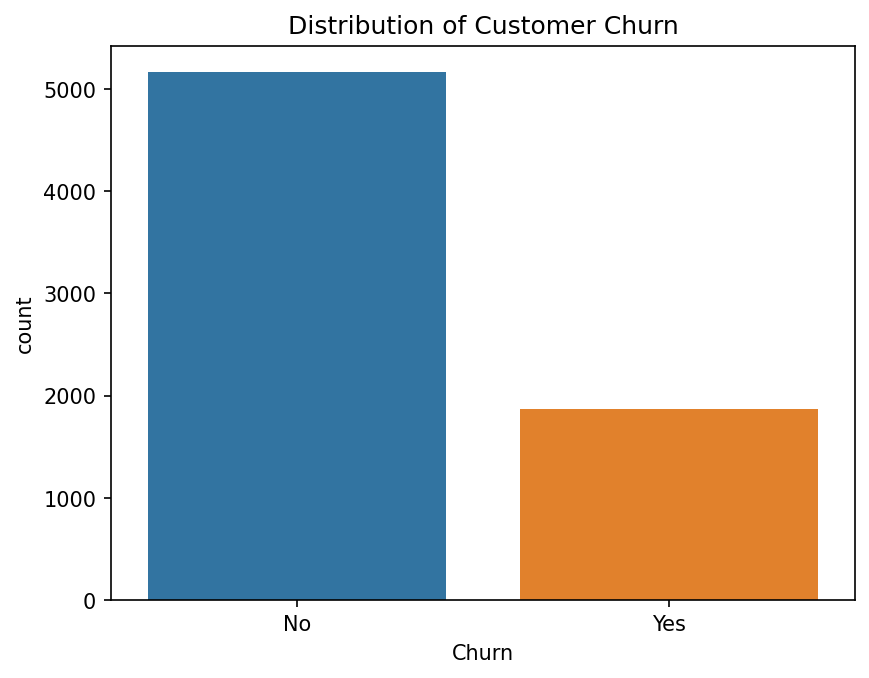

In [24]:
# Set figure parameters
plt.figure(dpi=150)
# Visualise distribution of Churn class labels
sns.countplot(data=df, x="Churn", hue="Churn")
# Set plot title
plt.title("Distribution of Customer Churn");

From the output, an approximately 26.6 percent instance of churn was noted amongst customers, compared to about 73.4 percent of customers that were non-churners. This corresponds to an overall *churn rate* of around *0.27* within the dataset. The count plot indicates a *churn ratio* of about *3:1*, meaning that for every 3 customers retained, 1 customer leaves.

These observations indicate a clear class imbalance in the dataset, confirming the need for implementing class balancing techniques during the modelling phase of this project.

### Exploratory Data Analysis of Numerical Variables

This section covers the exploratory data analysis of the numerical variables within the dataset, namely `tenure`, `MonthlyCharge`, and `TotalCharges`. 

Histograms and boxplots were created to gain further insights into their distributions; a second set, colour encoded by the target variable `Churn`, were also created, for which the boxplot revealed the presence of outliers within the minority churn class. These outliers were investigated to assess their potential impact on model performance. Further visualisations were later generated including a pairplot, heatmap, and 3D scatterplot, after which a Mann-Whitney U test was conducted to determine whether there was a statistically significant difference between churning and non-churning customers.

#### Histograms and Boxplots

To streamline the visualisation process, a function was created that generates side-by-side histograms and boxplots for each numerical variable, helping to ensure consistency in the visualisation output across the different variables.

In [25]:
def create_histogram_boxplots(data, features, 
                              figsize=(6.4, 4.8), hue=None):
    """
    Creates a histogram and a box plot side by side 
    for each numerical feature provided, displaying 
    both on a single row of a subplot for comparative 
    visualisation of the distribution and spread.
    
    Takes a Pandas DataFrame 'data', the numerical 
    features 'features' (list), optional subplot
    figure size configuration 'figsize' (tuple
    containing two int or float values), and 
    optional colour encoding by categorical
    variable 'hue' (string).

    Notes: 
    - pyplot.show() or ; is not called within
    this function.
    - A KDE line is hardcoded into the 
    histogram plot.
    """
    
    # Define subplots grid
    fig, ax = plt.subplots(nrows=len(features), 
                           ncols=2, figsize=figsize)
    # Flatten axis for iteration
    ax = ax.ravel()
    
    # Loop over features
    for n, feat in enumerate(features):
        
        # Define left and right axes
        ax_l = 2 - 2 * (1 - n)
        ax_r = (2 * n) + 1
        
        # Define histogram bin width using Scott's Rule
        binwidth = (3.5 * np.std(data[feat])) / len(data)**(1/3) 
        
        # Plot feat histogram (LHS) and boxplot (RHS)
        sns.histplot(data, ax=ax[ax_l], x=feat, 
                     binwidth=binwidth, hue=hue, kde=True)
        sns.boxplot(data, ax=ax[ax_r], x=feat, hue=hue)
        
        # Set title and xlabel for each side of row
        for plot in [ax_l, ax_r]:
            ax[plot].set_title(feat)
            ax[plot].set_xlabel(None)
            
    # Adjust padding
    fig.tight_layout()

    # Return figure and axes
    return fig, ax

Histograms & box plots were subsequently visualised using the above function. The *num_columns* list, defined earlier on during the process of cleaning the data (*see Checking for Inconsistencies*), was used as input.

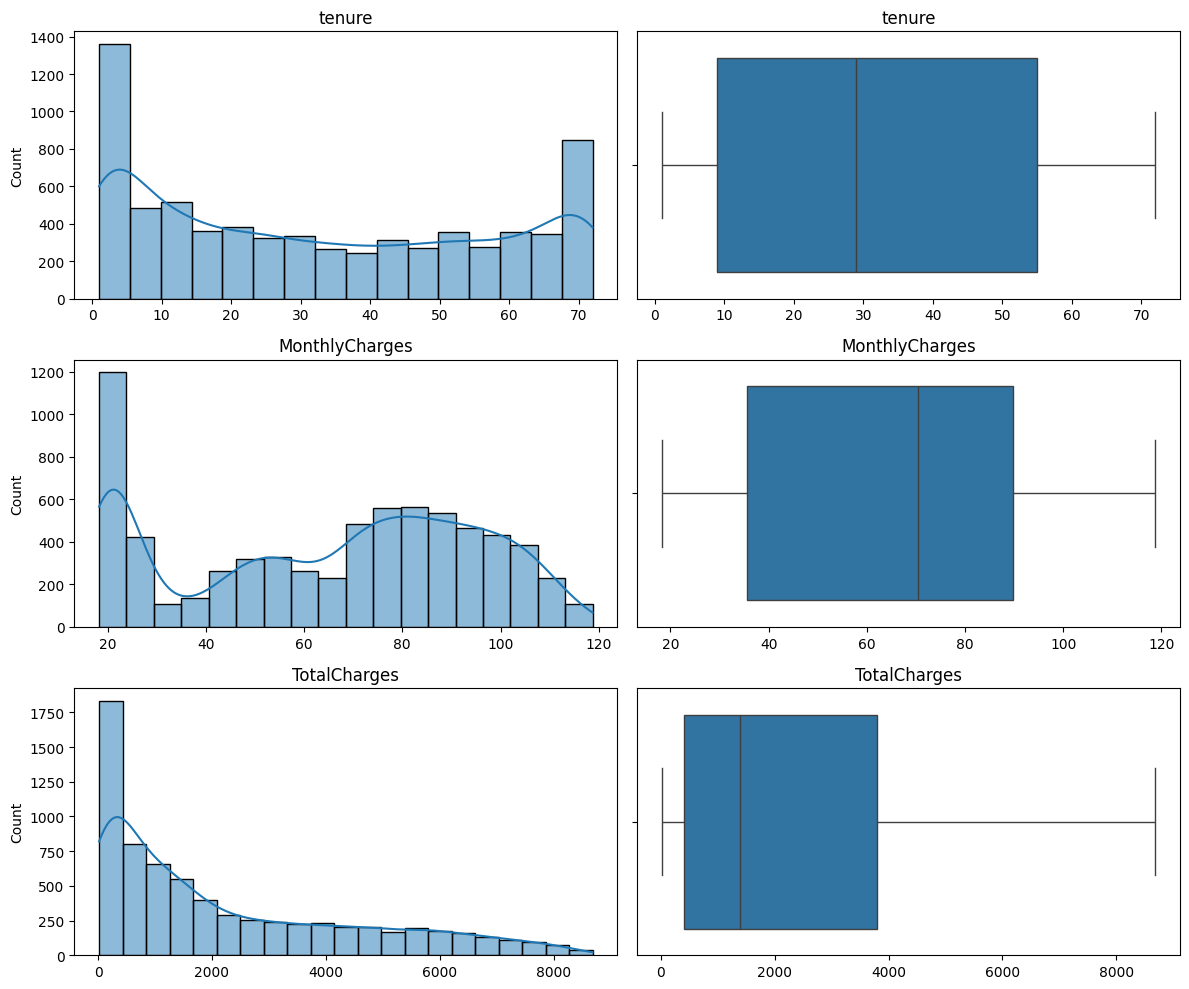

In [26]:
# Create Histogram Boxplots for numerical features
fig, ax = create_histogram_boxplots(df, num_columns, 
                                    figsize=(12, 10));

Looking at the visualisations, three very different distributions were noted.

**tenure**:

The histogram is bimodal, with two clear peaks, showing a roughly symmetric distribution. The two peaks show a large cluster of customers with tenures between roughly 1-5 months, and a slightly smaller cluster between roughly 67-72 months, the latter potentially indicating a concentration of long-term loyal customers. A relatively uniform distribution between the two peaks can be observed.

The box plot suggests an otherwise slightly right-skewed distribution, since the 50 percent of the values below the median have a narrower spread of values compared to above the median. However, the bimodality shown on the histogram challenges this interpretation.

**MonthlyCharges**:

The histogram is multimodal, with a very large noticeable peak between 20-25 USD, another visible peak between 80-85 USD, and another smaller peak between 50-55 USD. Most values are clustered around the middle, between 30-110 USD. The distribution is notably asymmetric, although neither clearly left- nor right-skew. 

The box plot visualisation confirms the asymmetricity seen in the histogram. The lower quartile is much closer to the minimum value than the upper quartile is to the maximum value; converely, the upper quartile is much closer to the median than the lower quartile is to the median.

**TotalCharges**:

The histogram is clearly right-skew. It is also unimodal, with one large clear peak on the extreme LHS between roughly 0-200 USD, suggesting a very large proportion of newer customers. This is supported by the large peak visible in the histogram for `tenure`.

The box plot confirms the strong right-skewness, with the right hand side of the box, between the median and the upper quartile, much wider than the corresponding left hand side of the box. The right whisker is also significantly longer.

#### Histograms and Boxplots: Visualising Churn

A further set of histograms and bloxplots were generated, this time colour encoded by the target variable.

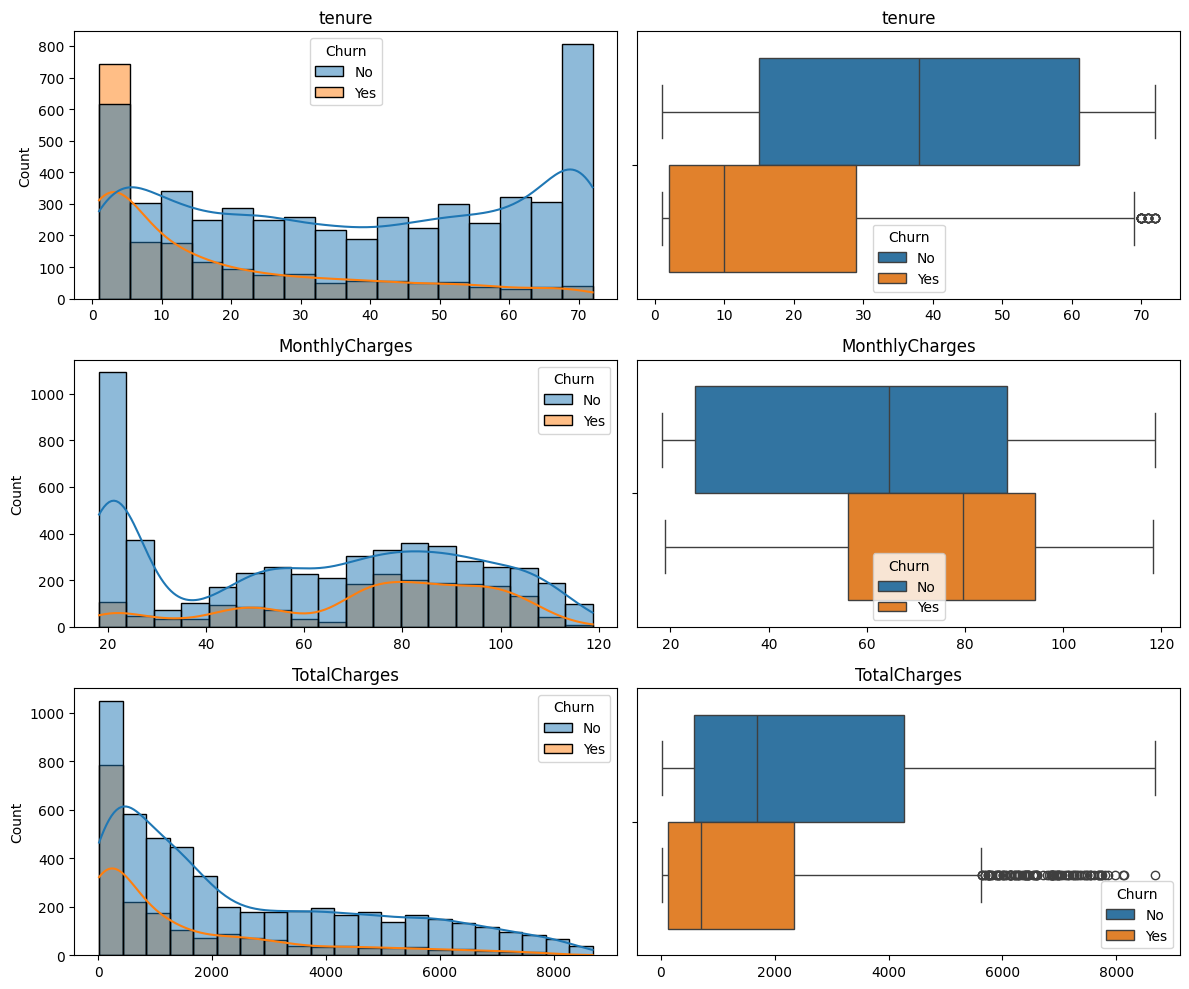

In [27]:
# Create colour encoded Histogram Boxplots
fig, ax = create_histogram_boxplots(df, num_columns, 
                                    figsize=(12, 10), hue="Churn");

Interestingly, while the numerical variables themselves didn't present any outliers overall, several emerged within the churn subset, particularly for `TotalCharges` and `tenure`. The following observations were noted about the visualisations after colour encoding the variables:

**tenure**:

Although the general distribution was found to be a roughly symmetric bimodal distribution, with a left peak dominating, the distribution of churners within this variable is conversely right-skew and unimodal, with a visibly tall left peak between roughly 1-5 months, which sharply declines immediately afterwards, suggesting a very large proportion of customers that churn do so within the first 5 or 6 months of joining the company. The distribution of non-churners on the other hand has remained roughly symmetric, though now with a right peak dominating.

The box plot for churners shows a heavily left-skewed distribution. It has a median of 10, lower quartile somewhere between 2-3, upper quartile around 29, a minimum value of 1 and a maximum value just under 70. Some outliers are also identified on the extreme right hand side, beyond the maximum value (approximately 69 months). The corresponding boxplot for non-churners in comparison looks roughly symmetric, with a median value just under 40, lower quartile of around 15, and upper quartile just over 60.

These findings suggest that the distribution of churners is pulling the overall distribution further to the left, and, on average, churners reported lower than average tenures.

**MonthlyCharges**:

Interestingly, while the distribution among non-churners appears mostly unchanged, the prominent mode to the left has almost all but disappeared in the distribution among churners. Though technically still multimodal, the two peaks to the left, located roughly between 18-24 USD and 40-55 USD, barely tower over the other nearby bins; it could be said that the distribution is relatively uniform below roughly 70 USD. The majority of churners in the distribution are clustered roughly between 70-110 USD, peaking somewhere around 75-80 USD. Hence the distribution loosely resembles a left-skewed distribution.

The box plot for non-churners also appears to be largely unchanged, the only difference being a slightly lower median at around 65 compared to 70.35 overall, and a smaller lower quartile value at around 25 compared to approximately 35.59 overall. In comparison, the box plot for churners has a median value close to 80, a lower quartile around 55, and an upper quartile around 95. The spread between the minimum and maximum values, though slightly narrower, is similar to the corresponding blue box plot.

The insights from these visualisations suggest that a large proportion of churners were *paying more than average in monthly charges*.

**TotalCharges**:

Both shades of the histogram have distributions that are right-skew, although this skew is more prominent in the distribution of churners; this could be because of the larger proportion of churners with shorter tenures and, consequently, less time to accumulate higher total charges.

Looking at blue box plot, it's noted that the lower quartile, median, and upper quartile have shifted slightly further to the left. In comparison, the orange box plot had a median value somewhere around 600-700, and very close to the lower quartile of the corresponding blue box plot. Its lower quartile is at roughly 100, and its upper quartile is just under 2500. The minimums of both box plots look about equal, though the orange box plot has a much smaller maximum, at about 5600 compared to over 8000 for the blue box plot. Consequently, a long trail of outliers are identified beyond the maximum of the orange plot, with a particularly notable single lone outlier to the extreme left.

#### Outlier Investigaton

After analysing the distributions of the data, the outliers found within the second set of box plots were investigated further. A function was created for the purpose of filtering the dataset, based on the IQR method, to identify the specific outliers.

In [28]:
# Investigate Churn outliers seen on box plots.

def find_churn_outliers(feature):
    """
    Returns a DataFrame of outliers for a specified
    feature name (string), focusing only on churned 
    customers, applying the IQR method to identify 
    outliers and outputs the filtered DataFrame 
    for further analysis. 
    
    Note that the DataFrame and the Churn variable 
    are hardcoded within the function for filtering.
    """
    
    # Obtain filtered DataFrame of churned customers
    churners = df[df["Churn"] == "Yes"]

    # Obtain lower and upper quartiles of feature
    upper_q = np.quantile(churners[feature], 0.75)
    lower_q = np.quantile(churners[feature], 0.25)
    # Calculate interquartile range
    IQR = upper_q - lower_q

    # Calculate upper and lower extremes of feature
    upper_ex = upper_q + (1.5 * IQR)
    lower_ex = lower_q - (1.5 * IQR)

    # Filter DataFrame to find outliers
    churn_outliers = churners[(churners[feature] > upper_ex) 
    | (churners[feature] < lower_ex)]

    # Return filtered DataFrame
    return churn_outliers

The churn outliers found for `tenure` under the churn class were first investigated.

In [29]:
# Investigate Churn outliers under tenure
tenure_outliers = find_churn_outliers("tenure")
tenure_outliers

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
809,Male,0,No,No,70,Yes,Yes,Fiber optic,Yes,No,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),104.00,7250.15,Yes
972,Male,0,No,No,71,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,108.05,7532.15,Yes
1302,Female,0,No,No,70,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),115.55,8127.60,Yes
2874,Male,1,Yes,No,70,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,102.95,7101.50,Yes
3035,Male,0,Yes,No,71,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),108.60,7690.90,Yes
3106,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Electronic check,103.40,7372.65,Yes
3433,Male,1,Yes,No,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),104.15,7689.95,Yes
3511,Male,0,Yes,No,70,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),109.50,7534.65,Yes
3883,Female,0,Yes,No,72,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,109.25,8109.80,Yes
4142,Male,0,Yes,No,71,No,No phone service,DSL,No,Yes,No,No,Yes,Yes,Two year,No,Electronic check,49.35,3515.25,Yes


In [30]:
# Obtain number of rows
len(tenure_outliers)

23

There were 23 customers identified by the function as outliers for `tenure` under the churn class; all have tenures between 70-72 months. Since the maximum value shown in the box plot was around 69, and the distribution of tenure among churners within the histogram was consistent and unbroken throughout, these outliers weren't considered to be particularly significant or unusually different from the spread of values identified in the box plot.

The function was then executed for `TotalCharges`.

In [31]:
# Investigate Churn outliers under TotalCharges
TotalCharges_outliers = find_churn_outliers("TotalCharges")
TotalCharges_outliers

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
104,Male,0,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.00,7611.85,Yes
339,Male,0,Yes,No,63,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.40,6603.00,Yes
402,Male,0,Yes,Yes,69,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.45,7007.60,Yes
445,Female,0,No,No,60,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,6396.45,Yes
608,Female,1,Yes,No,65,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),105.25,6786.40,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6774,Male,0,No,No,61,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),111.60,6876.05,Yes
6842,Female,0,No,No,54,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Month-to-month,No,Electronic check,111.10,6014.85,Yes
6934,Male,0,Yes,Yes,70,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Two year,No,Bank transfer (automatic),98.30,6859.50,Yes
6961,Female,1,No,No,56,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,111.95,6418.90,Yes


There were 109 customers identified as outliers for `TotalCharges` under the churn class. 

Further filtering was applied to the dataset in order to identify the extreme value identified in the orange box plot, as well as investigate the differences generally between the top 20 values.

In [32]:
# Obtain top 10 largest TotalCharges
TotalCharges_outliers["TotalCharges"].nlargest(20)

4602    8684.80
1302    8127.60
3883    8109.80
6528    7968.85
5572    7856.00
5119    7804.15
6280    7752.30
6029    7723.90
6389    7723.70
3035    7690.90
3433    7689.95
5688    7674.55
104     7611.85
5693    7548.10
3511    7534.65
972     7532.15
6026    7491.75
2199    7482.10
4387    7446.90
6596    7432.05
Name: TotalCharges, dtype: float64

Excluding the largest value, the differences between each value were relatively small and didn't appear to be particularly significant or unusual. As noted earlier, the box plot revealed a long string of values flagged as outliers, which suggests that these values may not be true outliers in the traditional sense. Instead, they could represent a natural extension of the overall range of the churn subset within `TotalCharges`, especially given the relatively gradual progression between each value. The large number of rows identified as outliers implies that the threshold set by the box plot could be overly sensitive to values that still fall within the expected range of variability for the data.

That said, the most notable outlier observed was the very top value (index 4602), with 8,684 USD in total charges. This value stands out because it's nearly 550 USD higher than the next largest outlier at 8,127 USD, hence its isolation in the box plot seen earlier and, potentially, making it a true anomaly in the data. 

The data were filtered again to isolate the particular row.

In [33]:
# Obtain row of index
TotalCharges_outliers.loc[4602]

gender                                   Male
SeniorCitizen                               0
Partner                                   Yes
Dependents                                 No
tenure                                     72
PhoneService                              Yes
MultipleLines                             Yes
InternetService                   Fiber optic
OnlineSecurity                            Yes
OnlineBackup                              Yes
DeviceProtection                          Yes
TechSupport                               Yes
StreamingTV                               Yes
StreamingMovies                           Yes
Contract                             One year
PaperlessBilling                          Yes
PaymentMethod       Bank transfer (automatic)
MonthlyCharges                          117.8
TotalCharges                           8684.8
Churn                                     Yes
Name: 4602, dtype: object

The particular outlier, in addition to very high total charges, also had a tenure of 72 months, indicating a previous loyal customer. Both the total charges and the tenure for this customer are outliers within their respective variables. Some additional observations made were the high MonthlyCharges value of 117.80 USD, their use of fibre-optic internet service, a contract length of one year, and automatic bank transfer as their payment method.

Despite the presence of these outliers, including the one described above, it was decided to retain them in the dataset. Given the already imbalanced nature of the dataset, particularly with fewer instances of churn, dropping any outliers would further bias the model in favour towards predicting the majority class and reduce the available data for identifying churn. Furthermore, subsequent investigation of the categorical variables in the analysis identified *fibre optic internet service* and *paperless billing* to be strongly associated with churn, both of which were subscribed to by the customer described above. This suggested that multiple factors, beyond just `TotalCharges`, could potentially explain the customer's churn. 

Hence although removing certain outliers was initially considered, particularly the one described above due to the exceptional nature of its value for `TotalCharges`, the presence of other churn-related factors as well as class balancing considerations ultimately influenced the decision to retain it.

Model performance was monitored closely later on, during the modelling phase of the project, to ensure that these outliers did not disproportionately impact performance metrics or lead to overfitting. 

#### Correlation Heatmap

After investigating the outliers found in the box plot, more visualisations were generated to further explore patterns and relationships between the data. A correlation heatmap was created to better understand the strength of relationships between the numerical variables.

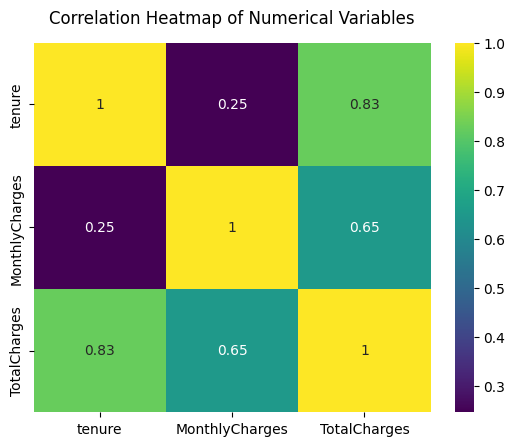

In [34]:
# Define numerical column correlations
num_column_corr = df[num_columns].corr()

# Create heatmap
sns.heatmap(data=num_column_corr, 
            cmap="viridis", annot=True)

# Set title and title position
plt.title("Correlation Heatmap of Numerical Variables", y=1.03);

The correlation heatmap of the numerical variables indicated strong positive correlations of 0.83 between `TotalCharges` and `tenure`, as well as 0.65 between `TotalCharges` and `tenure`. This was expected, as earlier observations revealed that `TotalCharges` approximates the product of `MonthlyCharges` and `tenure`. Additionally, a weaker, though still notable correlation of 0.25 was noted between MonthlyCharges and tenure. 

Careful consideration was given to potential issues with collinearity between these variables during the modelling phase. However, since `TotalCharges` is not exactly equal to the product of the other two variables, it could capture additional information that the other two variables alone cannot. In this respect, `TotalCharges` could function similarly to an *interaction term*.

As such, the `TotalCharges` column was retained in the dataset, while also planning to train models with and without it to evaluate its impact on model performance. This will help determine whether the inclusion of `TotalCharges` improves or diminishes performance.

#### Pair Plot

A pairplot was used to explore how the numerical variables influence each other, across both *churn* and *non-churn* categories, in order to reveal additional trends that may help to support the modelling process.

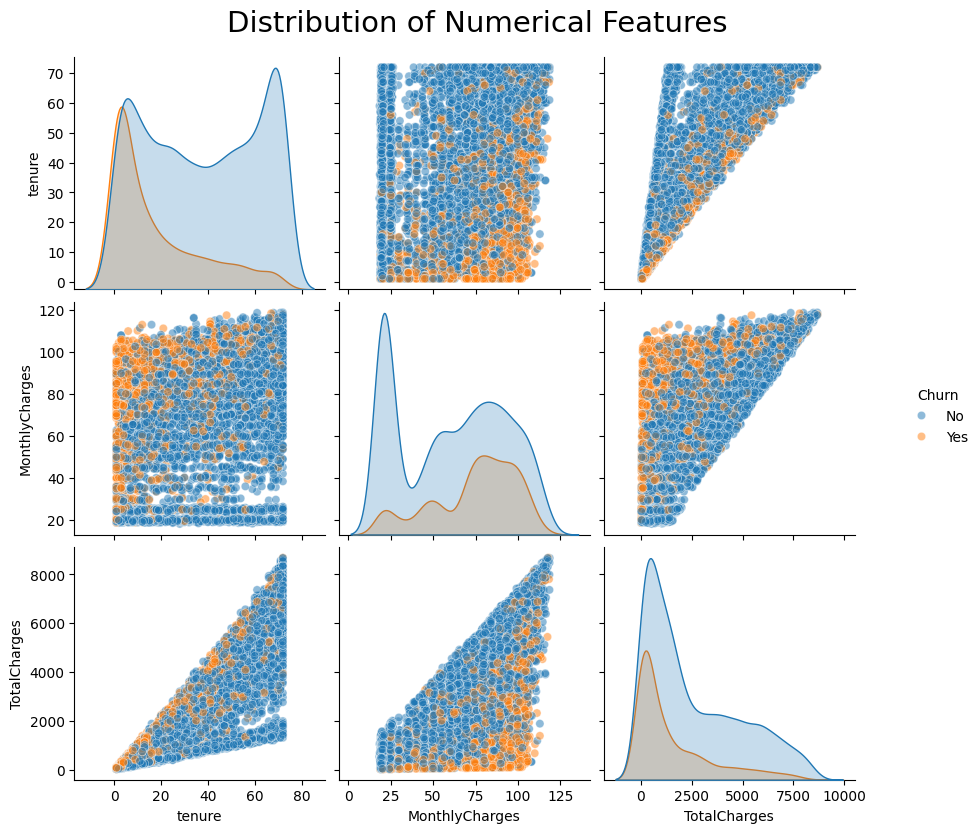

In [35]:
# Create and format pairplot
pplot = sns.pairplot(data=df, vars=num_columns, 
                     hue="Churn", plot_kws=dict(alpha=0.5))

# Set title
pplot.fig.suptitle("Distribution of Numerical Features", 
                   y=1.04, fontsize=21)

# Adjust size
pplot.fig.set_size_inches(10, 8);

From the pair plot, the following observations were made:

##### **KDE Plots**:

The KDE plots provided further clarity on the visualisations of distributions without the distraction of the histogram bins, reinforcing earlier observations of skewness and modality in these variables. For example, the multimodal distribution within the churn subset of `MonthlyCharges` continues to show a tendency towards left-skew, confirming earlier findings.

##### **MonthlyCharges vs TotalCharges Scatterplot**: 

The scatterplot revealed two notable clusters of churn:
- A large cluster associated with total charges (below 4,000 USD) and higher monthly fees (around 60-110 USD).
- A smaller cluster for both low total charges (under 1,000 USD) and low monthly fees (under 50 USD), with fewer churn instances scattered across the plot as total charges increase while monthly charges remains low.

In addition, a trail of churn instances is notable as total charges increase for higher monthly charges. In general, the relationships here are non-linear, as the pattern of churn predominantly appears to follow a sort of curve.

These findings suggest churn tends to occur more frequently among customers who have accumulated lower total charges but pay higher monthly fees.

##### **TotalCharges vs tenure Scatterplot**:

An approximately linear pattern emerged for the churn class, where churn seems to increase with both higher tenure and higher total charges. While a notable upward trend is seen, there are also a few outlying points with high tenure but low total charges, which may represent customers who haven't paid substantial fees despite long tenures.

##### **MonthlyCharges vs tenure Scatterplot**:

The instances of churn here are particularly concentrated in *two* regions:
- Low tenure (under 24 months) and high monthly charges(over 65 USD), which continues to be observed even as tenure increases, in line with a gradual increase in monthly charges.
- A smaller, but notable cluster among low tenure and low monthly charges.

Churn is also observed sporadically across higher tenure values and monthly charges, implying that churn risk is pervasive but more concentrated in certain segments. The pattern is non-linear, as most of the instances of churn loosely resemble a curve.

#### 3D Scatterplot

To further clarify the visual findings observed in the scatterplots and examine how all these variables interact and influence churn together, a 3D scatterplot was generated to visualise all of the 3 numerical variables.

In [36]:
# Import required library
from mpl_toolkits import mplot3d

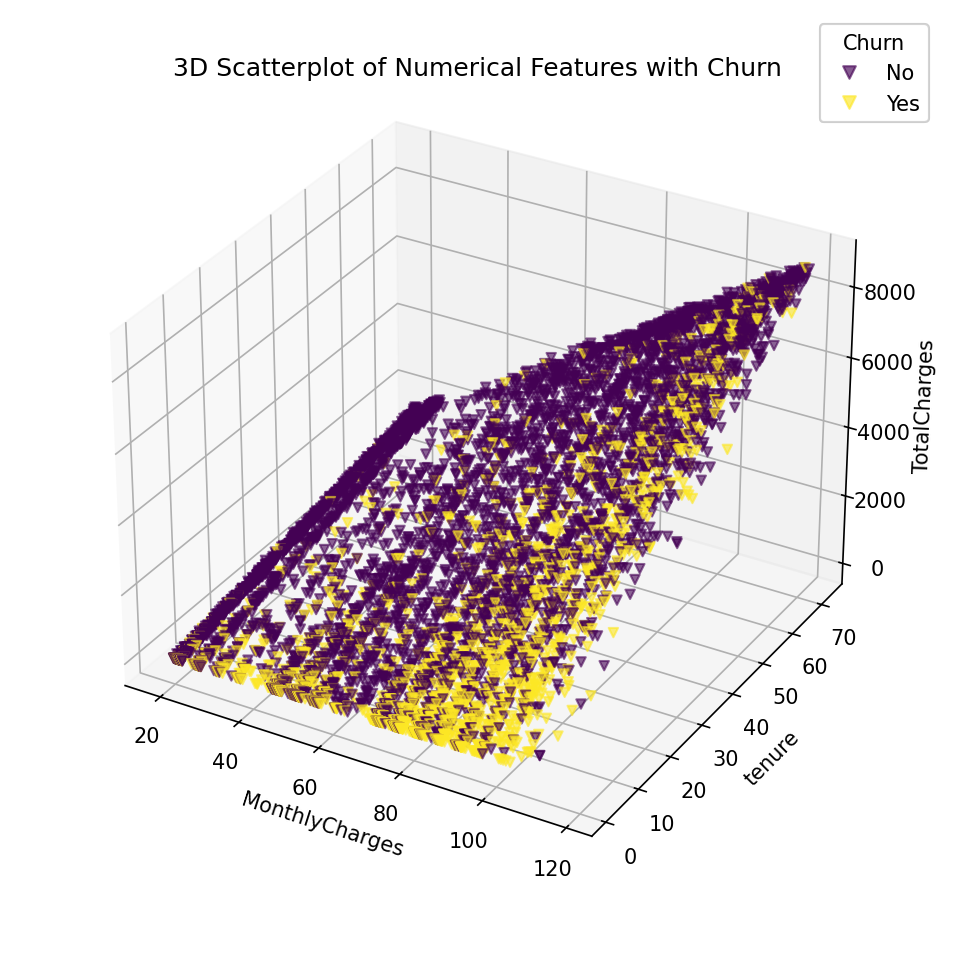

In [37]:
# Set figure parameters
fig = plt.figure(figsize=(8, 8), dpi=150)
ax = fig.add_subplot(projection="3d")

# Define x, y and z of plot
x = df["MonthlyCharges"]
y = df["tenure"]
z = df["TotalCharges"]

# Convert Churn to numerical format for plotting
c = pd.get_dummies(df["Churn"], drop_first=True)

# Plot 3D scatterplot
scatter = ax.scatter(x, y, z, c=c, marker="v", alpha=0.6)

# Set title and axes labels
ax.set_title("3D Scatterplot of Numerical Features with Churn", y=1)
ax.set_xlabel("MonthlyCharges")
ax.set_ylabel("tenure")
ax.set_zlabel("TotalCharges")

# Set legend
legend = ax.legend(*[scatter.legend_elements()[0], 
                     ["No", "Yes"]], loc="upper right", title="Churn")
ax.add_artist(legend)

# Zoom out to ensure axis labels are visible
ax.set_box_aspect(None, zoom=0.9);

The 3D scatterplot confirms previous observations made earlier between pairs of each numerical variable.

The plot reveals that, although instances of churn seem to occur sporadically all over, there seems to be a very high concentration of churn for customers with high monthly charges (above 60 USD), low tenure (below 40 months), and lower total charges (under 4,000 USD). Additionally, there are notable concentrations of churners seen in other parts of the plot. Churners are seen among customers with lower monthly charges (below 60), lower tenures (below 20 months), and lower total charges (under 2000 USD). On the other hand, churn rates decrease for customers with higher tenures and higher total charges, together with moderate to low monthly charges.

A notable triangular- or boomerang-shaped cluster is visible in the plot, with churners densely concentrated in the centre. This triangular region tapers off at the lower and higher ends of all 3 variables, suggesting that churn becomes less likely among long-term loyal customers even with higher total charges and monthly expenses, while remaining more likely for customers with short tenures and either high monthly expenses or lower total charges.

By visualising these variables together, the 3D plot highlights the links between `tenure`, `MonthlyCharges` and `TotalCharges`, reinforcing earlier observations that churn appears most prevalent amongst customers with lower tenures and higher monthly fees.

#### Mann-Whitney U-Test

To assess whether there were any statistically significant differences between churn and non-churn customers with respect to the numerical features in the dataset, a Mann-Whitney U-Test was conducted. This non-parametric test was selected in order to account for the irregular distributions of the variables; rather than applying transformations to normalise the data, the Mann-Whitney U-Test was deemed appropriate to test for differences without assuming normality.

To streamline the process of testing the data, a function was created for the purpose of conducting the Mann-Whitney U-Test.

In [38]:
def perform_mann_whitney_test(data, column, target):
    """
    Performs the Mann-Whitney U test between 
    two groups defined by a two-feature 
    categorical target variable.

    Takes a Pandas DataFrame 'data', the name
    of the numerical column 'column' (string),
    and the name of the target column 'target' 
    (string).

    Returns a tuple with test statistic and 
    p-value, along with string messages 
    indicating whether or not the null 
    hypothesis was rejected (5% and 1% 
    significance levels, respectively).
    """
    # Define target class labels
    target1 = data[target].unique()[0]
    target2 = data[target].unique()[1]

    # Define groups split by target class
    group1 = data[column][data[target] == target1].tolist()
    group2 = data[column][data[target] == target2].tolist()

    # Perform test
    statistic, pvalue = mannwhitneyu(group1, group2)

    # Print rejection result
    if pvalue < 0.05:
        five_sig = "Reject null hypothesis at 5%"
    else:
        five_sig = "Do not reject null hypothesis at 5%"
    
    if pvalue < 0.01:
        one_sig = "Reject null hypothesis at 1%"
    else:
        one_sig = "Do not reject null hypothesis at 1%"

    # Return results
    return statistic, pvalue, five_sig, one_sig

The *null hypothesis* $H_0 $ for each test was that there was no difference between the distribution of the variable between churners and non-churners. The *alternative hypothesis* $H_1$ was that the distribution differed significantly between the two groups. Let $l$ denote the underlying difference in location between the populations from which the two samples were drawn. Then

$$H_0: l = 0,$$
$$H_1: l \neq 0.$$

The tests were performed below.

In [39]:
# Initialise results dictionary
mw_test_results = {}

# Loop over numerical variables
for variable in num_columns:
    # Perform test and add to dictionary
    stat, p, f_sig, o_sig = perform_mann_whitney_test(df, variable, "Churn")
    mw_test_results[variable] = (stat, p, f_sig, o_sig)

# Show results
mw_test_results

{'tenure': (np.float64(7154668.0),
  np.float64(6.043046580882717e-211),
  'Reject null hypothesis at 5%',
  'Reject null hypothesis at 1%'),
 'MonthlyCharges': (np.float64(3663498.5),
  np.float64(8.467195044548749e-54),
  'Reject null hypothesis at 5%',
  'Reject null hypothesis at 1%'),
 'TotalCharges': (np.float64(6288982.0),
  np.float64(1.9959848938845826e-84),
  'Reject null hypothesis at 5%',
  'Reject null hypothesis at 1%')}

The results of the Mann-Whitney U-Tests showed that for all numerical variables, `tenure`, `MonthlyCharges`, and `TotalCharges` , $H_0$ was rejected at both the 5 percent and 1 percent significance levels. That is, $p < 0.01$ for all variables. The Mann-Whitney test statistic $U$, along with the corresponding $p$-values given for each variable, were (to 3 significant figures):

- **tenure**:
  - $U = 7.15 \times 10^6$
  - $p = 6.04 \times 10^{-211}$ 
- **MonthlyCharges**:
  - $U = 3.66 \times 10^6$
  - $p = 8.47 \times 10^{-54}$
- **TotalCharges**:
  - $U = 6.29 \times 10^6$
  - $p = 1.10 \times 10^{-84}$

This indicated that the distributions of each variable differed significantly between customers who churned and those who did not.

These results suggest that there are significant differences in tenure, monthly charges, and total charges between churners and non-churners. The Mann-Whitney U-Test confirms that these differences are statistically significant, reinforcing the relationships observed during the exploratory data analysis of these variables.

To conclude, the Mann-Whitney U-Test provided strong evidence that all three numerical variables were significantly associated with customer churn. These differences further validate the trends identified by the visualisations earlier, particularly that customers with shorter tenures, higher monthly charges and lower total charges were most likely to churn overall.

### Exploratory Data Analysis of Categorical Variables

This section covers the exploratory data analysis of the categorical variables within the dataset. The categorical variables were organised based on their context into relevant groups to support a structured analysis; these groups include:

- **Demographics** (*gender*, *SeniorCitizen*, *Partner*, *Dependents*)
- **Security & Support** (*DeviceProtection*, *OnlineSecurity*, *OnlineBackup*, *TechSupport*)
- **Billing & Payment** (*Contract*, *PaperlessBilling*, *PaymentMethod*)
- **Service Type** (*PhoneService*, *InternetService*, *MultipleLines*)
- **Streaming** (*StreamingMovies*, *StreamingTV*)

Countplots were created, using a helper function designed for this purpose, in order to visually represent the distribution of each category and identify potential areas of concern related to customer churn. Value counts for all features were obtained to provide a clear overview of the distribution of each category, and percentage equivalents of these counts were calculated for additional context to the numerical counts, which helped in understanding the proportion of each category relative to total sample size. Key categories were identified, where high instances of churn were noted, and churn percentages for these categories were calculated. Finally, a chi-squared test for independence was performed to further validate the visual findings from the analysis.

To start, a function was created to assist with plotting the categorical data.

In [40]:
def create_countplots(data, features, hue, 
                      figsize=(6.4, 4.8), dpi=300):
    '''
    Creates two count plots side by side for each
    categorical feature provided, displaying both on 
    a single row of a subplot. The first plot displays 
    the distribution of the feature categories, while 
    the second plot shows the same distribution, 
    further split by the target variable (e.g. Churn), 
    allowing for a direct comparison of the feature 
    distribution with respect to the target variable.

    Takes a pandas DataFrame 'data', categorical 
    variables/features 'features' (string), parameter
    for colour encoding by categorical variable 'hue'
    (string), optional subplot figure size configuration 
    'figsize' (tuple containing two int or float values), 
    and optional dots per inch for increasing image
    detail 'dpi'.

    Notes: 
    - pyplot.show() or ; is not called within
    this function.
    - The ncols parameter within plt.subplots()
    contains the value 2, which is hardcoded 
    into the function.
    '''
    
    # Define subplots grid
    fig, ax = plt.subplots(nrows=len(features), ncols=2, 
                             figsize=figsize, dpi=dpi)
    
    # Flatten axis for iteration
    ax = ax.ravel()
    
    # Loop over features
    for n, feat in enumerate(features):
        
        # Define left and right axes
        ax_l = 2 - 2 * (1 - n)
        ax_r = (2 * n) + 1 
        
        # Plot countplots with feature distribution (LHS) and split by hue (RHS)
        sns.countplot(data, ax=ax[ax_l], x=feat)
        sns.countplot(data, ax=ax[ax_r], x=feat, hue=hue)
        
        # Set title and xlabel for each side of feature
        for plot in [ax_l, ax_r]:
            ax[plot].set_title(feat)
            ax[plot].set_xlabel(None)

    # Adjust padding
    fig.tight_layout()

    # Return figure and axes
    return fig, ax

Prior to running the function and generating the count plots, the categorical variables were organised into the groups outlined at the beginning of this section. This was achieved by slicing the *cat_columns* list created earlier during the initial data cleaning phase (see *Checking for Inconsistencies*).

In [41]:
# Organise categorical variables based on context
cat_demographics = cat_columns[0:4]
cat_security_support = cat_columns[7:11]
cat_billing_payment = cat_columns[13:16]
cat_service_type = cat_columns[4:7]
cat_streaming = cat_columns[11:13]

#### Categorical Variables: Demographics

Count plots were first generated for the demographics variables to provide an understanding of customer characteristics and their distribution.

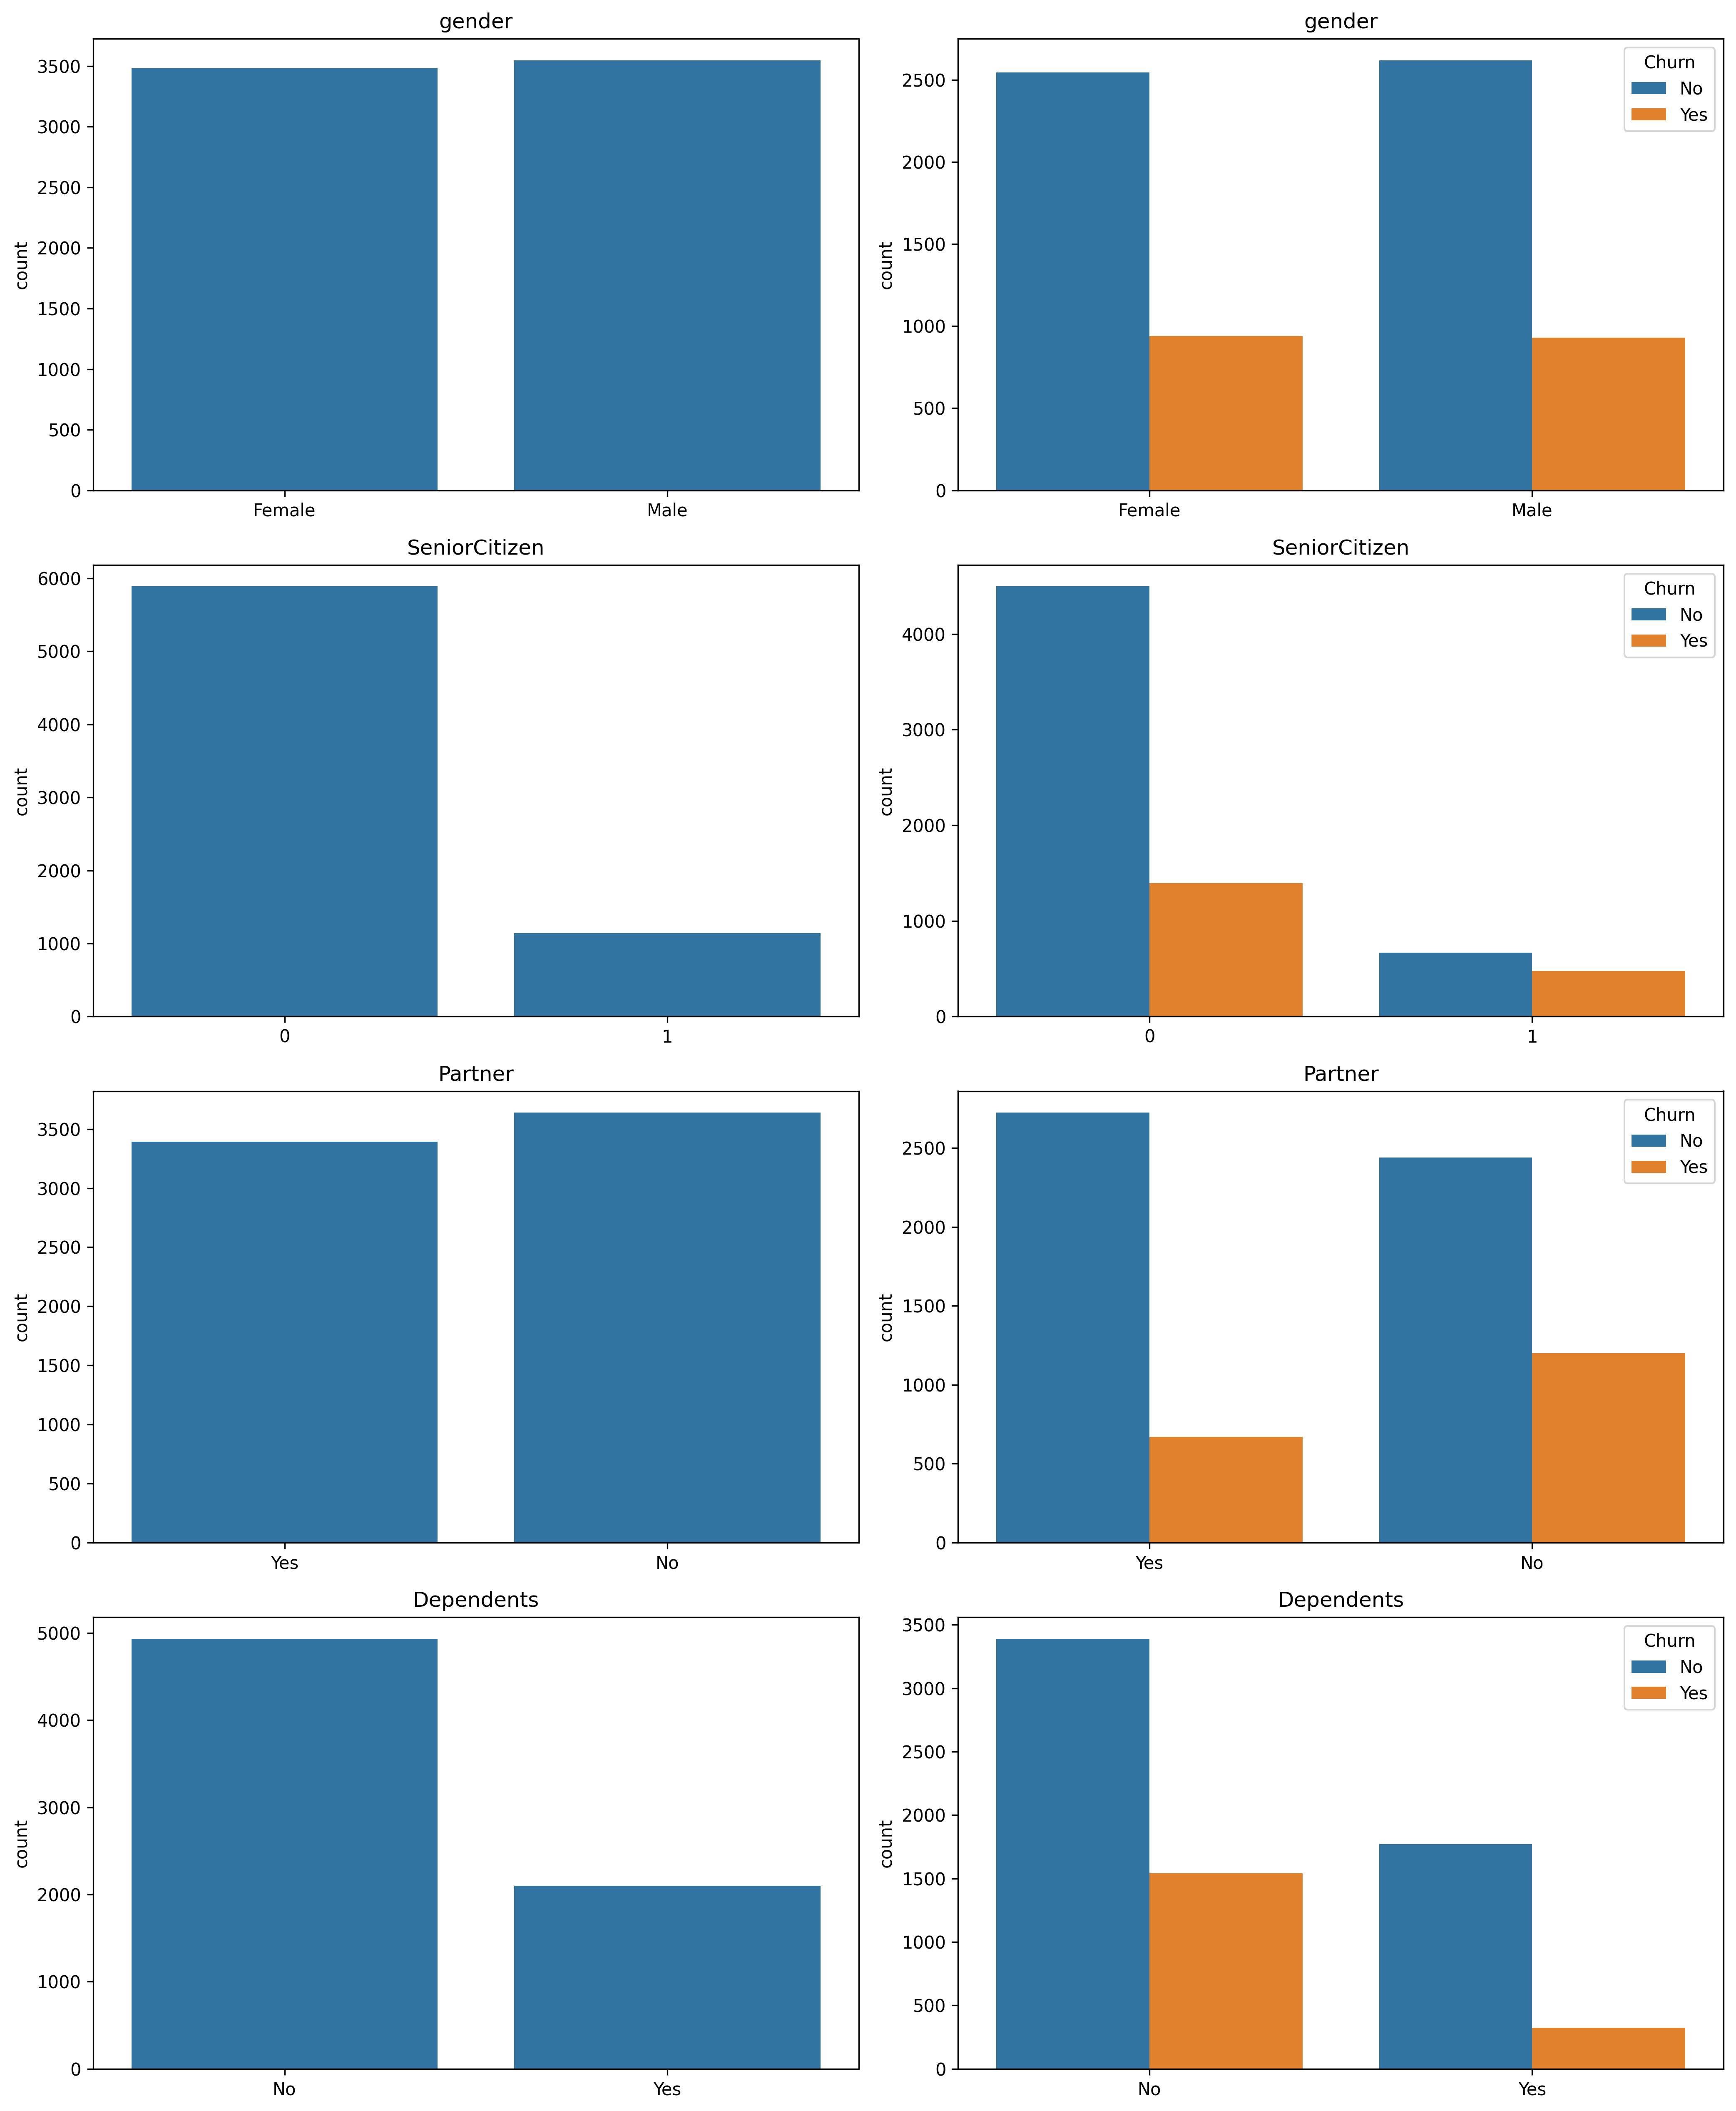

In [42]:
# Countplots for demographic variables
fig, ax = create_countplots(df, cat_demographics, 
                            "Churn", figsize=(14, 17));

From these visualisations, the following observations were made:

**gender**: 

The data show an almost equal split between male and female customers, meaning the gender distribution is roughly *uniform*. The churn rates for both genders also appear to be similar, with no significant differences between the two genders. This suggests that gender does not play a notable role in customer churn.

**SeniorCitizen**:

As highlighted earlier in the summary statistics, only around 15 to 20 percent of customers in the dataset are senior citizens, and this is clearly visible in the count plot - the majority of customers are non-seniors. Although there are more non-senior customers who churn overall, the proportion of senior citizens who churn is *noticeably higher* relative to their number. This suggests that senior citizens are more likely to churn compared to non-senior customers.

**Partner**: 

The distribution of customers with and without customers is relatively even, though there are slightly more customers without partners. The counts hover around 3,500 for both groups. The churn rate is higher for customers without partners compared to those with partners, suggesting that customers without a partner are more likely to churn, possibly due to more flexibility or fewer household-level commitments.

**Dependents**: 

A clear difference in distribution is visible between customers with and without dependents. Approximately two-thirds of the customers do not have dependents, while about one-third do. The rate of churn is higher among customers without dependents; this mirrors the pattern seen with `Partner`, where it was suggested that customers without partners were more likely to churn, further indicating that individuals with fewer household responsibilities may be more prone to churning.

#### Categorical Variables: Security and Support

Next, the security and support variables were visualised to examine whether a potential relationship with customer churn exists.

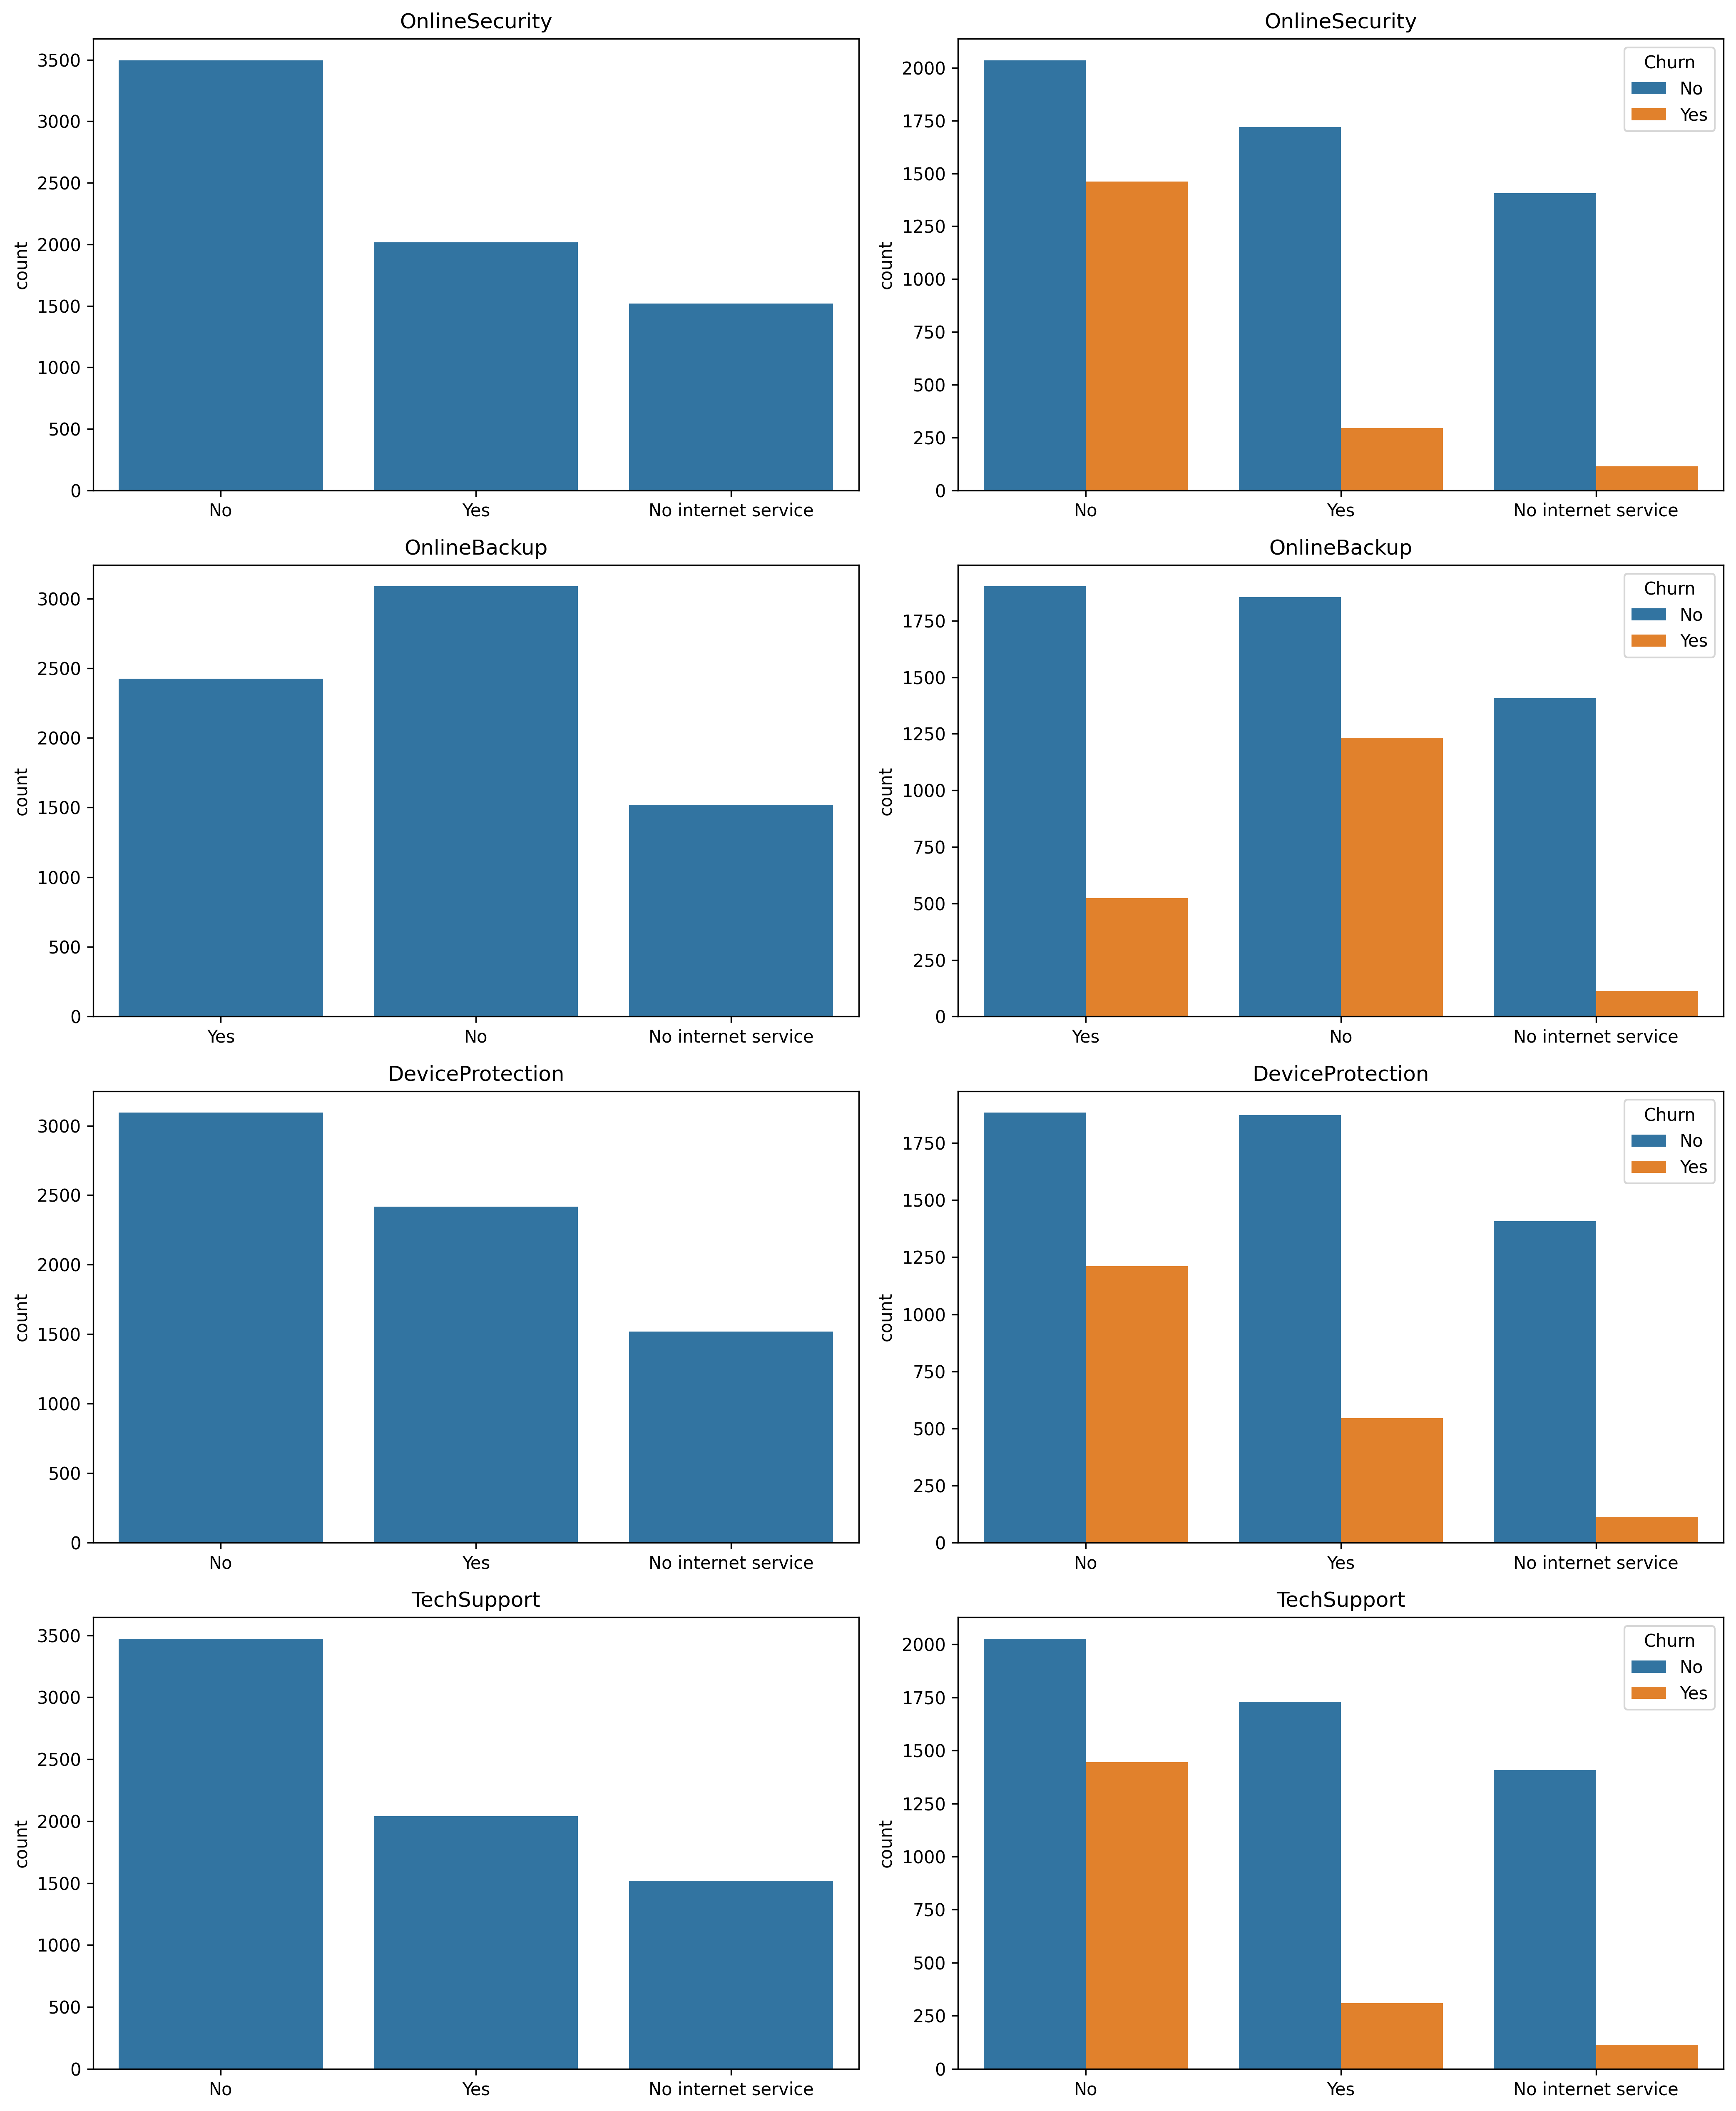

In [43]:
# Countplots for security and support variables
fig, ax = create_countplots(df, cat_security_support, 
                            "Churn", figsize=(14, 17));

The following observations were noted:

**OnlineSecurity**: 

About 50 percent of customers do not have online security, while close to a third have opted for online security services, and the remainder having no internet service. For customers with online security, there is approximately a 5:1 ratio of no churn to churn. For those without online security, the ratio is roughly 4:3, suggesting a much higher churn rate among customers who do not have online security. This indicates that customers without online security are more likely to churn, and appears to be a strong predictor of churn.

**OnlineBackup**:

Similarly to online security, just under half of the customers do not have online backup, while about a third have the service, and the remainder not having internet service at all. The no churn to churn ratio for customers *with* online backup is approximately 5:1, whereas for those without the service, it looks to be around 3:2. This points to a significantly higher churn rate for customers who do not have online backup, resembling the pattern seen with `OnlineSecurity`.

**DeviceProtection**: 

Around 50 percent of customers do not have device protection, and about a third have it, with the remainder having no internet service. Customers with device protection have a no churn to churn ratio of about 4:1, whereas those without device protection have a ratio of around 3:2. Like `OnlineSecurity` and `OnlineBackup`, a higher churn rate is evident among customers who do not have device protection, making this another strong predictor of churn.

**TechSupport**: 

Approximately half of the customers do not have tech support, while about one-third do, and the remainder having no internet service. The churn ratio for customers with tech support looks to be around 7:1, whereas for those without, it is around 4:3. This suggests that customers without tech support are far more likely to churn, further reinforcing the idea that access to security and support services is critical for preventing churn.

A notable portion of customers in each of the above four variables have no internet service. Among this group, the churn rate is low and appears to have a ratio somewhere around 14:1; out of the approximately 1,500 customers without internet service, only about 100 have churned, making churn rates among these customers relatively insignificant.

#### Categorical Variables: Billing and Payment

The subsequent visualisations focused on billing and payment variables, including contract type, to analyse their relationship with churn.

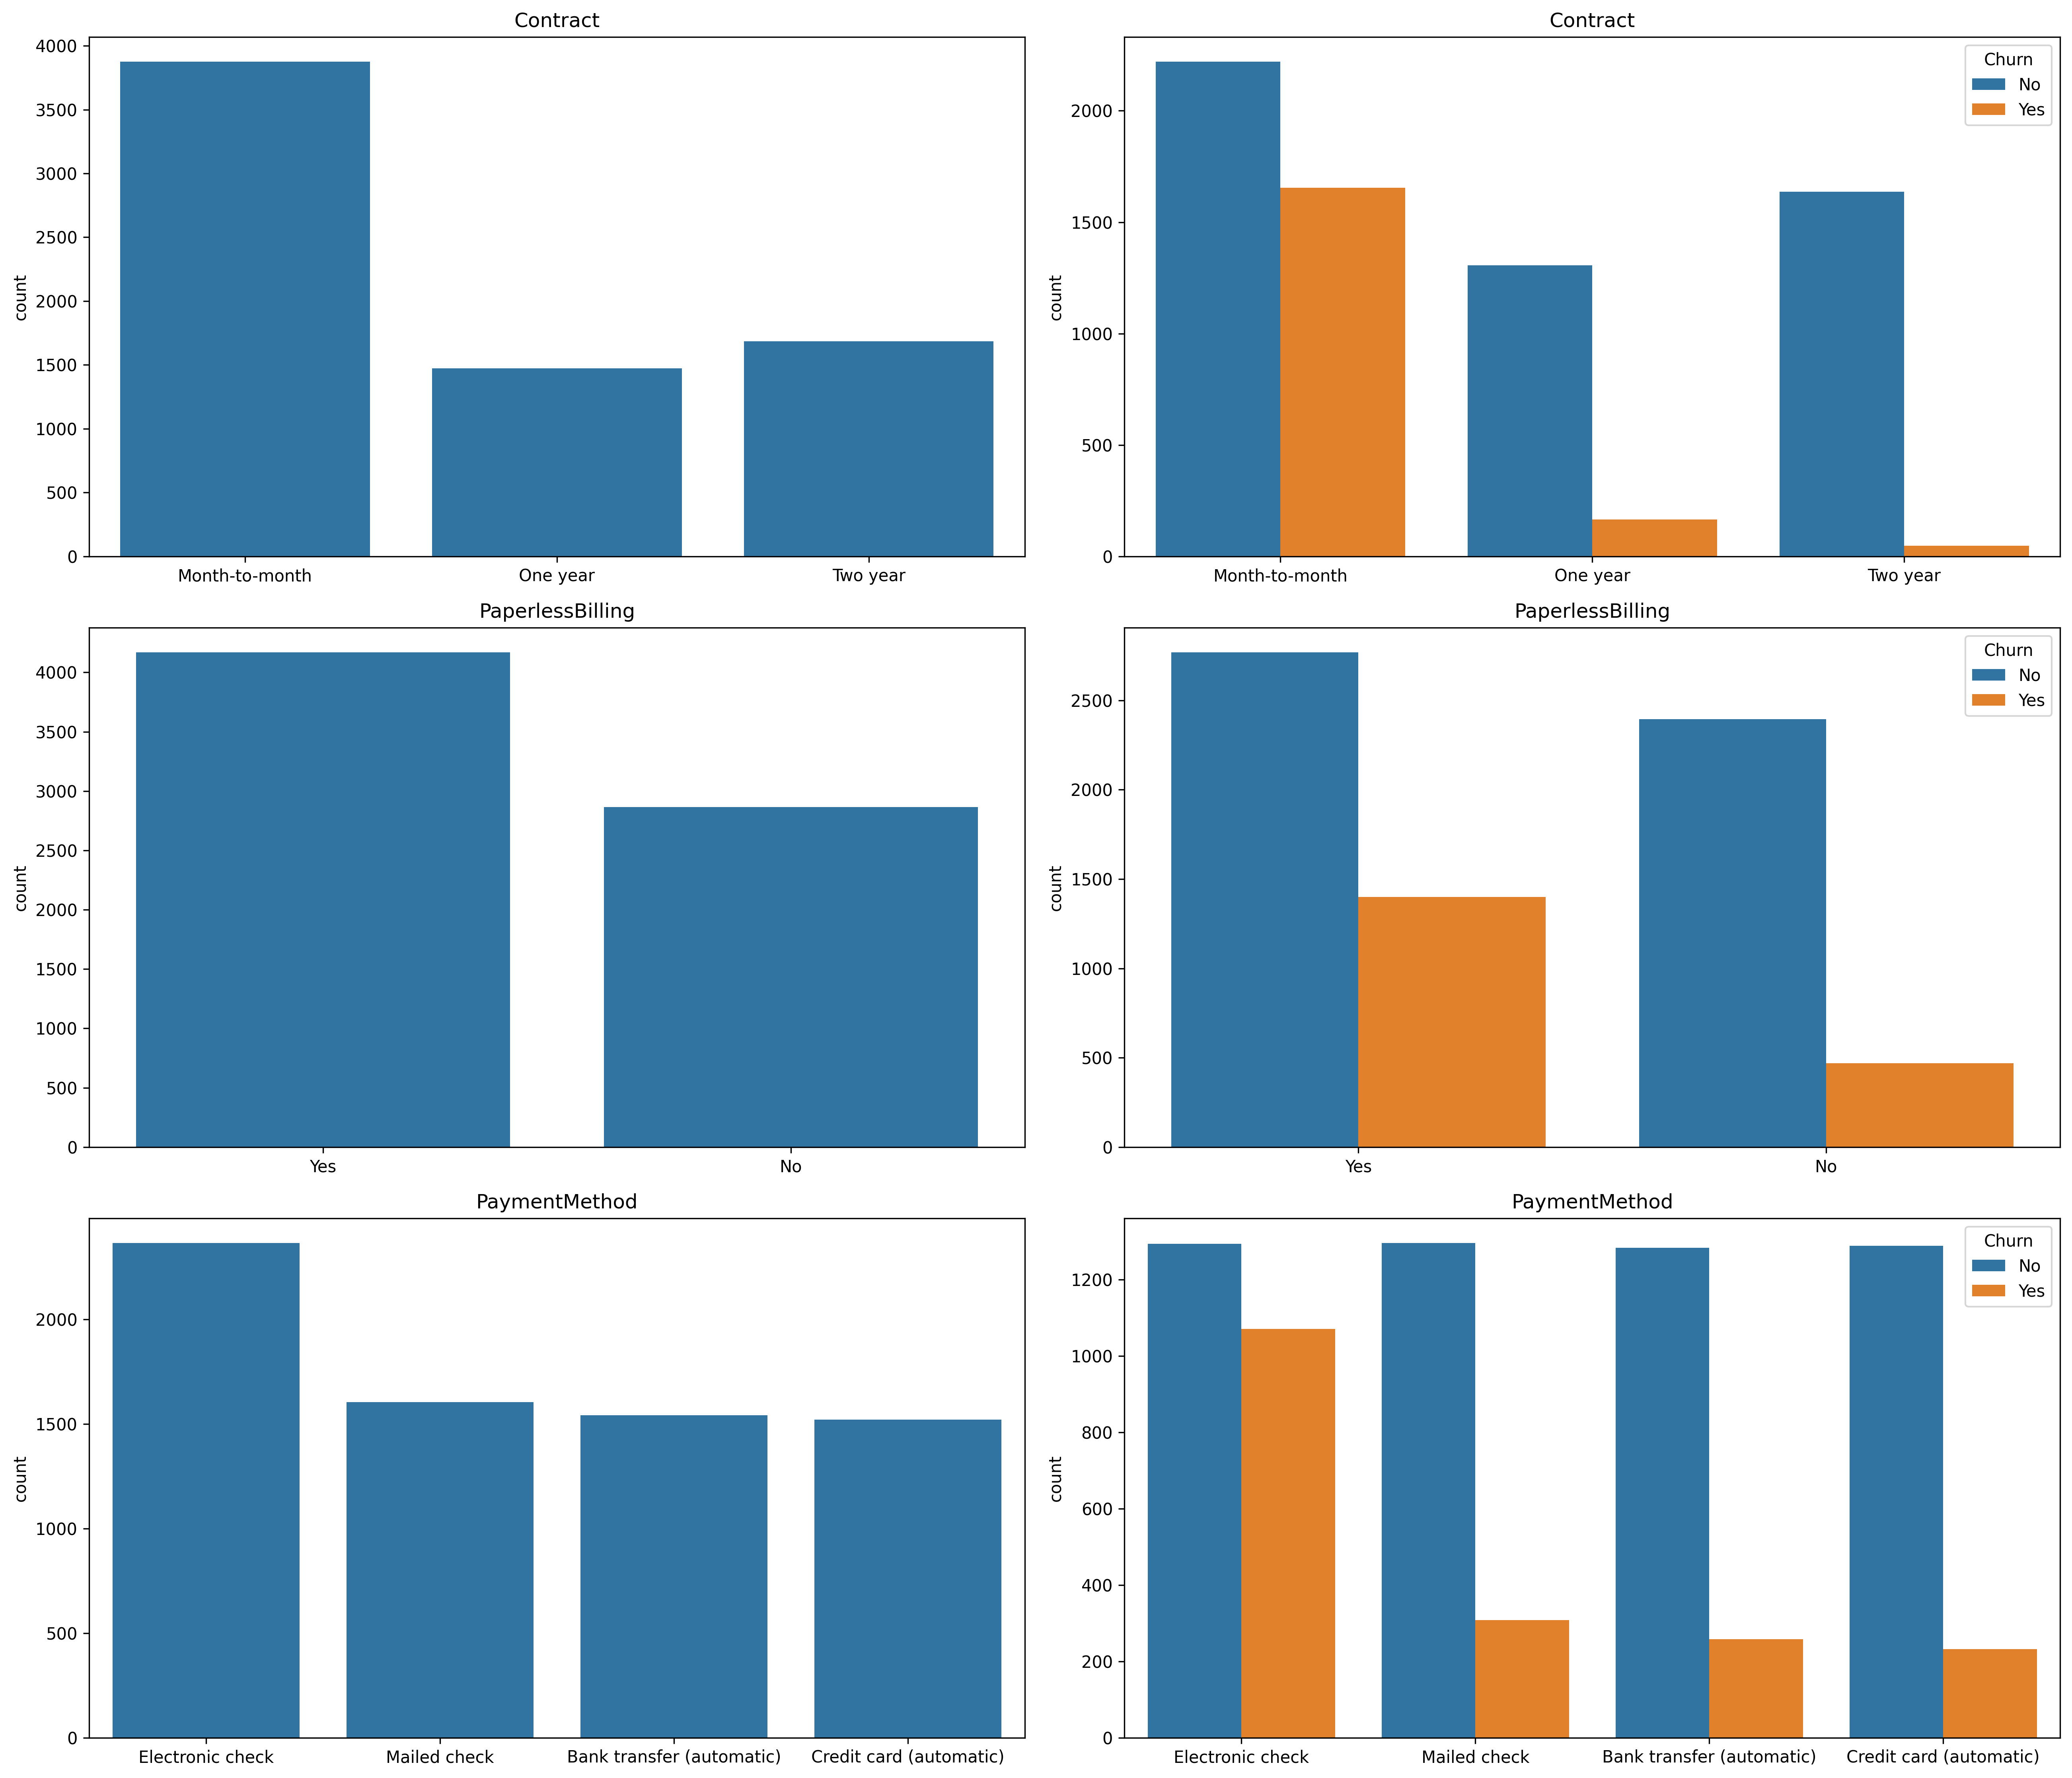

In [44]:
# Countplots for billing and payment variables
fig, ax = create_countplots(df, cat_billing_payment, 
                            "Churn", figsize=(17.5, 15));

The following insights were noted:

**Contract**: 

Approximately 50 to 60 percent of customers have month-to-month contracts, with the remaining 40 percent split roughly equally between one-year and two-year contracts, with a slightly larger proportion of two-year contract holders. Customers with two-year contracts show an almost negligible churn rate. For one-year contracts, the no churn to churn ratio is approximately 8:1, which is still relatively low. In contrast, for month-to-month contracts, the ratio is about 4:3, implying a much higher churn rate. This suggests that customers with month-to-month contracts are more likely to churn, while longer-term contracts may act as a deterrent to churning, likely due to cancellation fees that increase with early terminations.

**PaperlessBilling**: 

Roughly two-thirds of customers have opted for paperless billing, while around one-third have not. The churn rate is higher among customers with paperless billing, with a no churn to churn ratio of approximately 2:1. In comparison, customers without paperless billing have a much lower churn rate, with a ratio of around 5:1, suggesting that paperless billing may be associated with higher instances of churn.

**PaymentMethod**: 

Around 30 to 35 percent of customers pay by electronic cheque, while 20 to 25 percent pay by mailed cheque. The remaining customers are split roughly equally between automatic bank transfer and automatic credit card payments, each accounting for around 20 percent of customers. Churn rates appear relatively similar for automatic bank transfer and credit card payments, with a no churn to churn ratio of approximately 5:1. Mailed cheque payments have a similar, though slightly higher churn rate, with a ratio of around 9:2. However, the highest churn rate seems to be from customers using electronic cheque, with a ratio of around 13:11, suggesting that payment by electronic cheque is a strong predictor of churn.

#### Categorical Variables: Service Type

The service type variables were then plotted to explore whether particular services report higher instances of churn.

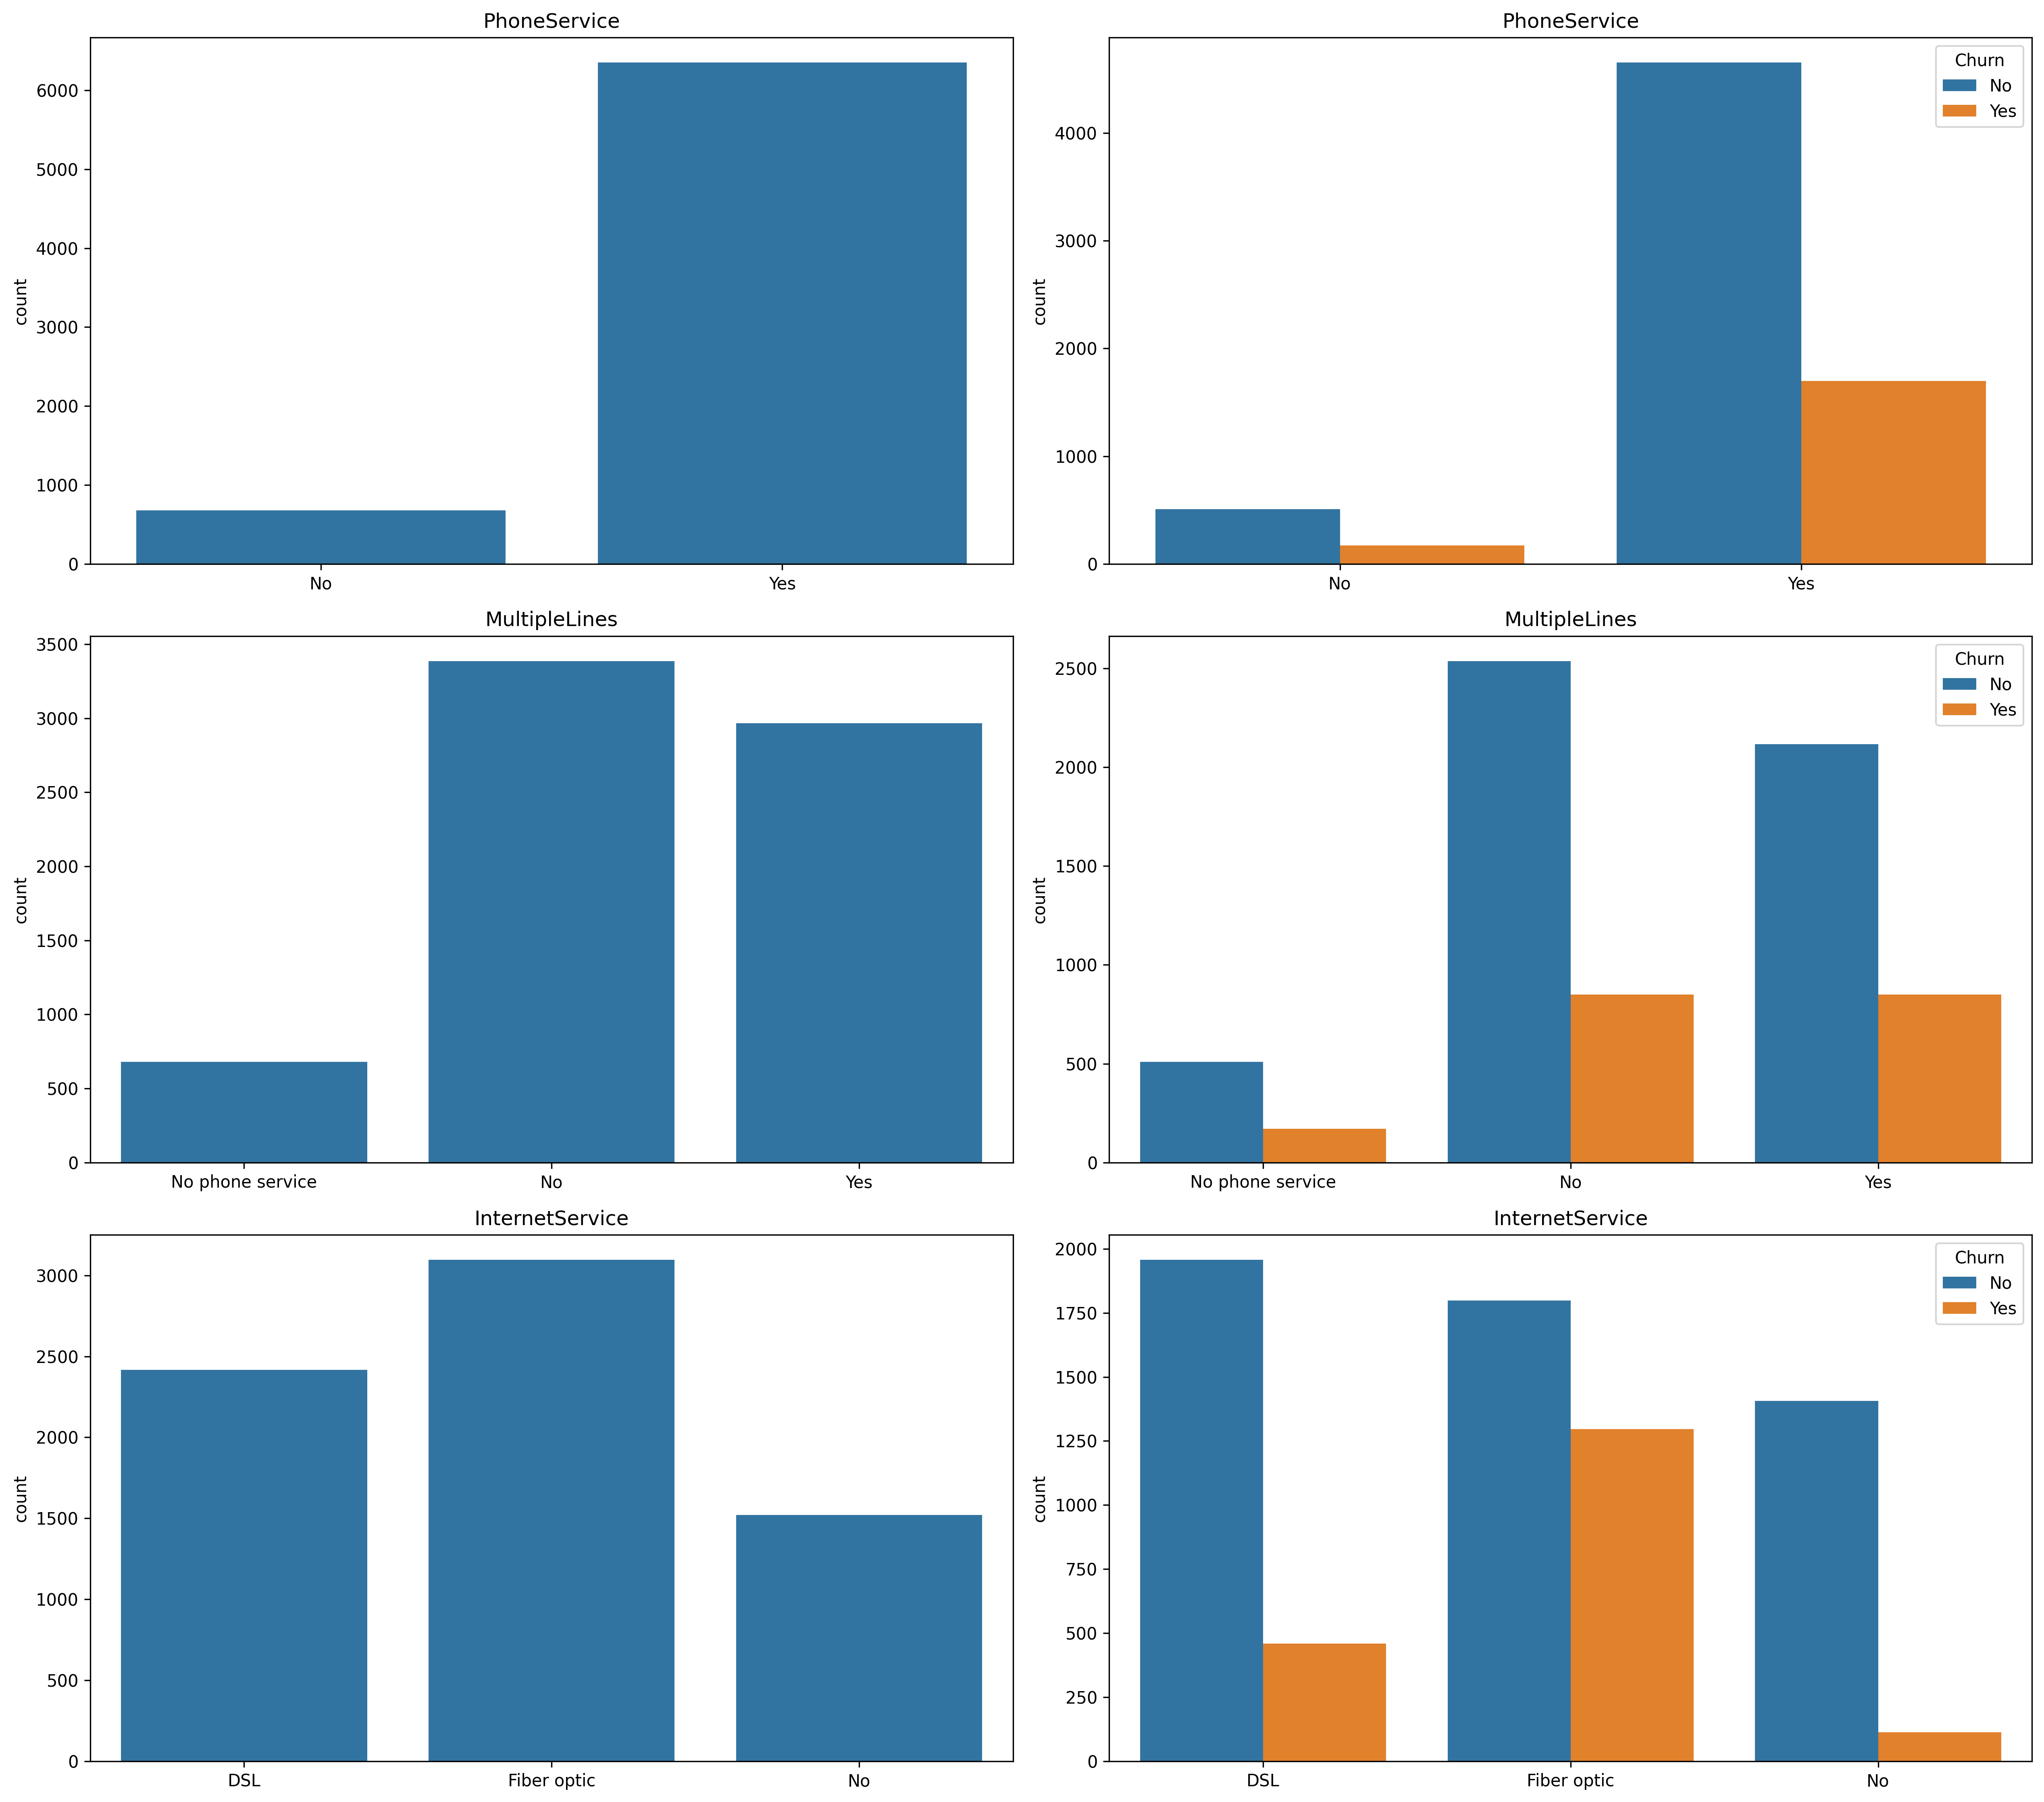

In [45]:
# Countplots for service type variables
fig, ax = create_countplots(df, cat_service_type, 
                            "Churn", figsize=(17, 15));

The following observations were noted:

**PhoneService**: 

A significantly higher number of customers have phone service (about 90 percent) than do not (about 10 percent), though the churn ratio is roughly proportional between both groups, with a no churn to churn ratio of about 3:1. This suggests that phone service alone is not a strong predictor of churn.

**MultipleLines**: 

Roughly 10 percent of customers do not have phone service lines, as noted earlier. The churn rates differ slightly between customers with and without multiple lines. There are a similar number of customers with multiple lines compared to without, though a slightly higher number without (about 50 percent without compared to 40 percent with, respectively). The no-churn-to-churn ratio in customers without multiple lines is about 3:1; for customers with multiple lines, the ratio is about 5:2. Hence there appears to be a slightly higher likelihood of churn among customers with multiple lines compared to those without, though the difference is not huge.

**InternetService**: 

As previously observed in the summary statistics, the most popular internet service is fibre optic, with just under 50 percent of customers using it. Around one-third of customers use DSL, and approximately 20 percent of customers have no internet service, a pattern echoed across the security and support as well as streaming service variables. The no churn to churn ratio for customers using DSL as their internet service is about 4:1; in contrast, for fibre optic the ratio is about 7:5, indicating that using fibre optic internet is associated with a high rate of churn. This could potentially be due to issues with the service, leading to customer frustration.

#### Categorical Variables: Streaming Services

Finally, streaming services were looked at in order to assess whether these variables might contribute to churn in some way.

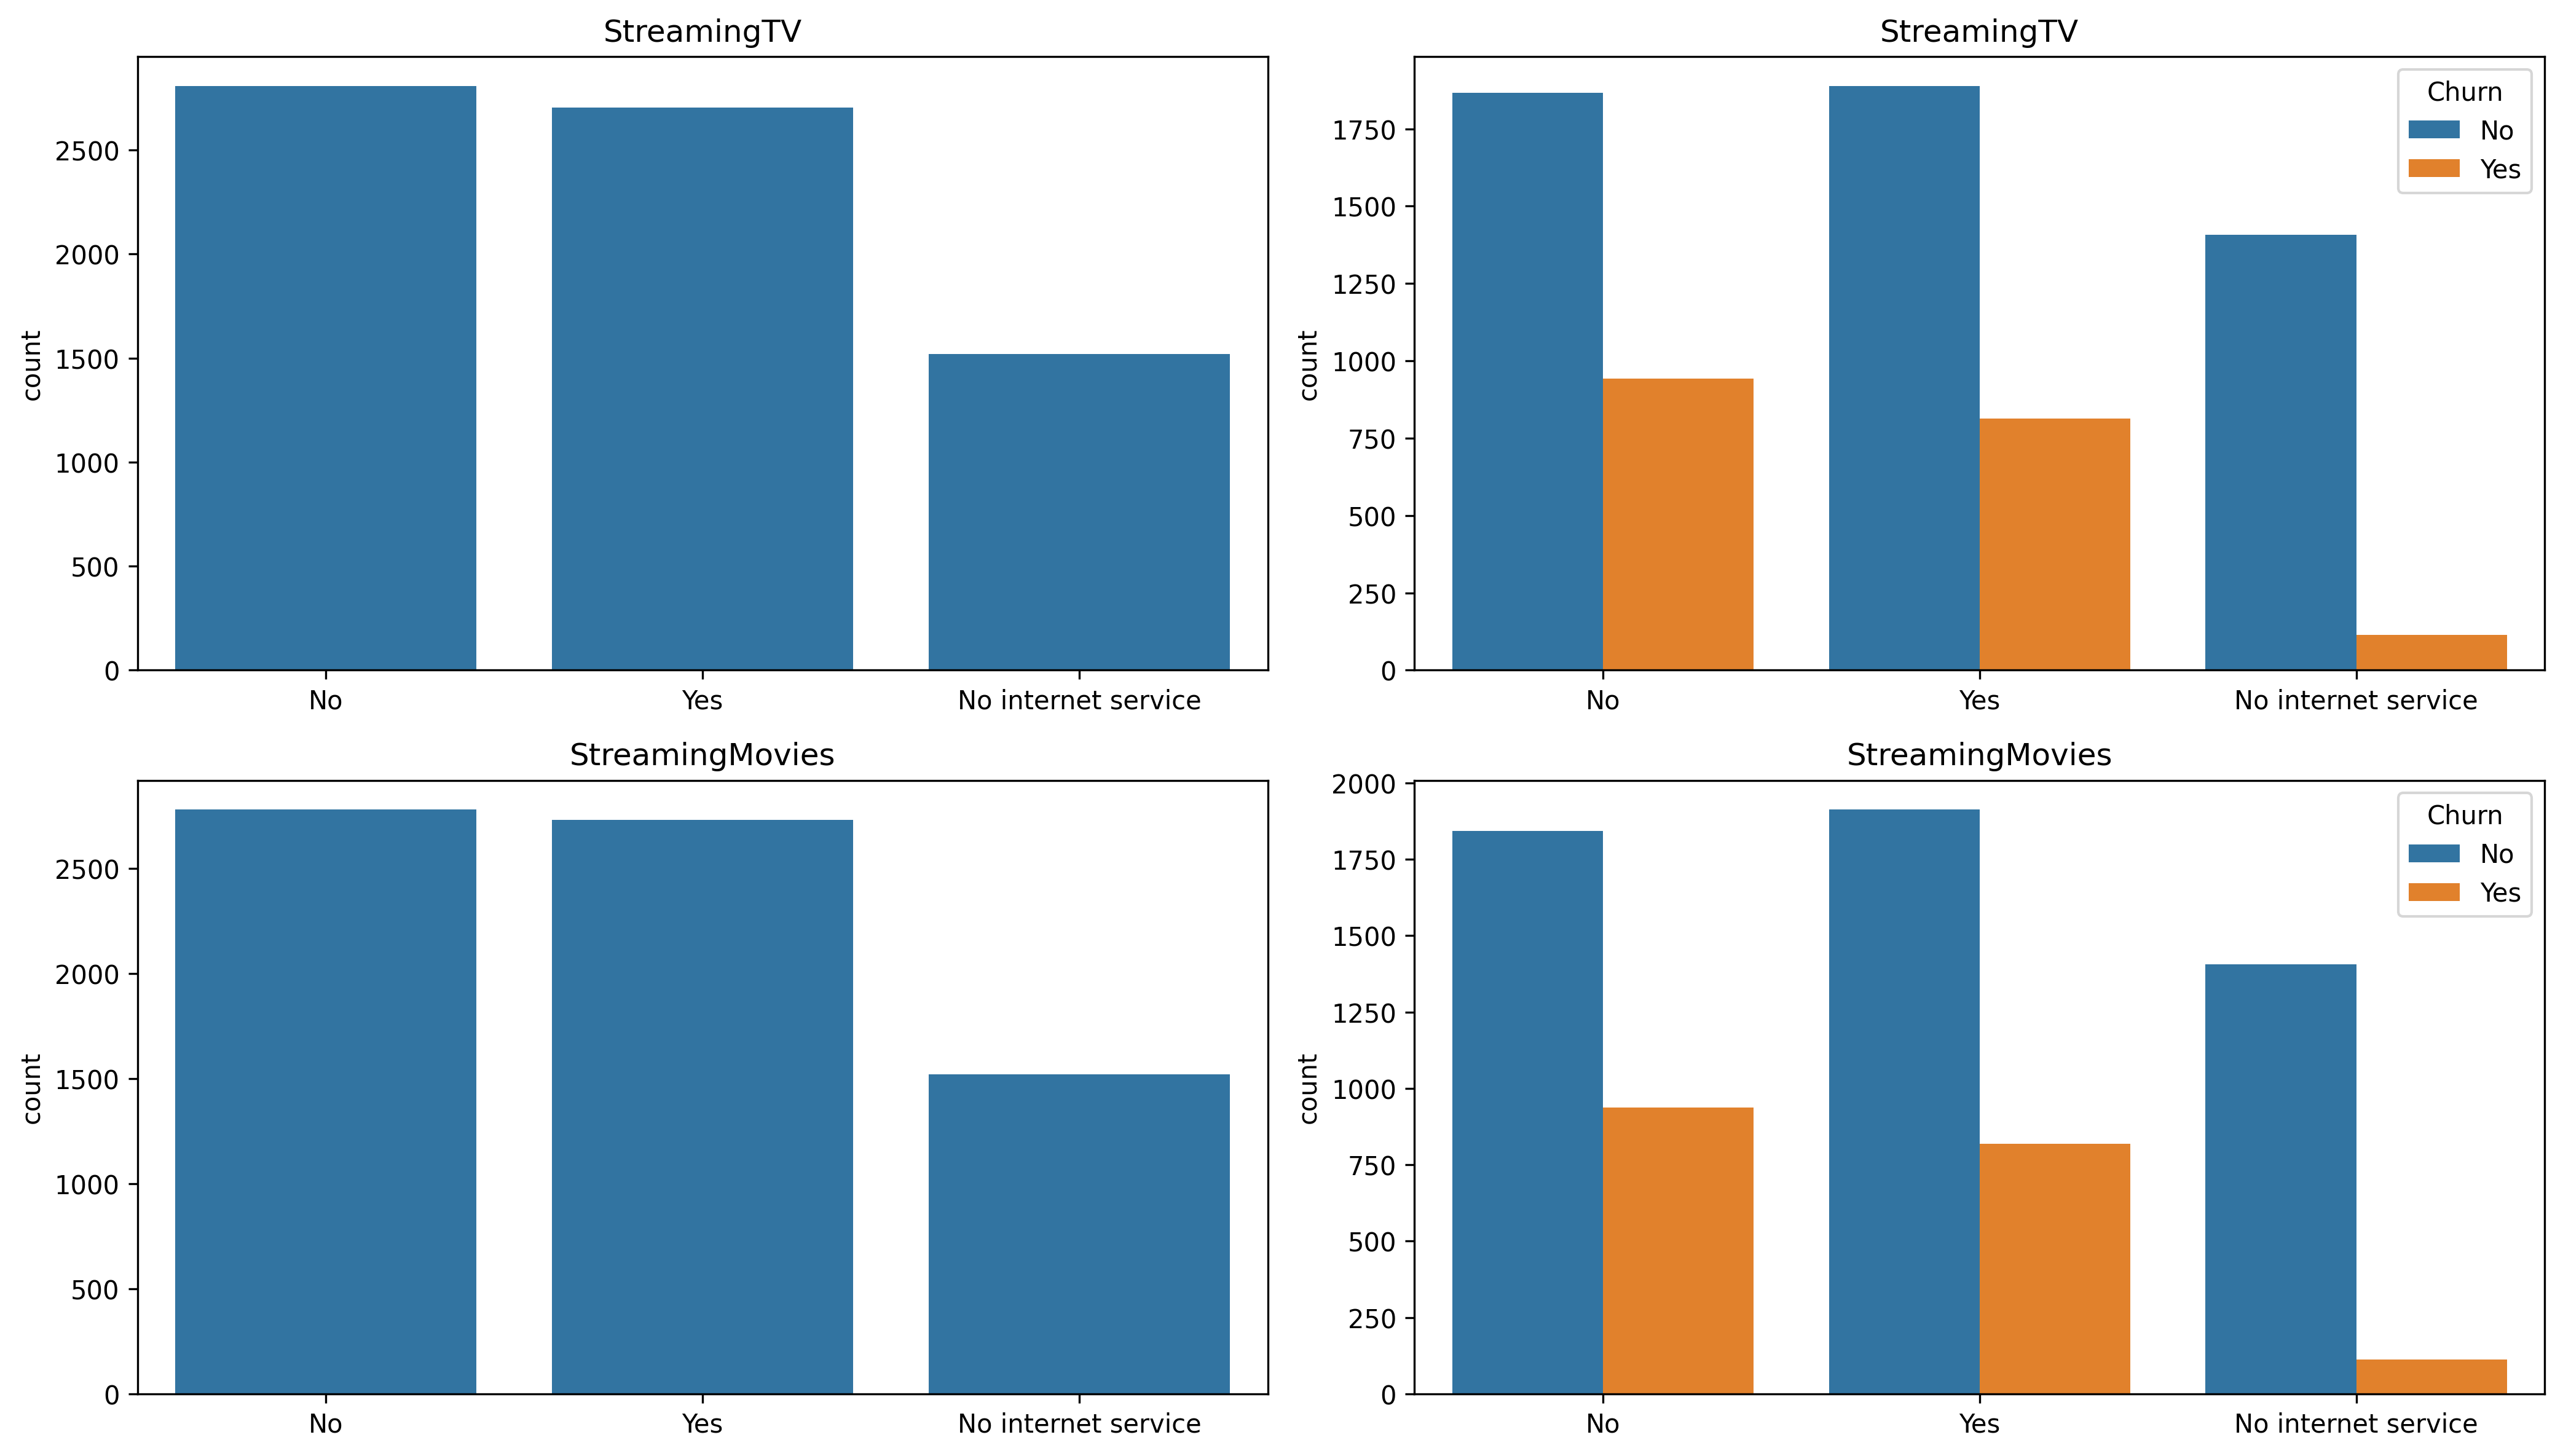

In [46]:
# Countplots for streaming services
fig, ax = create_countplots(df, cat_streaming, 
                            "Churn", figsize=(14, 8));

The following was noted in regards to streaming services:

**StreamingMovies**: 

Roughly an equal distribution of customers with and without streaming movie services, each making up about 40 percent of the total, with the remaining 20 percent of customers having no internet service. The churn ratio for both groups is about 2:1, with slightly higher churn among customers without streaming movies. However, this difference is marginal, indicating that churn rates are mostly similar between both groups.

**StreamingTV**: 

The distribution mirrors that of `StreamingMovies`, with about 40 percent of customers in each category, excluding those without internet service. Similarly, the churn ratio is approximately 2:1 for both groups, with a slightly higher churn in customers that do not use streaming TV services. As with `StreamingMovies`, the churn rates between both groups are mostly similar.

Overall, it doesn't seem like customer churn is heavily influenced by whether or not they subscribe to streaming services.

#### Summary of Visualisation Findings

In analysing the visualisations, the following categories were identified as significant indicators of churn:

- **SeniorCitizen**: *1 (Yes)*
- **Partner**: *No*
- **Dependents**: *No*
- **OnlineSecurity**: *No*
- **OnlineBackup**: *No*
- **DeviceProtection**: *No*
- **TechSupport**: *No*
- **ContractType**: *Month-to-month*
- **PaperlessBilling**: *Yes*
- **PaymentMethod**: *Electronic check*
- **InternetService**: *Fiber optic*

These key categories were further explored, once value counts were obtained, by calculating their corresponding churn percentages relative to both their respective variables and the overall dataset.

#### Value Counts and Percentages

To begin, value counts for each categorical variable were calculated and displayed.

In [47]:
# Loop through categorical columns
for col in cat_columns:
    # Obtain and print column value counts for colum
    value_counts = df[col].value_counts()
    print(f"\nValue counts for {value_counts}")


Value counts for gender
Male      3549
Female    3483
Name: count, dtype: int64

Value counts for SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

Value counts for Partner
No     3639
Yes    3393
Name: count, dtype: int64

Value counts for Dependents
No     4933
Yes    2099
Name: count, dtype: int64

Value counts for PhoneService
Yes    6352
No      680
Name: count, dtype: int64

Value counts for MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

Value counts for InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

Value counts for OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

Value counts for OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

Value counts for DeviceProtection
No                     3094
Yes  

The value counts appeared consistent with the patterns observed in the visualisations. Percentages were then calculated and  to gain a clearer picture of the category distributions.

In [48]:
# Loop through categorical columns
for col in cat_columns:
    # Obtain and print percentages
    vc_percentages = np.round(
        df[col].value_counts() / len(df) * 100, 2
    ) 
    print(f"\nPercentage of customers for {vc_percentages}")


Percentage of customers for gender
Male      50.47
Female    49.53
Name: count, dtype: float64

Percentage of customers for SeniorCitizen
0    83.76
1    16.24
Name: count, dtype: float64

Percentage of customers for Partner
No     51.75
Yes    48.25
Name: count, dtype: float64

Percentage of customers for Dependents
No     70.15
Yes    29.85
Name: count, dtype: float64

Percentage of customers for PhoneService
Yes    90.33
No      9.67
Name: count, dtype: float64

Percentage of customers for MultipleLines
No                  48.14
Yes                 42.19
No phone service     9.67
Name: count, dtype: float64

Percentage of customers for InternetService
Fiber optic    44.03
DSL            34.36
No             21.62
Name: count, dtype: float64

Percentage of customers for OnlineSecurity
No                     49.73
Yes                    28.65
No internet service    21.62
Name: count, dtype: float64

Percentage of customers for OnlineBackup
No                     43.90
Yes            

The percentages align closely with the estimations made when analysing the visualisations. Key observations include that a majority of customers hold *month-to-month* contracts and utilise *paperless billing*. Additionally, a significant proportion of customers (between 40 to 50 percent) lack *security and support services*, which could highlight an area for improvement in service offerings to customers, and potentially prevent customers from churning.

Several key metrics, including churn rates and percentages for the key categories noted earlier (see *Summary of Visualisation Findings*), were then collected and stored in a DataFrame for further analysis.

In [49]:
# Define key categories
key_cats = {
    "SeniorCitizen": 1, 
    "Partner": "No", 
    "Dependents": "No", 
    "PaperlessBilling": "Yes", 
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No", 
    "OnlineBackup": "No", 
    "DeviceProtection": "No", 
    "TechSupport": "No", 
    "Contract": "Month-to-month", 
    "PaymentMethod": "Electronic check"
}

# Initialise dictonary for category metrics
key_cat_metrics = {}
# Define total number of churners in dataset
total_churners = len(df[df["Churn"] == "Yes"])

# Collect metrics for each category
for variable, category in key_cats.items():
    
    # Define category name
    name = f"{variable} ({category})"

    # Calculate total number of customers in category
    cat_count = df[variable].value_counts().loc[category]
    
    # Filter DataFrame by variable and category
    feature_data = df[df[variable] == category]

    # Calculate number of churners in category
    churner_count = feature_data[feature_data["Churn"] == "Yes"].shape[0]

    # Define rate and percentage in category
    churn_rate = churner_count / cat_count
    churn_perc = np.round(churn_rate * 100, 2)
    
    # Find percentage with respect to total churners and total dataset
    percentage_of_churners = np.round(
        churner_count / total_churners * 100, 2
    )
    percentage_of_dataset = np.round(
        churner_count / len(df) * 100, 2
    )

    # Add to metrics dictionary
    key_cat_metrics[name] = (
        churn_rate,
        churn_perc,
        percentage_of_churners,
        percentage_of_dataset
    )

In [50]:
# Create DataFrame for key categories
key_cat_df = pd.DataFrame(
    key_cat_metrics
).T.reset_index()

# Define column names
key_cat_columns = [
    "Category",
    "Churn rate in category",
    "Percentage of churn in category",
    "Percentage of total churners",
    "Percentage of total dataset"
]

# Update DataFrame column names
key_cat_df.columns = key_cat_columns

In [51]:
key_cat_df

,Category,Churn rate in category,Percentage of churn in category,Percentage of total churners,Percentage of total dataset
0,SeniorCitizen (1),0.416813,41.68,25.47,6.77
1,Partner (No),0.329761,32.98,64.21,17.06
2,Dependents (No),0.312791,31.28,82.56,21.94
3,PaperlessBilling (Yes),0.335893,33.59,74.91,19.91
4,InternetService (Fiber optic),0.418928,41.89,69.40,18.44
5,OnlineSecurity (No),0.417787,41.78,78.17,20.78
6,OnlineBackup (No),0.399417,39.94,65.97,17.53
7,DeviceProtection (No),0.391403,39.14,64.79,17.22
8,TechSupport (No),0.416475,41.65,77.37,20.56
9,Contract (Month-to-month),0.427097,42.71,88.55,23.54


In analysing the key categories, several interesting observations were made. To support these observations, the `Churn percentage in category`, `Percentage of total churners`, and `Percentage of total dataset` columns were all visualised below with respect to `Category`.

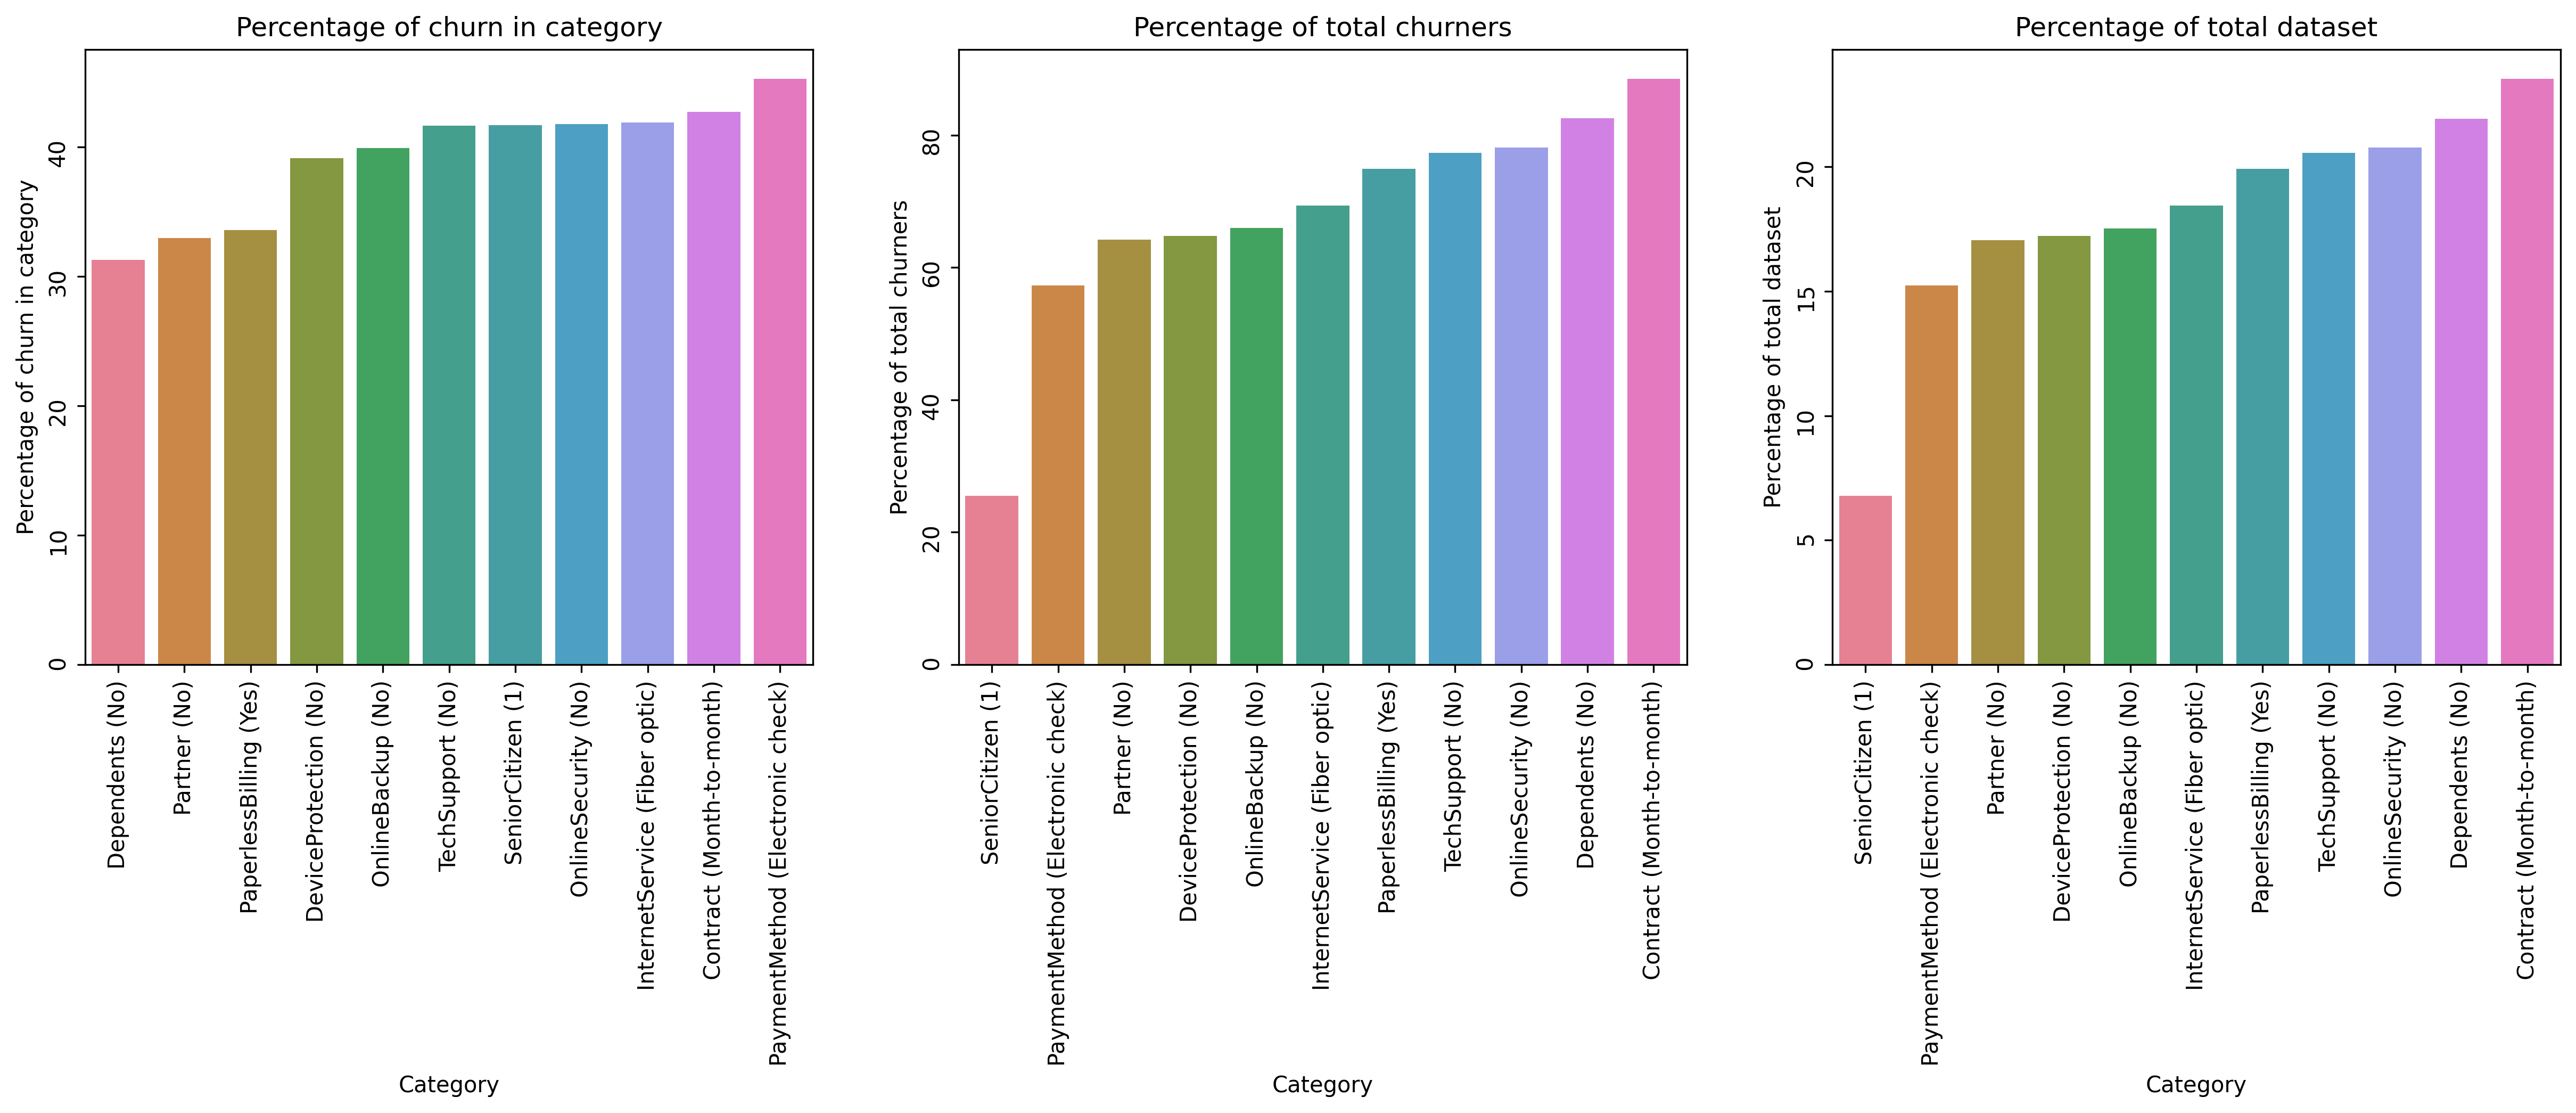

In [52]:
# Define columns to plot
columns_to_plot = key_cat_df.columns[2:]

# Set figure parameters
fig, ax = plt.subplots(1, 3, figsize=(20,5), dpi=300)

# Loop over subplots grid
for col, n in zip(columns_to_plot, range(3)):
    # Sort DataFrame 
    sorted_key_df = key_cat_df.sort_values(col)
    # Plot column
    sns.barplot(sorted_key_df, x="Category", 
                y=col, ax=ax[n], hue="Category")

    # Set title and rotate ticks
    ax[n].tick_params(labelrotation=90)
    ax[n].set_title(col)

# Show the plots
plt.show()

The visualisations helped to reveal some noteworthy trends:

- **All key categories** have churn rates exceeding 0.3, corresponding to 30 percent.
- **Electronic cheque payments show the highest churn rate** at 45.29 percent, closely followed by month-to-month contracts at 42.71 percent. Fibre optic internet users (*41.89 percent*), lack of online security (41.78 percent), senior citizens (*41.68 percent*), and lack of tech support (41.65 percent) also have significant churn rates above 40 percent.
- Month-to-month contracts account for 88.55 percent of total churners. Similarly, customers with no dependents represent 82.56 percent of total churners, while paperless billing users account for 74.91 percent.
- **The absence of security and support services**, especially online security (78.17 percent) and tech support (77.37 percent) **is prevalent among churners**.
- Despite making up only 6.77 percent of the total dataset, **senior citizens make up over a quarter of total churners** at 25.47 percent; while the lowest contributor among the listed variables, `SeniorCitizen` is nonetheless still a meaningful contributor.
- Electronic cheque payments, despite having the highest churn rate, is the second lowest contributor to total churn at 57.30 percent, though this is still more than double the contribution of senior citizens.
- Having no dependents shows the lowest churn rate at 31.28 percent, in contrast with its status as second highest contributor to percentage of total churners.

The findings indicated that customers with month-to-month contracts likely represent the most critical category for churn. Not only do they have a high churn rate of around 42 percent, but they also constitute the largest proportion of total churners close to an overwhelming 90 percent. Similarly, a lack of security and support services, including online security, online backup, device protection and tech support, is highly prevalent among churners, with churn rates around 40 percent and contributing between 65 and 78 percent of total churners. Hence these customers should be a priority group for targeted customer retention strategies.

Although electronic cheque payments account for a lower percentage of total churners, the category stands out for its particularly high churn rate, which is close to 45 percent. This suggests that payment method also plays an important role in customer retention.

While factors like paperless billing and no dependents exhibit lower churn rates, they still represent substantial proportions of total churners, with nearly 75 percent of churners using paperless billing and over 80 percent having no dependents. Hence these factors are still worth considering despite their lower churn rates.

The final steps of the exploratory data analysis involve conducting a chi-squared test on all categorical variables to further validate the relationships identified.

#### Chi-squared Test for Independence between Categorical Variables and Churn

To assess whether there were any statistically significant associations between `Churn` and the categorical variables in the dataset, a *chi-squared test for independence* was conducted. This test was selected since it's appropriate for determining whether two categorical variables are independent of each other, that is, that the occurence of one variable does not affect the occurence of another. This is ideal for understanding the relationship between `Churn` and the various customer attributes represented by the categorical variables. By testing for independence, the goal was to identify which variables are most strongly associated with customer churn.

As done with the Mann-Whitney U-Test earlier, a function was created to streamline the process and allow for efficient application of the chi-squared test across all the categorical variables.

In [53]:
def perform_chi_square_test(data, column_one, column_two):
    """
    Performs a chi-squared test of independence 
    on two columns of data. Creates a contingency
    table, performs the test, and evaluates the
    null hypothesis at the 5% and 1% significance
    levels. Takes a DataFrame 'data' and two
    columns 'column_one, column_two'.

    Returns a tuple with the chi-squared test 
    statistic and p-value, along with string messages 
    indicating whether or not the null hypothesis was 
    rejected (at the 5% and 1% significance level, 
    respectively).

    Note: The degrees of freedom and expected 
    frequencies ('dof' and 'freedom', respectfully) 
    are computed internally and not used in the 
    final output.
    """
    # Creating a contingency table
    contingency_table = pd.crosstab(data[column_one], data[column_two])

    # Perform chi-square test 
    stat, p, dof, expected = chi2_contingency(contingency_table)

    # Degrees of freedom (dof) and expected frequencies are
    # computed but not used in function output.

    # Interpret p-value
    if p < 0.05:
        five_sig = "Reject null hypothesis at 5%"
    else:
        five_sig = "Do not reject null hypothesis at 5%"
    
    if p < 0.01:
        one_sig = "Reject null hypothesis at 1%"
    else:
        one_sig = "Do not reject null hypothesis at 1%"

    # Return results
    return stat, p, five_sig, one_sig

The *null hypothesis* $H_0$ and *alternative hypothesis* $H_1$ are as follows:

\begin{align*}
&H_0: \text{There is no relationship between the two variables.} \\
&H_1: \text{A relationship exists between the two variables.}
\end{align*}

The tests were performed below.

In [54]:
# Initialise results dictionary
cs_test_results = {}

# Loop over categorical variables
for variable in cat_columns[:-1]:
    # Perform test and add to dictionary
    stat, p, f_sig, o_sig = perform_chi_square_test(df, variable, "Churn")
    association = variable + " and Churn"
    cs_test_results[association] = (stat, p, f_sig, o_sig)

# Show results
cs_test_results

{'gender and Churn': (np.float64(0.47545453727386294),
  np.float64(0.4904884707065509),
  'Do not reject null hypothesis at 5%',
  'Do not reject null hypothesis at 1%'),
 'SeniorCitizen and Churn': (np.float64(158.4408162893713),
  np.float64(2.4792557203954705e-36),
  'Reject null hypothesis at 5%',
  'Reject null hypothesis at 1%'),
 'Partner and Churn': (np.float64(157.50315146557506),
  np.float64(3.97379757451591e-36),
  'Reject null hypothesis at 5%',
  'Reject null hypothesis at 1%'),
 'Dependents and Churn': (np.float64(186.32163933855873),
  np.float64(2.0196592017051303e-42),
  'Reject null hypothesis at 5%',
  'Reject null hypothesis at 1%'),
 'PhoneService and Churn': (np.float64(0.8737327674431736),
  np.float64(0.34992398942431924),
  'Do not reject null hypothesis at 5%',
  'Do not reject null hypothesis at 1%'),
 'MultipleLines and Churn': (np.float64(11.271540824020612),
  np.float64(0.0035679273999811405),
  'Reject null hypothesis at 5%',
  'Reject null hypothesis 

All variables, except `gender` and `PhoneService`, reported substantial values for the chi-squared test statistic $\chi^2$, rejecting $H_0$ at both the 5 percent and 1 percent significance levels with $p < 0.01$, meaning there is strong evidence of an association between `Churn` and each corresponding categorical variable. This suggests that most of the categorical variables in the dataset are strongly linked to customer churn. 

A few of the variables reported particularly noteworthy results. `Contract`, in which *Month-to-month* was highlighted as a likely candidate for most significant category linked to churn, has $\chi^2 = 1180$ to 3 significant figures - the largest of all the *test statistic* values calculated. This gives very strong evidence in support of previous suggestions made about its importance regarding its association with churn. Similarly, the four security and support services, namely `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, and `TechSupport`, had, to 3 significant figures, values given by $\chi^2 \in \{847, 599, 555, 824\}$, respectively; this corresponds to a mean $\chi^2$ value of approximately 706 between them which, if they were represented a single variable, would constitute the third largest test statistic after `Contract` and `InternetService` ($\chi^2 \simeq 729$). Individually however, `OnlineSecurity` ($\chi^2 \simeq 847$) and `TechSupport` ($\chi^2 \simeq 825$) stand out, holding the second and third highest values overall. 

The results for `StreamingTV` ($\chi^2 \simeq 372$) and `StreamingMovies` ($\chi^2 \simeq 374$) were suprisingly high, surpassing even `PaperlessBilling` ($\chi^2 \simeq 257$). These results suggest a statistically significant relationship between `Churn` and streaming services services. However, it's essential to recognise that association does not necessarily imply causation, and there may be other factors or variables influencing this relationship. This was further investigated while looking at variable correlations to `Churn` after feature encoding.

Although `MultipleLines` had a chi-squared test statistic that still led to rejection of $H_0$ at both significance levels ($p < 0.01$), with $\chi^2 \simeq 11$, implying a statistically significant relationship with churn, its association is nonetheless substantially weaker compared to the other variables noted above.

In contrast, `PhoneService` ($\chi^2 \simeq 0.874$) and `gender` ($\chi^2 \simeq 0.475$) scored poorly, and $H_0$ was rejected at neither significance level ($p > 0.05$), meaning little to no evidence of association with `Churn` for these two variables. The results suggest that a customer's gender and whether they has phone service are unlikely to influence churn rates. Based on these findings, along with the fact that their distributions were roughly equal in the visualisations, the decision was made to drop these two variables in the dataset. In addition, `MultipleLines` was also dropped from the dataset in order to prioritise more significant predictors and reduce noise in the dataset.

Further details on the $\chi^2$ *test statistics* and $p$-values are shown in the above output. 

In [55]:
# Drop PhoneService, gender, and MultipleLines from data
df = df.drop(["PhoneService", "gender", "MultipleLines"], axis=1)

## Feature Encoding

For clarification, the term *variables* has been used throughout the report thus far when referring to column names in the dataset. However, from this point onwards, the term *features* will be used instead to reflect standard terminology in machine learning.

This section of the report covers *feature encoding* methods applied to the dataset in preparaton for model training and tuning. Categorical features were transformed from *string* to *numerical* format in order to ensure the data are easily understood by the machine learning algorithms. 

### Initial Inspection

To start, a new copy of the dataset was created with dummy variables generated for each column using `pd.get_dummies`. This was done so that the resulting columns could then be inspected, and the categories evaluated based on their ordering and distribution within the dataset.

In [56]:
# Perform one-hot encoding
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded.head()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen_0,SeniorCitizen_1,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,InternetService_DSL,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
0,1,29.85,29.85,1,0,0,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
1,34,56.95,1889.50,1,0,1,0,1,0,1,...,1,0,1,0,0,0,0,1,1,0
2,2,53.85,108.15,1,0,1,0,1,0,1,...,0,0,0,1,0,0,0,1,0,1
3,45,42.30,1840.75,1,0,1,0,1,0,1,...,1,0,1,0,1,0,0,0,1,0
4,2,70.70,151.65,1,0,1,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1


In [57]:
# Inspect columns
df_encoded.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen_0',
       'SeniorCitizen_1', 'Partner_No', 'Partner_Yes', 'Dependents_No',
       'Dependents_Yes', 'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaperlessBilling_No', 'PaperlessBilling_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
  

Looking at the encoded DataFrame, it became apparent that most of the features were best suited for this method of encoding (with the exception of `Contract` and the numerical features `tenure`, `MonthlyCharges` and `TotalCharges`). This is because there is no ordered relationship implied between the categories; for example, there isn't a clear natural hierarchy between different types of payment methods in `PaymentMethod`. 

Avoiding multicollinearity in the dataset is important, as it can negatively affect model performance. Hence it's good practice to drop one of the dummy variables to avoid redundancy and ensure the integrity of the model's interpretability. Although `pd.get_dummies` allows for dropping the leftmost category of each encoded feature, it was decided to manually one-hot encode the dataset instead. This choice was made to ensure logical consistency in the feature names based on the output of `df_encoded.columns` above. For instance, it's arguably more reasonable to drop the `OnlineBackup_No internet service` column from `OnlineBackup` than to drop `OnlineBackup_Yes`. While the algorithm will function correctly regardless of the encoding choice, maintaining a meaningful representation of the data is crucial for clarity; including both 'No' and 'No internet service' while omitting 'Yes' can be confusing for anyone reviewing the model, as it seems arbitrary and complicates feature interpretation.

In contrast `Contract` feature consists of contract lengths ranging from *Month-to-month* to *Two year*; these do in fact imply a relationship, indicating a length of commitment, and are thus ordinal in nature. Hence it was decided this particular feature would be better suited for integer encoding. 

Additionally, the `SeniorCitizen` column, initially represented as binary numerical values, was converted to an object datatype during the data cleaning phase of the project in order to facilitate exploratory data analysis (EDA) with the categorical features. Because of this, the `pd.get_dummies` function created two separate columns indicating 0 and 1, which was not appropriate here. Hence for the purposes of feature encoding, this column was reverted back to its original numerical format.

In [58]:
# Change datatype to int
df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)

### Manual One-hot Encoding

Manual one-hot encoding was employed to convert the afformentioned categorical features into binary format, in order to facilitate their use by machine learning models. The previously defined list of categorical columns, created near the beginning of the report, was sliced to distinguish between 2-level and 3-level features to simplify the encoding process; the 2-level features could be easily converted by dropping one level, while the 3-level features required a more nuanced approach. The 3-level `Contract` feature was integer encoded to better represent its ordinal nature, while the 4-level `PaymentMethod` feature was separately encoded later in this section.

In [59]:
# Define one-hot two category features 
hot_cat_two = (
    cat_columns[1:4] 
    + cat_columns[14:15]
    + cat_columns[-1:]
)

# Define one-hot three category features
hot_cat_three = cat_columns[6:13]

# Print lists
print(hot_cat_two, hot_cat_three)

['SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling', 'Churn'] ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


An updated instance of the encoded DataFrame was created using `pd.get_dummies`, focusing initially on the 2-level features. The first column in each feature was dropped to avoid multicollinearity.

In [60]:
# Encode two category features and drop first
df_encoded = pd.get_dummies(df, columns=hot_cat_two, 
                            dtype=int, drop_first=True)
df_encoded.head()

,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,MonthlyCharges,TotalCharges,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PaperlessBilling_Yes,Churn_Yes
0,1,DSL,No,Yes,No,No,No,No,Month-to-month,Electronic check,29.85,29.85,0,1,0,1,0
1,34,DSL,Yes,No,Yes,No,No,No,One year,Mailed check,56.95,1889.50,0,0,0,0,0
2,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Mailed check,53.85,108.15,0,0,0,1,1
3,45,DSL,Yes,No,Yes,Yes,No,No,One year,Bank transfer (automatic),42.30,1840.75,0,0,0,0,0
4,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check,70.70,151.65,0,0,0,1,1


Next, the 3-level features were encoded, albeit in a slightly different manner, as the first column in each feature was not dropped in this case.

In [61]:
# Encode three category features
df_encoded = pd.get_dummies(df_encoded, columns=hot_cat_three, 
                            dtype=int)
df_encoded.head()

,tenure,Contract,PaymentMethod,MonthlyCharges,TotalCharges,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PaperlessBilling_Yes,Churn_Yes,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,1,Month-to-month,Electronic check,29.85,29.85,0,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0
1,34,One year,Mailed check,56.95,1889.50,0,0,0,0,0,...,1,1,0,0,1,0,0,1,0,0
2,2,Month-to-month,Mailed check,53.85,108.15,0,0,0,1,1,...,0,1,0,0,1,0,0,1,0,0
3,45,One year,Bank transfer (automatic),42.30,1840.75,0,0,0,0,0,...,1,0,0,1,1,0,0,1,0,0
4,2,Month-to-month,Electronic check,70.70,151.65,0,0,0,1,1,...,0,1,0,0,1,0,0,1,0,0


To streamline the process, all columns containing the string *'No internet service'* were identified and dropped, along with the *InternetService_No* column. This process facilitated the tidying of the dataset and ensured no redundant columns were present.

In [62]:
# Define columns to drop
cols_to_drop = df_encoded.columns[
    df_encoded.columns.str.contains("No internet service")
]
# Additional column to drop
cols_to_drop = (
    cols_to_drop.tolist() 
    + ["InternetService_No"]
)

# Print list
print(cols_to_drop)

['OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'InternetService_No']


In [63]:
# Drop specified columns
df_encoded = df_encoded.drop(cols_to_drop, axis=1)
df_encoded.head()

,tenure,Contract,PaymentMethod,MonthlyCharges,TotalCharges,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PaperlessBilling_Yes,Churn_Yes,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,1,Month-to-month,Electronic check,29.85,29.85,0,1,0,1,0,...,0,1,1,0,1,0,1,0,1,0
1,34,One year,Mailed check,56.95,1889.50,0,0,0,0,0,...,1,0,0,1,1,0,1,0,1,0
2,2,Month-to-month,Mailed check,53.85,108.15,0,0,0,1,1,...,0,1,1,0,1,0,1,0,1,0
3,45,One year,Bank transfer (automatic),42.30,1840.75,0,0,0,0,0,...,1,0,0,1,0,1,1,0,1,0
4,2,Month-to-month,Electronic check,70.70,151.65,0,0,0,1,1,...,1,0,1,0,1,0,1,0,1,0


Following the encoding of the 3-level features, the next step involved manually one-hot encoding `PaymentMethod`. In this case, the first column was also not dropped.

In [64]:
# Manually one-hot encode 'PaymentMethod' feature
df_encoded = pd.get_dummies(df_encoded, columns=["PaymentMethod"], dtype=int)
df_encoded.head()

,tenure,Contract,MonthlyCharges,TotalCharges,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PaperlessBilling_Yes,Churn_Yes,InternetService_DSL,...,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,Month-to-month,29.85,29.85,0,1,0,1,0,1,...,1,0,1,0,1,0,0,0,1,0
1,34,One year,56.95,1889.50,0,0,0,0,0,1,...,1,0,1,0,1,0,0,0,0,1
2,2,Month-to-month,53.85,108.15,0,0,0,1,1,1,...,1,0,1,0,1,0,0,0,0,1
3,45,One year,42.30,1840.75,0,0,0,0,0,1,...,0,1,1,0,1,0,1,0,0,0
4,2,Month-to-month,70.70,151.65,0,0,0,1,1,0,...,1,0,1,0,1,0,0,0,1,0


After updating the encoded DataFrame, the level *'Credit card (automatic)'* was dropped because it had both the lowest churn rate and the lowest frequency in the `PaymentMethod` feature, which suggested it was less impactful on customer churn.

In [65]:
# Define column to drop
col_to_drop = "PaymentMethod_Credit card (automatic)"

# Drop lowest churn category within feature
df_encoded = df_encoded.drop(col_to_drop, axis=1)
df_encoded.head()

,tenure,Contract,MonthlyCharges,TotalCharges,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PaperlessBilling_Yes,Churn_Yes,InternetService_DSL,...,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,Month-to-month,29.85,29.85,0,1,0,1,0,1,...,0,1,0,1,0,1,0,0,1,0
1,34,One year,56.95,1889.50,0,0,0,0,0,1,...,1,1,0,1,0,1,0,0,0,1
2,2,Month-to-month,53.85,108.15,0,0,0,1,1,1,...,0,1,0,1,0,1,0,0,0,1
3,45,One year,42.30,1840.75,0,0,0,0,0,1,...,1,0,1,1,0,1,0,1,0,0
4,2,Month-to-month,70.70,151.65,0,0,0,1,1,0,...,0,1,0,1,0,1,0,0,1,0


### Integer Encoding for Contract

For the `Contract` feature, the initial approach was to use the pandas DataFrame `.replace` function to convert each category to its integer equivalent. However, due to a deprecation warning associated with `.replace`, a more robust method was chosen instead. The categories were encoded using the `.apply` method with a *lambda* function.

Specifically, the levels *Month-to-month*, *One year*, and *Two year* were encoded with the values 0, 1, and 2, respectively, reflecting the intuitive relationship between contract duration and numerical representation. The column was also renamed to `ContractLength` for clarity.

In [66]:
# Convert string values to integers in 'Contract'
df_encoded["Contract"] = df_encoded["Contract"].apply(
    lambda x: 0 if x == "Month-to-month" else (
        1 if x == "One year" else 2
    )
)

# Rename 'Contract' column to 'ContractLength'
df_encoded = df_encoded.rename(
    columns={"Contract": "ContractLength"}
)

In [67]:
df_encoded.head()

,tenure,ContractLength,MonthlyCharges,TotalCharges,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PaperlessBilling_Yes,Churn_Yes,InternetService_DSL,...,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,29.85,29.85,0,1,0,1,0,1,...,0,1,0,1,0,1,0,0,1,0
1,34,1,56.95,1889.50,0,0,0,0,0,1,...,1,1,0,1,0,1,0,0,0,1
2,2,0,53.85,108.15,0,0,0,1,1,1,...,0,1,0,1,0,1,0,0,0,1
3,45,1,42.30,1840.75,0,0,0,0,0,1,...,1,0,1,1,0,1,0,1,0,0
4,2,0,70.70,151.65,0,0,0,1,1,0,...,0,1,0,1,0,1,0,0,1,0


In [68]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tenure                                   7032 non-null   int64  
 1   ContractLength                           7032 non-null   int64  
 2   MonthlyCharges                           7032 non-null   float64
 3   TotalCharges                             7032 non-null   float64
 4   SeniorCitizen_1                          7032 non-null   int64  
 5   Partner_Yes                              7032 non-null   int64  
 6   Dependents_Yes                           7032 non-null   int64  
 7   PaperlessBilling_Yes                     7032 non-null   int64  
 8   Churn_Yes                                7032 non-null   int64  
 9   InternetService_DSL                      7032 non-null   int64  
 10  InternetService_Fiber optic              7032 no

After running the code and verifying the structure and contents of the encoded DataFrame, it is now fully prepared for model training and evaluation. However, since all the features are now encoded into numerical format, the correlations with `Churn_Yes` are visualised as a final check to examine relationships between the features and target.

In [69]:
# Define feature correlations
feat_correlation = df_encoded.corr()
# Inspect correlations to churn
corr_to_churn = feat_correlation["Churn_Yes"].sort_values()[0:-1]
corr_to_churn

ContractLength                            -0.396150
tenure                                    -0.354049
TotalCharges                              -0.199484
OnlineSecurity_Yes                        -0.171270
TechSupport_Yes                           -0.164716
Dependents_Yes                            -0.163128
Partner_Yes                               -0.149982
InternetService_DSL                       -0.124141
PaymentMethod_Bank transfer (automatic)   -0.118136
PaymentMethod_Mailed check                -0.090773
OnlineBackup_Yes                          -0.082307
DeviceProtection_Yes                      -0.066193
StreamingMovies_Yes                        0.060860
StreamingTV_Yes                            0.063254
StreamingTV_No                             0.128435
StreamingMovies_No                         0.130920
SeniorCitizen_1                            0.150541
PaperlessBilling_Yes                       0.191454
MonthlyCharges                             0.192858
DeviceProtec

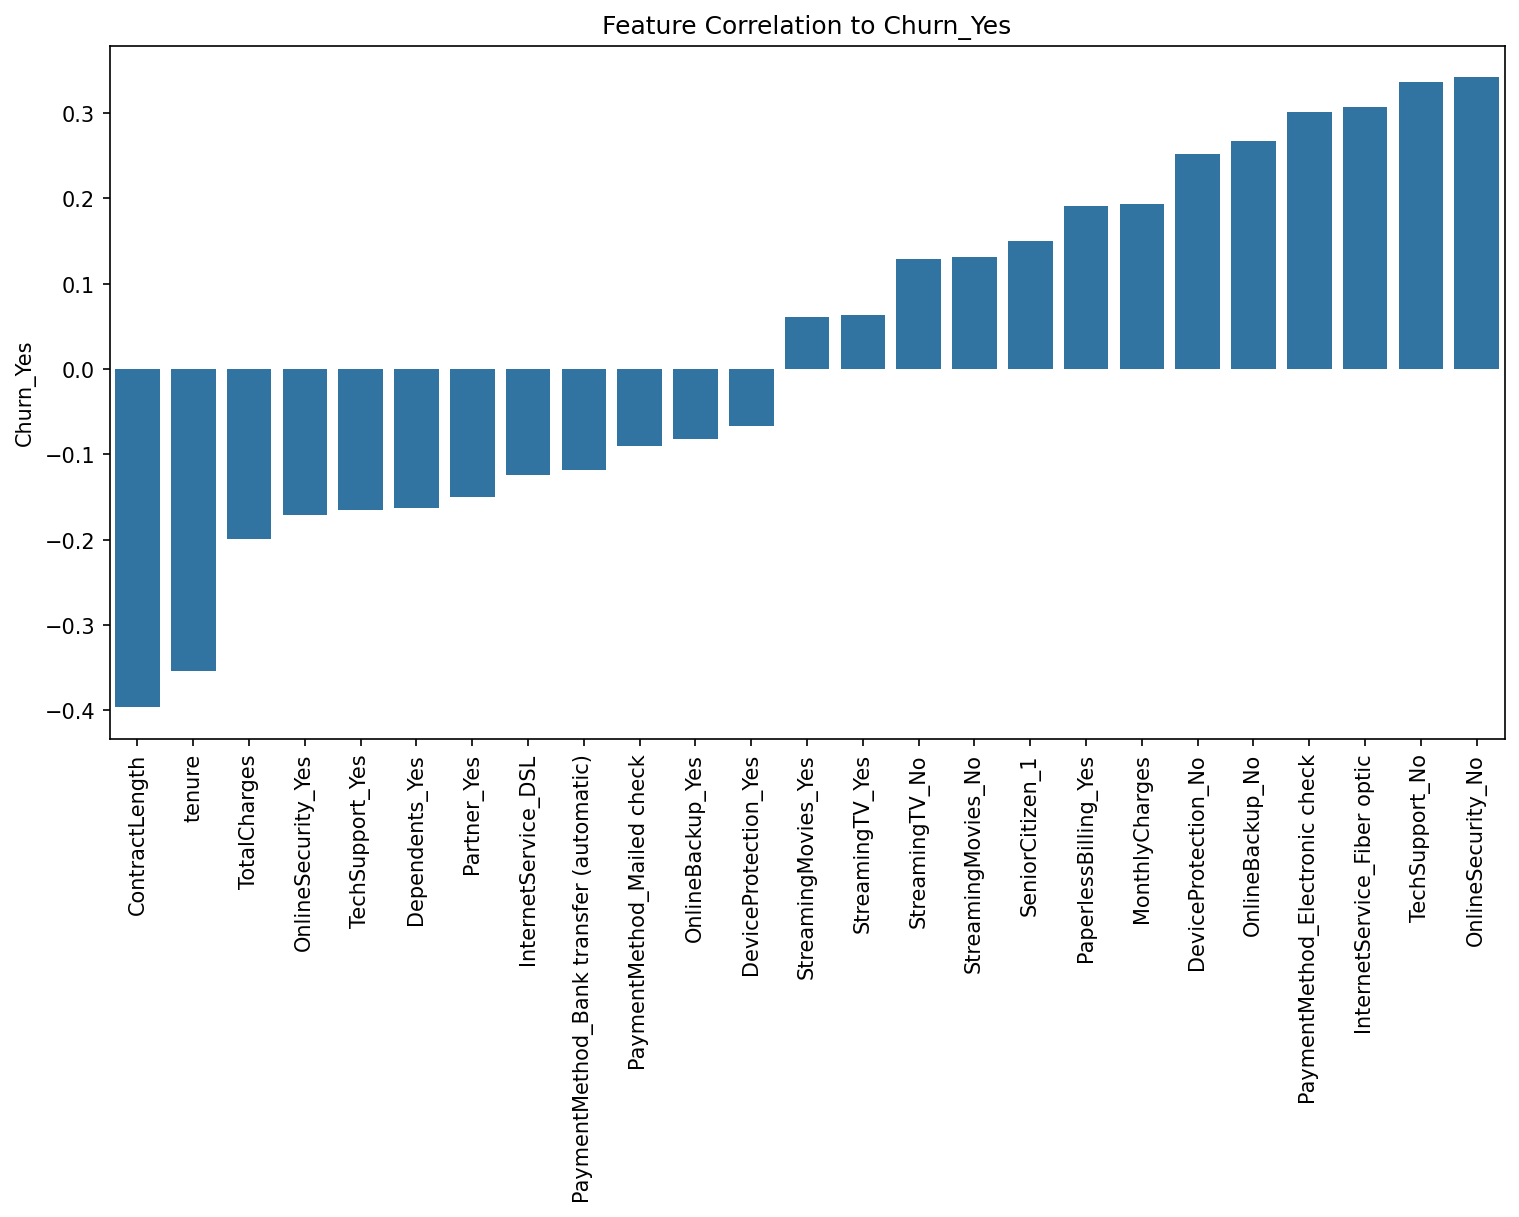

In [70]:
# Set figure parameters
plt.figure(figsize=(12, 6), dpi=150)

# Create bar plot
sns.barplot(corr_to_churn)

# Set title and xticks
plt.title("Feature Correlation to Churn_Yes")
plt.xticks(rotation=90);

Paying specific attention to the `StreamingMovies` and `StreamingTV` features, the correlation coefficients indicate weak relationships with `Churn`. The correlation for `StreamingMovies` is approximately 0.06 for Yes and around 0.13 for no, while `StreamingTV` shares similar values.

These weak correlations imply that these features do not provide meaningful predictive insights regarding customer churn, which align with the initial visual observations made during the exploratory data analysis, where count plots indicated limited significance of these features. Although the chi-Squared test suggested a statistical association with churn, the results here reinforce doubts regarding the importance of these features. As a result, these features were dropped from subsequent model training to further reduce the dimensionality of the dataset and improve model performance.

Additionally, during the model training phase, the *Random Forest* algorithm also ranked these features low in feature importance. This further supported the decision to exclude them, as their minimal contribution to the prediction of churn was evident.

In [71]:
# Define streaming columns
drop_streaming = df_encoded.columns[
    df_encoded.columns.str.contains("Streaming")
]
# Drop columns
df_encoded = df_encoded.drop(drop_streaming, axis=1)
df_encoded.head()

,tenure,ContractLength,MonthlyCharges,TotalCharges,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PaperlessBilling_Yes,Churn_Yes,InternetService_DSL,...,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,29.85,29.85,0,1,0,1,0,1,...,0,0,1,1,0,1,0,0,1,0
1,34,1,56.95,1889.50,0,0,0,0,0,1,...,1,1,0,0,1,1,0,0,0,1
2,2,0,53.85,108.15,0,0,0,1,1,1,...,1,0,1,1,0,1,0,0,0,1
3,45,1,42.30,1840.75,0,0,0,0,0,1,...,1,1,0,0,1,0,1,1,0,0
4,2,0,70.70,151.65,0,0,0,1,1,0,...,0,1,0,1,0,1,0,0,1,0


## Machine Learning Overview

In this part of the report, the context of the machine learning task is outlined. The project looks at a classification problem aimed at predicting customer churn. The target variable, `Churn`, indicates whether a customer has churned (1) or not (0).

### 2026 Update (Important)

This project was originally developed and published in 2024. Since then, several parts of the scikit-learn API used in the original implementation have been deprecated or removed. The code has therefore been updated where possible to maintain compatibility with newer versions of scikit-learn while preserving the original methodology and results as closely as possible.

In particular, the `algorithm` parameter used in `AdaBoostClassifier()` has been removed, the `penalty` parameter used in `LogisticRegression()` has been deprecated, and the use of `probability=True` within `SVC()` has also been deprecated in favour of explicit probability calibration. The Logistic Regression and AdaBoost changes do not materially affect the results reported in this project. However, replacing `SVC(probability=True)` with the newer `CalibratedClassifierCV(SVC(), ensemble=False)` alters the resulting Support Vector Machines predictions and evaluation metrics. For this reason, the original SVM implementation has been retained to preserve the behaviour and reproducability of the original analysis.

Unless otherwise stated, the analysis presented throughout the project reflects the original modelling process, with compatibility-related changes documented where relevant.

### Addressing Class Imbalance 

The dataset was found to exhibit a significant class imbalance. With an overall churn rate close to 27 percent, a notably higher number of customers in the dataset were non-churners as opposed to churners. This imbalance posed some challenges to model training and evaluation, as models in general tend to favour the majority class. 

To address the issue, class weighting was employed for models that supported this feature. For models lacking class weighting options, resampling techniques were employed. Specifically, the Synthetic Minority Over-sampling Technique (SMOTE) was utilised to create synthetic samples of the minority class, enhancing the model's ability to learn from the underrepresented `Churn` class.

### Evaluation Metrics

Since the dataset was imbalanced, *accuracy* can be a less reliable and potentially misleading measure of performance. Hence to ensure a more reliable assessment of model performance, particularly for the minority class, key metrics such as *precision*, *recall* and *F1-score* were emphasised, as well as the *Receiver Operating Characteristic Area Under the Curve (ROC-AUC)* and *Average Precision (AP)* scores. 

These metrics provided a more nuanced understanding of model performance beyond accuracy alone, allowing for a comprehensive evaluation of model effectiveness in predicting customer churn.

***An important caveat to note for the Support Vector Machines model:** The `predict_proba` method was used to obtain probability estimates for the ROC-AUC and PR-AUC scores by setting `probability=True`. Since SVMs are not inherently probabilistic, the reliability of these estimates may be limited, and this should be considered when interpreting the results.*

## Model Training

In this section of the report, performance benchmarks for a range of machine learning models were established by first training untuned baseline versions. These base models served as a reference point for later optimisation and comparison, to help understand their performance on the dataset before any class balancing or hyperparameter tuning was introduced.

The primary objective at this stage was to assess how well each machine learning algorithm performed 'out of the box' on predicting customer churn, using only default settings. To explore a diverse range of options, a combination of linear, non-linear, and ensemble models were chosen. The dataset was split into training, validation, and holdout sets to ensure robust performance evaluation, with standard scaling applied where necessary to ensure comparability between features.

By exploring these base models prior to optimisation and tuning, key insights into their performance characteristics were gained, helping to inform the subsequent modelling process.

### Preprocessing Steps

Before training the baseline models, exploratory steps were undertaken to assess the impact of the `TotalCharges` feature on model performance. It was previously observed that this feature approximately equals the product of `tenure` and `MonthlyCharges`, and it also strongly correlated with both features. To address potential collinearity issues, an initial Logistic Regression model was trained excluding the `TotalCharges` column.

Additionally, polynomial features were generated to explore whether non-linear, $n$-order transformations would improve model performance.

Ultimately, these changes did not result in significant performance improvements. Removing the `TotalCharges` column led to similar, if not slightly worse model performance compared to a model trained including the column. Furthermore, adding polynomial features not only proved computationally expensive for each $n$ degree, but performance actually deteriorated sharply with each $n+1$ degree tested (up to 4 degrees). 

As a result, it was decided to proceed without these alterations in the base models, and the corresponding experimental code has therefore been omitted from the final notebook.

### Helper Functions

The following helper functions are defined below, to streamline model training and evaluation throughout the *Model Training* section, as well as later during optimisation and evaluation of the models. 

These include the function `get_metrics()` for collecting performance metrics, as well as the function `show_matrix_and_report()` for generating confusion matrices and classification reports. The `get_name()` function extracts the model name from the model instance, and is used as a nested function to ensure the other two helper functions are able to work correctly.

In [72]:
def get_name(model):
    """
    Takes model instance as input and 
    returns model name as string.
    If Pipeline instance is given as input, 
    then the function will also extract
    the model name.

    Note: This function is used primarily
    to facilitate name extraction within
    the other helper functions.
    """

    # Extract name
    if isinstance(model, Pipeline):
        model_name = type(model[-1]).__name__
    else:
        model_name = type(model).__name__

    # Return name
    return model_name

In [73]:
def get_metrics(model, config, 
                X_test, y_test, proba=True):
    """
    Collect individual performance metrics 
    for a given model and return them in a 
    dictionary. 
    
    Takes model instance, model 
    configuration 'config' (string; e.g.
    'Base', 'Balanced', or 'Optimised'), 
    test set 'X_test' and 'y_test', and 
    (optionally) whether to collect
    probability estimates 'proba' 
    (Boolean: True/False; set to 
    true by default).
    """

    # Define model predictions and probabilities
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    
    # Calculate individual metrics for 'Churn Yes' class
    precision_yes = precision_score(y_test, y_pred)
    recall_yes = recall_score(y_test, y_pred)
    f1_yes = f1_score(y_test, y_pred)
    
    # Calculate individual metrics for 'Churn No' class
    precision_no = precision_score(y_test, y_pred, pos_label=0)
    recall_no = recall_score(y_test, y_pred, pos_label=0)
    f1_no = f1_score(y_test, y_pred, pos_label=0)

    # Create metrics dictionary
    metrics = {
        "Model": get_name(model),
        "Model Configuration": config,
        "Accuracy Score": accuracy,
        "Precision (Churn)": precision_yes,
        "Recall (Churn)": recall_yes,
        "F1 Score (Churn)": f1_yes,
        "Precision (No Churn)": precision_no,
        "Recall (No Churn)": recall_no,
        "F1 Score (No Churn)": f1_no,
    }

    # Calculate ROC-AUC and PR-AUC for the positive class
    if proba == True:
        metrics["Churn ROC-AUC Score"] = roc_auc_score(
            y_test, y_proba
        )
        metrics["Churn PR-AUC (AP) Score"] = average_precision_score(
            y_test, y_proba
        )
    else:
        None

    # Return metrics dictionary
    return metrics

In [74]:
# To format and display classification report
import io

In [75]:
def show_matrix_and_report(model, config, X_test, y_test,
                          labels=["No Churn", "Churn"],
                          figsize=(9, 3.5)):
    """
    Displays a confusion matrix and 
    classification report for a given model,
    displayed side-by-side. 
    
    Takes model instance, model 
    configuration 'config' (string; e.g.
    'Base', 'Balanced', or 'Optimised'), 
    test set 'X_test' and 'y_test',
    target class labels for matrix and 
    report 'labels' (list; set to 
    ["No Churn", "Churn"] by default),
    and figure size for subplots grid
    'figsize' (tuple, set to (9, 3.5) 
    by default.

    Note: pyplot.show() is not called
    within function.
    """

    # Define model predictions
    y_pred = model.predict(X_test)

    # Define subplots grid
    fig, ax = plt.subplots(1, 2, figsize=figsize)
    
    # Plot confusion matrix display
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax[0], display_labels=labels, colorbar=False
    )
    # Set title
    ax[0].set_title(
        f"{get_name(model)} ({config})\nConfusion Matrix Display", 
        y=1.03, fontsize=12
    )
    # Hide grid
    ax[0].grid(False)
    
    # Define classification report
    title = f"\n{get_name(model)} ({config}) Classification Report:\n"
    report = classification_report(
        y_test, y_pred, target_names=labels
         )
    # Create in-memory string buffer
    report_output = io.StringIO()
    # Print report to StringIO object
    print(title, report, file=report_output)
    report_text = report_output.getvalue()
    # close StringIO object
    report_output.close()
    
    # "Plot" classification report
    ax[1].text(
        0.01, 0.5, report_text, fontsize=10, 
        va="center", ha="left", family="monospace"
    )
    # Hide axis
    ax[1].axis("off")

    # Adjust padding
    plt.tight_layout()

### Train/Test Split

To effectively evaluate the performance of machine learning models, it's crucial to divide the dataset into separate training and testing subsets. This separation of the data allows for an unbiased assessment of the model's ability to generalise to unseen data.

The dataset was partitioned using a 70/20/10 split, of which 70 percent of the data was allocated for training the models, 20 percent for validating the models during the training process, and the remaining 10 percent reserved as a final *holdout* set for testing the final chosen model. This approach ensured that sufficient data was available for both training the models and evaluating their performance on unseen data, while also allowing for a final evaluation of the best performing model.

In [76]:
# Separate features and target variable
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=1066
)

# Split intermediary test set into validation and holdout
X_val, X_hold, y_val, y_hold = train_test_split(
    X_test, y_test, test_size=0.333, stratify=y_test, random_state=1066
)

# Delete intermediary test set to prevent accidental usage
del X_test, y_test

The `random_state` parameter is also key, as it ensures that the results are reproducible. By setting the seed to some arbitrary number, 1066 say, the same split can be achieved each time the code is executed, which is important for validation purposes as well as debugging. Additionally, stratified sampling was employed on the target column `Churn_Yes` with `stratify` in order to maintain class distribution, which further enhanced the representativeness of both the training and test sets, and ensuring that the model is trained and tested on data that accurately reflects the underlying class distributions.

### Feature Scaling

Feature scaling is particularly important for machine learning algorithms that rely on distance measures, such as K-Nearest Neighbours and Support Vector Machines, hence feature scaling was performed to standardise the range of the features, reducing the impact of bias towards features with very large values and ensuring that each feature contributes equally to model performance.

The `StandardScaler` transformation from `sklearn.preprocessing` was employed to standardise (or normalise) the features, by giving all the features a mean of zero and standard deviation of one. This ensured that all features were measured on a comparable scale.

In [77]:
# Initialise scaler
scaler = StandardScaler()

# Fit and transform scaler with training data 
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation data
X_val_scaled = scaler.transform(X_val)
# Transform hold-out data
X_hold_scaled = scaler.transform(X_hold)

Scaling was fitted only to the training data and *not* to the validation and holdout data. After fitting the scaler on the training data, the same scaler was used to transform all three sets. This approach ensures that the validation and test data are scaled based on the parameters derived from the training data and prevents data leakage, which occurs when information from the test set 'leaks' into the model and influences its training.

### Training Process

The training and initial performance of base models is discussed in this section. Each model was trained on the same train/validation split without any balancing or hyperparameter tuning applied at this stage. 

The purpose of this section is to establish base performance benchmarks for each model, providing a foundation for comparison with the later refined models. These benchmarks will highlight how each model performs 'out-of-the-box' and help identify potential areas for improvement when later techniques, including class balancing and hyperparameter tuning, are introduced later.

All models with a `random_state` parameter were set with the random state 1066, as used in the train/test split, to ensure consistency and reproducability of the results.

#### Logistic Regression

The *Logistic Regression* model was fitted to the training data, and then evaluated on the validation set.

In [78]:
# Initialise and fit logistic regression
lr_base = LogisticRegression(random_state=1066)
lr_base.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",1066
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

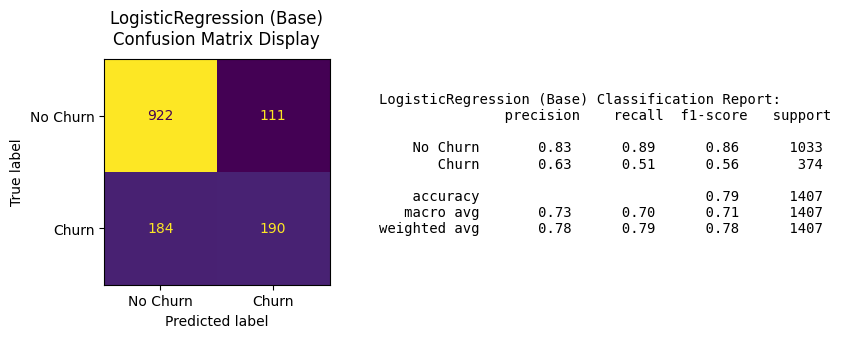

In [79]:
# Collect metrics
lr_base_metrics = get_metrics(lr_base, "Base", 
                              X_val_scaled, y_val)
# Show confusion matrix and classification report
show_matrix_and_report(lr_base, "Base",
                       X_val_scaled, y_val)

From the above metrics, precision and recall for the *No Churn* class were high, with an F1 score of 0.86, but considerably lower for the *Churn* class with an F1 score of only 0.56.

Notably, the recall for *Churn* was only 0.51, meaning the model failed to identify nearly half of the customers who churned. This is reflected by the confusion matrix which shows 190 correctly identified instances of *Churn*, whilst 184 customers were incorrectly predicted as *No Churn*. Additionally, the model also flagged 111 customers as churners when they were in fact non-churners.

While the model performed well in identifying instances of *No Churn*, it struggled to detect churners, resulting in a high number of false negatives. This highlights the model's tendency to favour the majority *No Churn* class, which is likely exacerbated by the class imbalance in the dataset.

#### K-Nearest Neighbours

The *K-Nearest Neighbours (KNN)* model was fit to the training data and evaluated on the validation set.

In [80]:
# Initialise and fit KNN
knn_base = KNeighborsClassifier()
knn_base.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


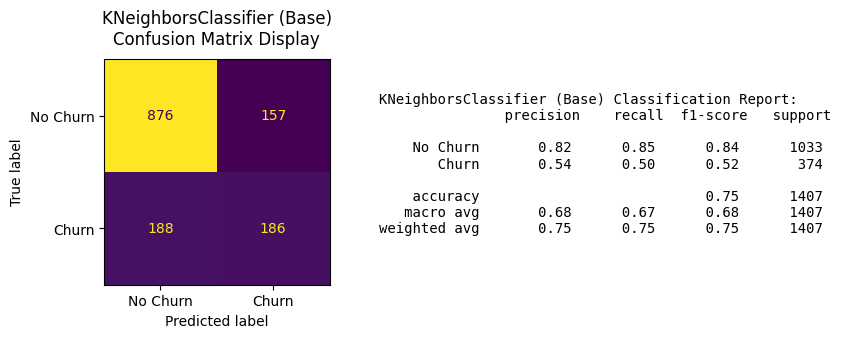

In [81]:
# Collect metrics
knn_base_metrics = get_metrics(knn_base, "Base",
                              X_val_scaled, y_val)
# Show confusion matrix and classification report
show_matrix_and_report(knn_base, "Base",
                       X_val_scaled, y_val)

Upon evaluating the metrics, KNN's performance was found to be similar to logistic regression, but with slightly worse performance overall. 

Precision for *Churn* was lower at 0.54, while recall was 0.50, indicating that the model detected only half of the customers who churned and also flagged more false positives than logistic regression. The F1 score for *Churn* was also lower, at 0.52 compared to 0.56 for logistic regression. This suggests that KNN struggled more with balancing precision and recall.

The confusion matrix further highlights these issues, with 186 positively identified instances of Churn, but 188 false negatives, meaning the model missed almost as many churners as it correctly identified. Additionally, 157 false positives were recorded, which is more than the 111 false positives seen in logistic regression.

While KNN's recall was similar to logistic regression, it suffered from a greater number of false positives as well as lower precision, likely exacerbated by the class imbalance in the dataset.

#### Support Vector Machines

The *Support Vector Machine (SVM)* model was trained on the training set and subsequently evaluated on the validation data.

In [82]:
# Initialise and fit SVM
svm_base = SVC(probability=True, random_state=1066)
svm_base.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1066
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


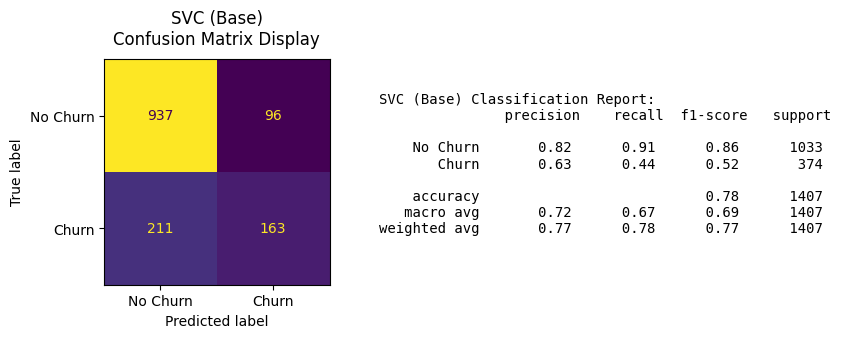

In [83]:
# Collect metrics
svm_base_metrics = get_metrics(svm_base, "Base",
                               X_val_scaled, y_val)
# Show confusion matrix and classification report
show_matrix_and_report(svm_base, "Base",
                       X_val_scaled, y_val)

The model demonstrated strong performance in predicting *No Churn*, but its performance on *Churn* was significantly weaker.

From the above metrics, recall for *Churn* was notably low at 0.44, indicating that less than half of customers who churned were correctly identified, meaning the model is failing to detect a significant number of churners; precision for *Churn* was 0.63, which is equal to that of logistic regression and higher than KNN. The confusion matrix shows 163 true positives, but 211 false negatives. The number of false positives is lower than both logistic regression and KNN at 96, corresponding with its higher precision.

For the *No Churn* class, SVM performed very well, with an F1 score of 0.86, which further highlights that the model is highly effective at identifying non-churners, but poor at identifying churners. Once again, this highlights the impact of class imbalance, as the model favours the majority class *No Churn* at the expense of correctly predicting the minority class *Churn*. 

#### Random Forests

The *Random Forest* model was trained and evaluated on the validation set.

In [84]:
# Initialise and fit Random Forests
rf_base = RandomForestClassifier(random_state=1066)
rf_base.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1066
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap boots

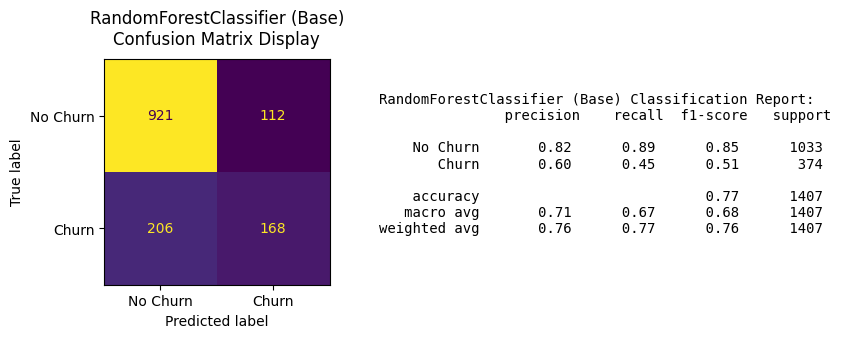

In [85]:
# Collect metrics
rf_base_metrics = get_metrics(rf_base, "Base",
                              X_val, y_val)
# Show confusion matrix and classification report
show_matrix_and_report(rf_base, "Base",
                       X_val, y_val)

Despite high expectations, due to its status as an ensemble method known for capturing complex relationships in data, the model performed dissapointingly, especially on the *Churn* class.

The model's recall for *Churn* was 0.45, meaning it missed more than half of the customers who churned. Precision for churn was 0.60, indicating that it also misclassified a significant number of non-churners as churners. The confusion matrix confirms these observations, with 168 true positives, 206 false negatives, and 112 false positives, reflecting its difficulty in effectively detecting churners.

Its performance overall was comparable to SVM, suggesting that class imbalance remained a significant challenge for this model.

#### Gradient Boosting

The *Gradient Boosting* model was trained and evaluated on the validation set.

In [86]:
# Initialise and fit Gradient Boosting
gb_base = GradientBoostingClassifier(random_state=1066)
gb_base.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1066
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (

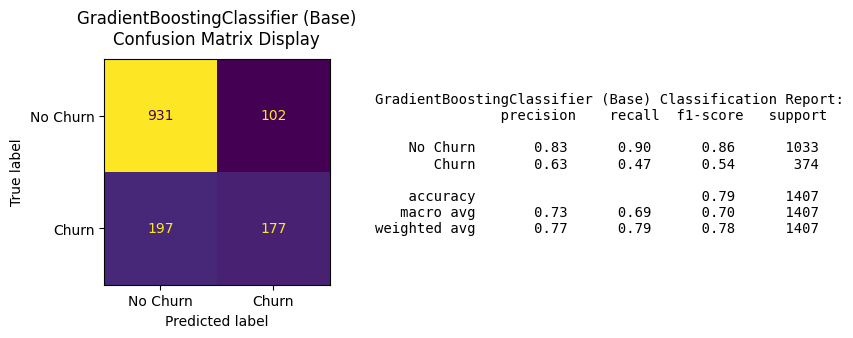

In [87]:
# Collect metrics
gb_base_metrics = get_metrics(gb_base, "Base",
                             X_val, y_val)
# Show confusion matrix and classification report
show_matrix_and_report(gb_base, "Base",
                       X_val, y_val)

The model showed comparable performance to SVM and Random Forests. For the *Churn* class, it's precision and recall were 0.63 and 0.47, respectively, meaning more than half of churners were not detected. On the other hand, the model performed well on the *No Churn* class, achieving a precision of 0.83 and a recall of 0.90. The confusion matrix revealed 177 true positives and 197 false negatives, reflecting the model's low recall.

While Gradient Boosting performed slightly better than Random Forests in terms of precision and recall for *Churn*, the class imbalance continued to affect the model's ability to detect churners effectively.

#### Adaptive Boosting

The *AdaBoost* model was trained, and then evaluated on the validation set.

In [88]:
# Initialise and fit AdaBoost
ada_base = AdaBoostClassifier(random_state=1066) 
ada_base.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1066
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.27,0.27,0.35,...,0.5 ,0.48,0.49]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[1.02,0.97,0.62,...,0.02,0.07,0.03]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1533379431), DecisionTreeC...te=2100181945), DecisionTreeC...ate=286282891), DecisionTreeC...ate=422344531), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](21,)","[0.23,0.37,0.1 ,...,0.01,0.04,0. ]"


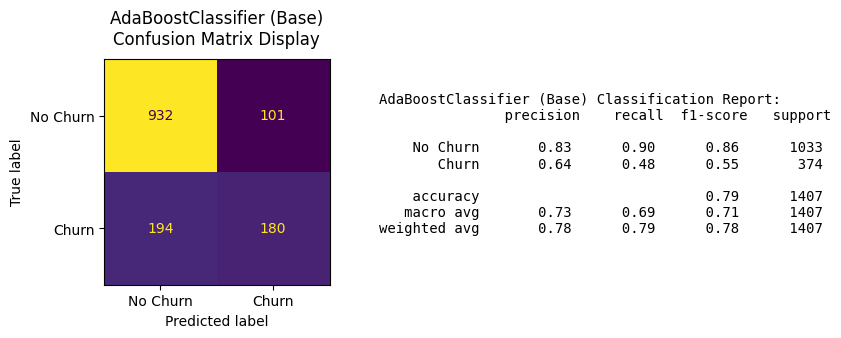

In [89]:
# Collect metrics
ada_base_metrics = get_metrics(ada_base, "Base",
                               X_val, y_val)
# Show confusion matrix and classification report
show_matrix_and_report(ada_base, "Base",
                       X_val, y_val)

AdaBoost reported the best relative performance among the ensemble models, although its overall performance was only modest. 

For the *Churn* class, the model achieved a precision of 0.64 and a recall of 0.48, with an overall F1 score of 0.55 for *Churn*; for the *No Churn* class, the model performed very well with a precision and recall of 0.83 and 0.90, respectively, and a corresponding F1 score of 0.86. The confusion matrix reported 180 true positives, 194 false negatives, and 101 false positives.

Despite being the best performer among the ensemble models, AdaBoost still struggled with class imbalance along with all the other base models, failing to consistently detect churners in the data.

### Results

The table below provides a summary of key performance metrics, including accuracy, precision, recall, and F1 score for both the *Churn* and *No Churn* classes across all the base models. A bar chart was also visualised to compare the models based on precision, recall, and F1 score for the *Churn* class.

In [90]:
# Define list of base model metrics
base_metrics = [
    lr_base_metrics,
    knn_base_metrics,
    svm_base_metrics,
    rf_base_metrics,
    gb_base_metrics,
    ada_base_metrics
]

# Create DataFrame
df_base_metrics = pd.DataFrame(base_metrics)
df_base_metrics

,Model,Model Configuration,Accuracy Score,Precision (Churn),Recall (Churn),F1 Score (Churn),Precision (No Churn),Recall (No Churn),F1 Score (No Churn),Churn ROC-AUC Score,Churn PR-AUC (AP) Score
0,LogisticRegression,Base,0.790334,0.631229,0.508021,0.562963,0.833635,0.892546,0.862085,0.836056,0.608203
1,KNeighborsClassifier,Base,0.754797,0.542274,0.497326,0.518828,0.823308,0.848015,0.835479,0.753753,0.484844
2,SVC,Base,0.781805,0.629344,0.435829,0.515008,0.816202,0.907067,0.859239,0.793361,0.589318
3,RandomForestClassifier,Base,0.773987,0.600000,0.449198,0.513761,0.817214,0.891578,0.852778,0.806908,0.584659
4,GradientBoostingClassifier,Base,0.787491,0.634409,0.473262,0.542113,0.825355,0.901258,0.861638,0.841401,0.642665
5,AdaBoostClassifier,Base,0.790334,0.640569,0.481283,0.549618,0.827709,0.902227,0.863363,0.835805,0.618258


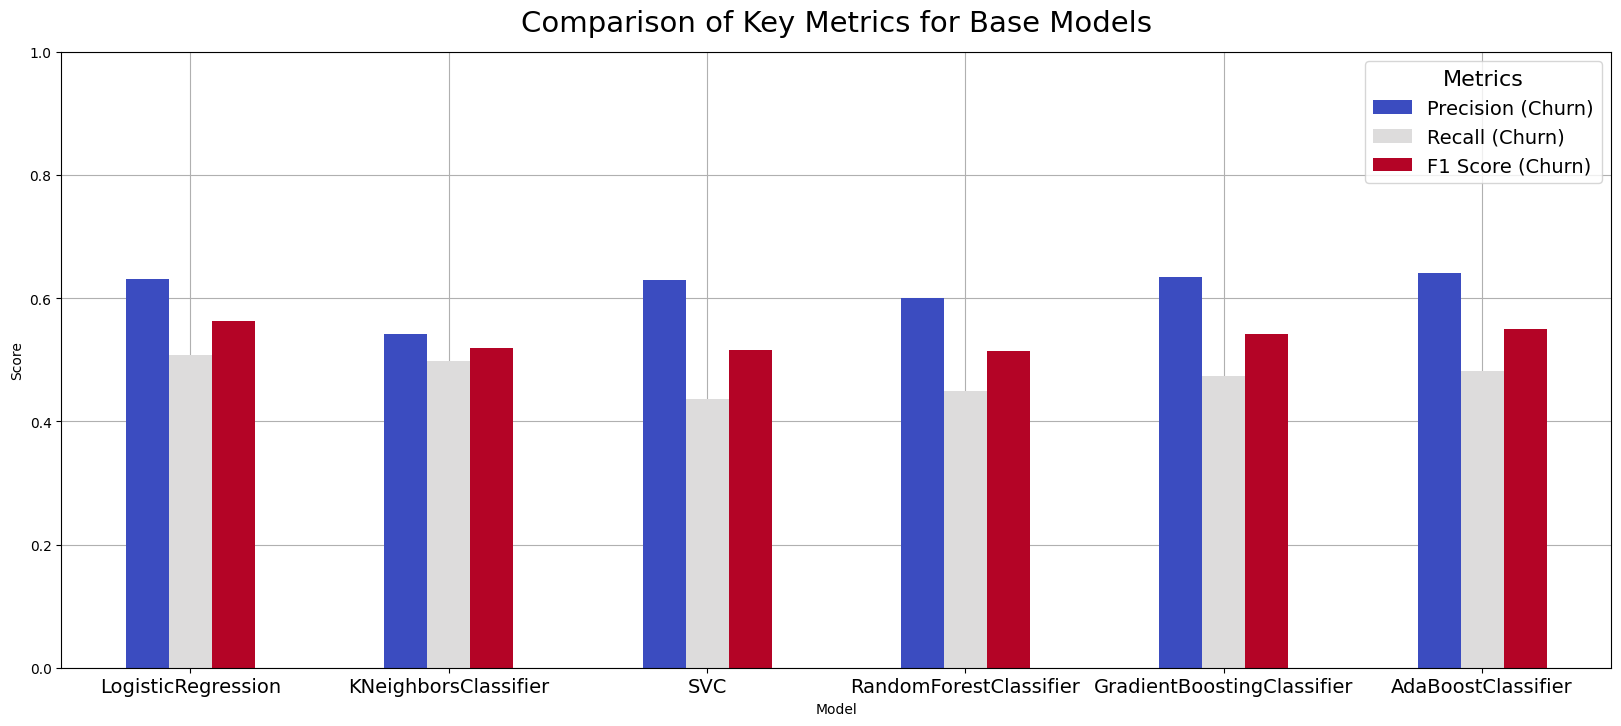

In [91]:
# Define metrics to visualise
metrics = df_base_metrics.columns[3:6]

# Plot metrics
df_base_metrics.plot(
    x="Model", 
    y=metrics, 
    kind="bar", 
    grid=True, 
    zorder=2, 
    figsize=(20, 8), 
    cmap="coolwarm"
)

# Set title and labels
plt.title(
    "Comparison of Key Metrics for Base Models",
    y=1.02, fontsize=21
)
plt.ylabel("Score")
plt.xlabel("Model")
# Set xticks
plt.xticks(fontsize=14, rotation=0)
# Set ylim
plt.ylim(0, 1)

# Set legend and layout
plt.legend(
    title="Metrics", 
    bbox_to_anchor=(1,1), 
    fontsize=14, 
    title_fontsize=16
)
plt.tight_layout;

### Observations

Upon reviewing the results of all the base models, several noticeable patterns emerged. Regarding accuracy, all models showed comparable scores ranging from approximately 0.75 to 0.79. Logistic Regression and AdaBoost scored highest at around 0.79 (both scores are in fact identical to 6 decimal places). However, since accuracy is a less reliable metric here due to the class imbalance in the dataset, it follows that precision (rate of correct positive predictions) and recall (rate of correctly identified positives) are more important metrics to consider in this context. Unless otherwise specified, the precision, recall and F1 score metrics discussed here refer to those specifically from the *Churn* class.

Looking at recall, Logistic Regression stands out again with the highest score at 0.51, followed by KNN at 0.497, and AdaBoost at 0.48. This suggests that these models are relatively more effective in capturing churners compared to the other three models, though Logistic Regression takes the lead slightly. SVM scored the lowest for recall at 0.44, meaning its performance was poorest in identifying churners.

For precision, AdaBoost takes the lead with a score of 0.64, followed closely by Gradient Boosting and Logistic Regression both at approximately 0.63. These models proved to be more reliable in making accurate positive (churn) predictions. The worst performer for precision was KNN, lagging behind at 0.54, and notably lower than the model with the second lowest score for precision, which was Random Forests at 0.60.

In terms of F1 score, which refers to the harmonic mean of precision and recall, scores ranged from 0.51 to 0.56. Logistic Regression scored the highest at 0.56, closely followed by AdaBoost at 0.55. Random Forest scored the lowest at 0.51.

The ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) scores and PR-AUC (Precision Recall - Area Under the Curve) scores were not the primary focus for the base model evaluations, although these will become more relevant be considered when analysing the optimised models. However, the base model scores for ROC-AUC ranged from 0.75 (KNN) to 0.84 (Logistic Regression), while PR-AUC scores ranged from 0.48 (KNN) to 0.64 (Gradient Boosting). These metrics briefly highlight how well the models discriminate between classes and manage the balance between precision and recall, which is particularly important in imabalanced datasets like this one. PR-AUC, in particular, helps gauge the models' effectiveness in predicting churners, and is the more informative metric of the two for this particular dataset.

Overall, Logistic Regression and AdaBoost so far have showed the strongest performance across most metrics, particularly in recall and F1 score, suggesting they may be more suited for identifying churners compared to other models. While Gradient Boosting exceeded the former mentioned models in precision and PR-AUC, it slightly lagged in recall, indicating it is better at making accurate predictions but at the cost of missing churners. KNN, despite having the second highest recall, struggled with and had the lowest PR-AUC, meaning it doesn't balance precision and recall well. SVM on the other hand, had the lowest recall of all models, but had relatively good precision compared to the rest. These results provide a useful baseline for further optimisation and model refinement, where class balancing and hyperparameter tuning is applied to improve model performance, particularly in better handling the class imbalance.

## Model Optimisation and Hyperparameter Tuning

In this section of the report, the focus now shifts towards optimising the models. The primary goal was to enhance the models' prediction abilities, particularly for the minority class *Churn*, where *recall* was prioritised. Given the imbalanced nature of the dataset, optimising for recall was a strategic choice aimed at identifying as many at-risk customers as possible.

Throughout the tuning process, emphasis was placed on maintaining a *recall-focused approach*, while ensuring that the *precision* did not fall below 50 percent. The threshold for precision was selected to reflect a balance between catching churners and avoiding an excessive number of false positives, though it's important to note that this threshold is a simplified assumption for the purposes of this project. In a real-world setting, depending on the needs of a business, one may choose to a lower or higher threshold for precision based on their unique goals and available resources. For example, a company with a smaller budget may aim for a higher precision to avoid unnecessary expenditures on customer retention strategies, whereas a business facing a high churn rate may compromise on having more false positives in order to maximise recall and pre-emptively address potential churners. For this project, the latter example was assumed.

The optimisation process began with first employing class balancing techniques to mitigate the majority class bias, that is, towards non-churners. For models with built-in class weight parameters, such as Logistic Regression, SVM, and Random Forests, class weights were adjusted to counter the imbalance between churners and non-churners. For models without built-in class weight options, including KNN, Gradient Boosting and AdaBoost, resampling techniques were employed using SMOTE instead. This approach allowed for targeted optimisation, ensuring that each model was tuned in a way that was appropriate for its specific capabilities.

In this report, the precision-recall performance is summarised using the *Average Precision (AP)* score, which provides a single number representing the area under the Precision-Recall (PR-AUC). Although AP and PR-AUC are sometimes distinguished, they represent equivalent values in this context. *Hence, within this report, PR-AUC and AP will be used interchangeably.*

### Helper Functions

In addition to the previously developed helper functions, a few new ones were created to further streamline the model evaluation process.

The `plot_learning_curve()`, `plot_roc_pr_curves()`, and `display_evaluation()` functions were implemented. The first two functions plot the learning curve for a model to ensure the model is not over- or under-fitting the data, as well as plot the ROC-AUC and PR-AUC curves side-by-side to visualise the precision-recall trade-off; the `display_evaluation()` function serves as a comprehensive tool that combines all evaluations by plotting the learning curve, ROC-PR curves, and displaying the confusion matrix alongside the classification report in one go (or selectively), making the evaluation process more efficient.

The `unfit_model()` function was also added specifically for use within the `plot_learning_curve()` function. This function takes a fitted model or pipeline instance and returns an unfitted estimator, enabling pipelines to be passed into the learning curve function without issue.

In addition, the `custom_score()` function was implemented to guide model selection, during grid search optimisation, towards higher recall while maintaining a minimum precision threshold. The function calculates recall and precision for the *Churn* class and only returns the recall value if precision meets or exceeds 0.5. Otherwise, it returns 0, ensuring that low-precision models are not favoured, even if they achieve high recall.

In [92]:
# Used within learning_curve_from_fitted function
def unfit_model(fitted_model):
    """
    Takes fitted model or Pipeline
    instance as input, and returns an
    unfitted estimator with identical
    model parameters or Pipeline 
    steps.
    """

    # Define model class
    model_class = fitted_model.__class__

    # Unfit model
    if isinstance(fitted_model, Pipeline):
        steps = fitted_model.steps
        unfitted_model = model_class(steps)
    else:
        params = fitted_model.get_params()
        unfitted_model = model_class(**params)

    return unfitted_model

In [93]:
def custom_score(y_true, y_pred):
    """
    A custom scoring function for prioritising 
    recall, conditioned on a precision threshold 
    of 0.5.
    """

    # Define recall of positive class
    recall = recall_score(y_true, y_pred)
    # Define precision of positive class
    precision = precision_score(y_true, y_pred)
    # Return recall if criteria is satisfied
    return recall if precision >= 0.5 else 0

# Define custom scorer for GridSearchCV
scorer = make_scorer(custom_score)

In [94]:
def plot_learning_curve(
    model, config, 
    X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1, 10),
    figsize=(6, 4)
):
    """
    Plots learning curve for model instance; 
    plots the training and cross-validation 
    scores as the training set size increases.
    
    Takes model or Pipeline instance 'model', 
    model configuration 'config' (string, 
    e.g. 'Base', 'Balanced', or 'Optimised'), 
    training data 'X_train' and 'y_train', 
    number of cross-validation folds 'cv'
    (int; default 5), number of training 
    examples used to plot curve 'train_sizes'
    (array; defaults to 10 different sizes
    from 10% to 100%), and figure size 
    'figsize' (tuple; (6, 4) by default).

    Notes: 
        - New model instance is created within
          function using unfit_model(fitted_model)
          to pass through learning_curve().
        - Model name is extracted within function 
          using get_name(model).
        - Default value used for cross-validation 
          folds 'cv' is 5 (int).
        - 'train_sizes' (array) defaults to 10 
          different sizes from 10% to 100%.
        - pyplot.show() is not called within the 
          function.
    """

    # Define estimator
    estimator = unfit_model(model)
    
    # Calculate learning curves
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, 
        X_train, 
        y_train, 
        cv=cv, 
        train_sizes=train_sizes,
        n_jobs=-1
    )

    # Calculate mean and std dev of training and test scores
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curves
    plt.figure(figsize=figsize)

    # Plot training and test scores
    plt.plot(train_sizes, train_scores_mean, "o-", 
             color="red", 
             label=f"Training Score")
    plt.plot(train_sizes, test_scores_mean, "o-", 
             color="green", 
             label=f"Cross-Validation Score")

    # Plot confidence interval for training and test scores
    plt.fill_between(train_sizes, 
                     train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std,
                     alpha=0.1, color="red")
    plt.fill_between(train_sizes, 
                     test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std,
                     alpha=0.1, color="green")

    # Set title and axes labels
    plt.title(
        f"{get_name(model)} ({config}) Learning Curve")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.ylim(0, 1.1)
    #plt.yticks(np.linspace(0, 1, 11))

    # Add grid and legend
    plt.grid(visible=True)
    plt.legend(loc="best")

In [95]:
def plot_roc_pr_curves(
    model, config, X_test, 
    y_test, figsize=(10, 4)
):
    """
    Plots the ROC-AUC curve and the PR-AUC 
    curve side by side. 
    
    Takes the model instance, model 
    configuration 'config' (string; e.g.
    'Base', 'Balanced', or 'Optimised'), 
    the test set 'X_test' and 'y_test', 
    and the figure size for the subplots
    'figsize' (tuple containing two int
    or float values (m, n); set to
    (10, 4) by default).

    Note: pyplot.show() is not called within
    the function.
    """

    # Define probabilities for positive class
    y_proba = model.predict_proba(X_test)[:,1]

    # Compute ROC curve and AUC score
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Compute PR curve
    precision, recall, _ = precision_recall_curve(
        y_test, y_proba
    )
    pr_auc = average_precision_score(y_test, y_proba)

    # Configure subplots
    fig, ax = plt.subplots(1, 2, figsize=figsize)

    # Plot ROC-AUC curve
    ax[0].plot(fpr, tpr, color="blue", lw=2,
              label=f"ROC curve (area = {roc_auc:.2f})")
    ax[0].plot([0,1], [0,1], color="gray", linestyle="--")

    # Plot PR-AUC curve
    ax[1].plot(recall, precision, color="red", lw=2,
              label=f"PR curve (AP = {pr_auc:.2f})")

    # Set titles, labels and legend
    ax[0].set_xlabel("False Positive Rate")
    ax[0].set_ylabel("True Positive Rate")
    ax[0].set_title(
        f"{get_name(model)} ({config}) ROC-AUC Curve"
    )
    ax[0].legend(loc="lower right")
    
    ax[1].set_xlabel("Recall")
    ax[1].set_ylabel("Precision")
    ax[1].set_title(
        f"{get_name(model)} ({config}) PR-AUC Curve"
    )
    ax[1].legend(loc="lower left")

    # Adjust padding
    plt.tight_layout()

In [96]:
def display_evaluation(
    model, config,
    X_train, y_train,
    X_test, y_test,
    matrix_and_report=True,
    roc_pr_curves=True,
    learning_curve=True
):

    """
    Display visual evaluations for a
    given model using the training set and 
    test set. 
    Takes the fitted model or pipeline 
    instance, the model configuration 
    'config' (string; e.g. 'Base', 
    'Balanced', or 'Optimised'), the 
    training data 'X_train' and 'y_train', 
    and the test data 'X_test' and 'y_test'.
    
    This function executes the following 
    visualisation functions:
    1. plot_learning_curve
    2. plot_roc_pr_curves
    3. show_matrix_and_report

    Note: Some functions have default 
    parameters set, which are hardcoded
    into this function.
    """
    
    # Execute visualisation functions
    if matrix_and_report:
        show_matrix_and_report(model, config, X_test, y_test);
    
    if roc_pr_curves: 
       plot_roc_pr_curves(model, config, X_test, 
                          y_test);

    if learning_curve:
        plot_learning_curve(model, config, X_train, y_train, cv=5, 
                        train_sizes=np.linspace(0.1, 1, 10));

    if not (matrix_and_report or roc_pr_curves or learning_curve):
        raise ValueError(
            "Error: All display options are set to False. " 
            + "Please enable at least one display option."
        )

### Resampling

To address the skewed distribution between churners and non-churners in the dataset, Synthetic Minority Over-sampling Technique (SMOTE) was applied. SMOTE generates synthetic samples for the underrepresented class, helping to balance the dataset and enhance model performance when working with imbalanced data.

The following code outputs the shape of the training set before and after resampling, as well as a count of the churn and non-churn labels.

In [97]:
# Print label counts pre-SMOTE
print(f"\nShape of X_train: {X_train.shape}")
print(f"\nShape of y_train: {y_train.shape}")
print(f"\n Counts of '0' (No Churn): {sum(y_train == 0)}") 
print(f"\n Counts of '1' (Churn): {sum(y_train == 1)}") 


Shape of X_train: (4922, 21)

Shape of y_train: (4922,)

 Counts of '0' (No Churn): 3614

 Counts of '1' (Churn): 1308


`SMOTE()` was initlialised using the random state 1066, and hence used to resample the training data.

In [98]:
# Initialise SMOTE
smote = SMOTE(random_state=1066)
# Resample the dataset
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [99]:
# Print label counts post-SMOTE
print(f"\nShape of X_resampled: {X_resampled.shape}")
print(f"\nShape of y_resampled: {y_resampled.shape}")
print(f"\nCounts of '0' (No Churn): {sum(y_resampled == 0)}")
print(f"\nCounts of '1' (Churn): {sum(y_resampled == 1)}")


Shape of X_resampled: (7228, 21)

Shape of y_resampled: (7228,)

Counts of '0' (No Churn): 3614

Counts of '1' (Churn): 3614


After applying SMOTE, a `StandardScaler` was used to normalise the resampled dataset, ensuring that KNN in particular benefits from the standardised values.

In [100]:
# Initialise separate scaler for resampled data
smote_scaler = StandardScaler()

In [101]:
# Fit and transform scaler with resampled data 
X_resampled_scaled = smote_scaler.fit_transform(X_resampled)

# Transform validation data using same scaler
X_val_scaled_SMOTE = smote_scaler.transform(X_val)

Once resampling and scaling were completed, the resampled data were applied to models that did not support built-in class weighting, that is, exclusively for KNN, Gradient Boosting and AdaBoost, while the class weight parameters were used for the remaining models.

### Employing Class Balancing Techniques to Base Models

The training and performance of models fitted with class balancing in mind is discussed within this section. As discussed, models without built-in class weighting options were fitted with the resampled training data. In addition to confusion matrices and classification reports, corresponding ROC-AUC and Precision-Recall curves were plotted to visualise the models' ability to distinguish between classes, as well as the precision-recall trade-off.

The `random_state` parameter was once again set with the random state 1066 (where applicable), to align with the train/test split and ensure consistency in the results.

As noted in the *Machine Learning Overview* section of the notebook, caution is advised when considering the reliability of the probability-based results (ROC-AUC and PR-AUC) provided by Support Vector Machines, since `predict_proba` method was used to obtain estimates for a model that is not inherently probabilistic.

To ensure clarity, the metrics discussed here will refer specifically to those of the *Churn* class unless otherwise specified.

#### Logistic Regression

The Logistic Regression model was re-trained, with the `class_weight` parameter set to 'balanced', and evaluated on the validation set.

In [102]:
# Set up balanced logistic regression model
lr_bal = LogisticRegression(
    class_weight="balanced",
    random_state=1066
)
lr_bal.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",1066
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the fol

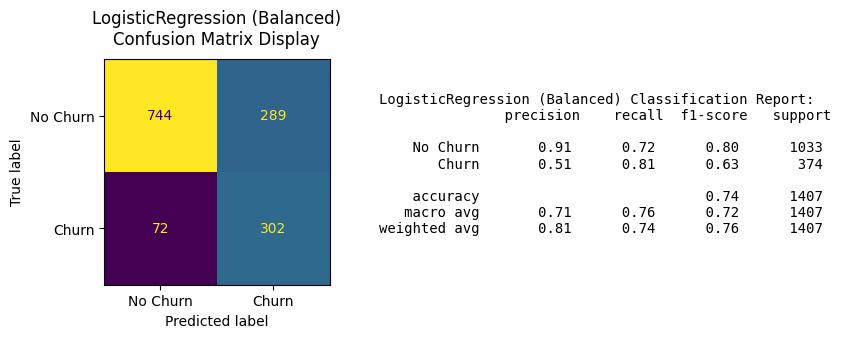

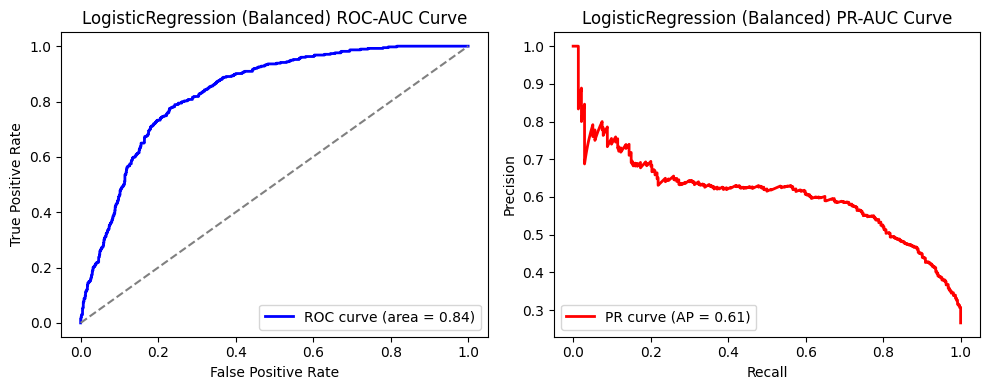

In [103]:
# Collect metrics
lr_bal_metrics = get_metrics(lr_bal, "Balanced", 
                             X_val_scaled, y_val)

# Display ROC PR curves, matrix and report
lr_bal_eval = display_evaluation(
    lr_bal, "Balanced", X_train_scaled, y_train, 
    X_val_scaled, y_val, learning_curve=False
)

Significant improvements were observed in recall, for which the score increased from 0.51 to 0.81, demonstrating that the model became significantly more effective at capturing at-risk customers. 

However, this came at the cost of a reduction in precision, which fell from 0.63 to 0.51. This trade-off suggests that while the model was able to correct more positive instances of churn, it done so with a higher rate of false positives. This is shown in the confusion matrix, which shows more than double the number of false positives, although the number of false negatives has also dropped by more than half thanks to the increase in recall.

The F1 score increased from 0.56 to 0.63, primarily driven as a result of the increase in recall, and the accuracy decreased from 0.79 to 0.74, though this remains a less important metric overall due to the inherent imbalance in the dataset. While an ROC-AUC score of 0.84 is good, it's reliability is limited by the imbalance in the dataset. On the other hand, the PR-AUC score of 0.61 indicates a moderately good ability to balance precision and recall, although there remains room for improvement.

#### K-Nearest Neighbours

Since K-Nearest Neighbours does not have built-in class-weight parameters, the model was re-fitted using the resampled SMOTE training data, and subsequently evaluated on the validation set.

In [104]:
# Set up balanced KNN model
knn_bal = KNeighborsClassifier()
knn_bal.fit(X_resampled_scaled, y_resampled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


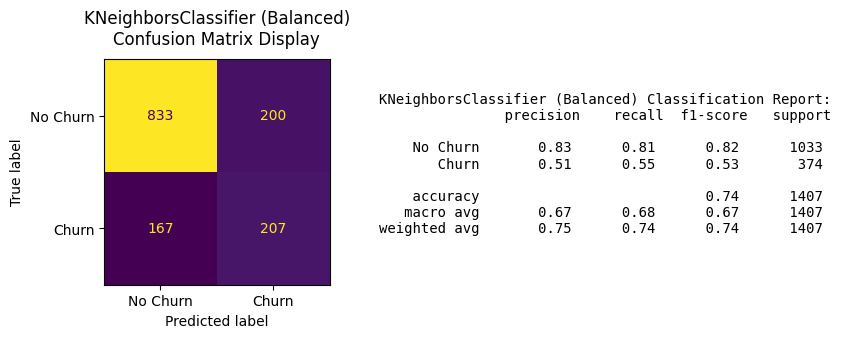

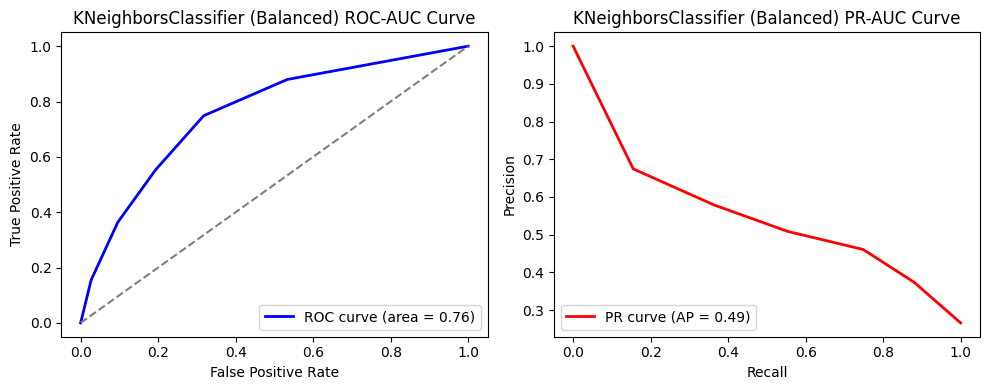

In [105]:
# Collect metrics
knn_bal_metrics = get_metrics(knn_bal, "Balanced",
                              X_val_scaled_SMOTE, y_val)
# Display ROC PR curves, matrix and report
knn_bal_eval = display_evaluation(
    knn_bal, "Balanced", X_resampled_scaled, y_resampled, 
    X_val_scaled_SMOTE, y_val, learning_curve=False
)

Compared to Logistic Regression, KNN saw onlu a marginal improvement in performance. Recall increased by around 5 points, from 0.50 to 0.55, whereas precision fell slightly from 0.54 to 0.51. The F1 score increased by 2 points from 0.53 to 0.55.

Overall, the performance of KNN remains underwhelming, and the improvements are far from significant even after resampling. This suggests that more extensive hyperparameter tuning may be needed to see any significant changes in performance, which is explored later in the model optimisation section. The PR-AUC score saw a slight bump from 0.48 to 0.49, but this still reflects poor performance in balancing precision and recall overall.

As it stands, KNN has not shown great results, but further optimisation may still hold some potential for improvement.

#### Support Vector Machines

The Support Vector Machines model was re-fitted `class_weights` set to 'balanced', and then evaluated on the validation set.

In [106]:
# Set up balanced SVM model (set probability to True)
svm_bal = SVC(probability=True, 
              class_weight="balanced",
              random_state=1066)
svm_bal.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1066
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


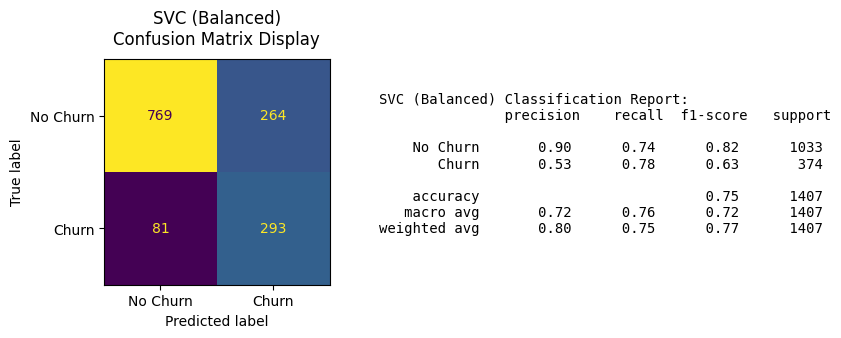

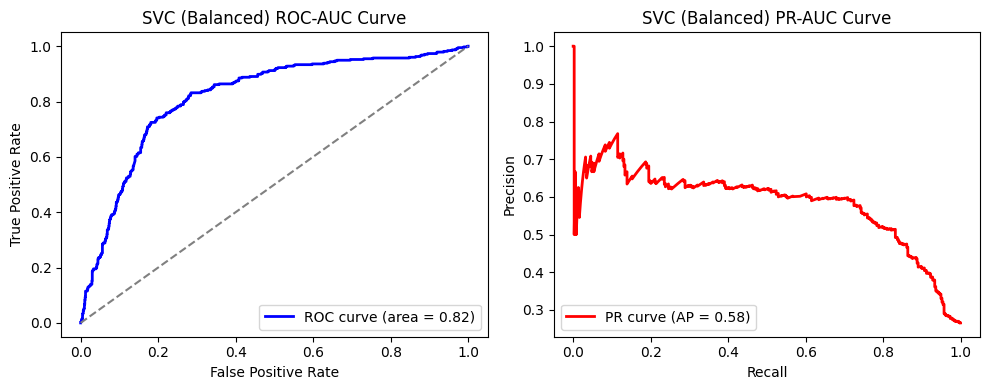

In [107]:
# Collect metrics
svm_bal_metrics = get_metrics(svm_bal, "Balanced", 
                             X_val_scaled, y_val)

# Display ROC PR curves, matrix and report
svm_bal_eval = display_evaluation(
    svm_bal, "Balanced", X_train_scaled, y_train, 
    X_val_scaled, y_val, learning_curve=False
)

Following class balancing, SVM demonstrated a remarkable improvement in performance. Notably, its recall increased from 0.44 in the base model to 0.78, a dramatic enhancement in its ability to identify churners. While precision dropped 10 points from 0.63 to 0.53, this trade-off was expected, since capturing the minority class in an imbalanced dataset often comes at the expense of precision. The F1 score also saw a substantial increase, from 0.51 to 0.63, further demonstrating an overall improvement in performance. 

The confusion matrix clearly reflects these gains, with 293 true positives and only 81 false negatives. This differs significantly compared to the base model, which had 211 true positives and 163 false negatives. It's important to note, however, the significant increase in false positives from 96 in the base model to 264, though this is balanced by the reduction in false negatives and a greater number of true positives. Despite the increase in false positives, the precision remains above the 0.5-threshold (50%) set for all models, making the trade-off acceptable in this context. 

The PR-AUC score of 0.58, while not as strong as that of Logistic Regression, is still higher than KNN, although this finding remains tentative due to the aforementioned limitations of relying on probability for interpreting SVM models.

Overall, SVM has shown promising improvement post-balancing, and further grid search optimisation could further amplify these results.

#### Random Forests

The *Random Forests* model was re-fitted with `class_weights` set to *'balanced'*, and subsequently evaluated on the validation data.

In [108]:
# Set up balanced Random Forests model
rf_bal = RandomForestClassifier(random_state=1066, 
                                class_weight="balanced")
rf_bal.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1066
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 

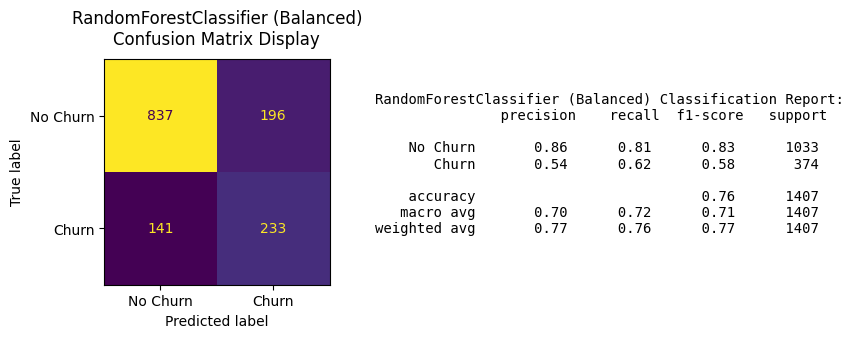

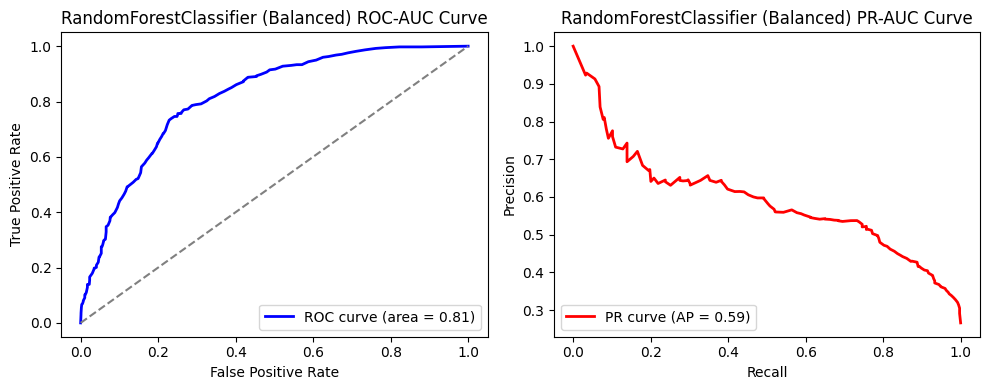

In [109]:
# Collect metrics
rf_bal_metrics = get_metrics(rf_bal, "Balanced", 
                             X_val, y_val)

# Display ROC PR curves, matrix and report
rf_bal_eval = display_evaluation(
    rf_bal, "Balanced", X_train, y_train, 
    X_val, y_val, learning_curve=False
)

The performance of the Random Forest classifier following class balancing was highly dissapointing, with minimal improvement compared to the base model. The recall remained stagnant at 0.45, and precision saw only a one-point increase from 0.60 to 0.61. This lack of improvement in recall is concerning, as it indicates that the model continues to struggle in identifying churners effectively. The F1 score remained at 0.51 further confirming the model's overall poor performance.

The confusion matrix reflects these results, with 167 true positives and 207 false negatives, barely differing from the base model's 168 true positives and 206 false negatives. Though the number of false negatives dropped slightly from 112 to 109, this is negligible with respect to the model's performance. Interestingly, the PR-AUC score of 0.58 aligns closely with that of SVM, although Random Forests underperformed in nearly every other aspect.

In summary, Random Forests failed to demonstrate any significant advancement in this phase of testing. Grid search optimisation will be crucial to salvage this models performance, as the current results fall far short of expectations. Given that Random Forests is an ensemble method, which typically exceps in handling more complex datasets, there is good reason to believe that tuning its hyperparameters will reveal its potential. At this point, however, it's clear that more refinement is needed to deliver the kind of results expected from such a model.

#### Gradient Boosting

Gradient Boosting was re-fitted using the resampled SMOTE data rather than class weights, as the model does not support them.

In [110]:
# Set up balanced Gradient Boosting Model
gb_bal = GradientBoostingClassifier(random_state=1066)
gb_bal.fit(X_resampled, y_resampled)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1066
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (

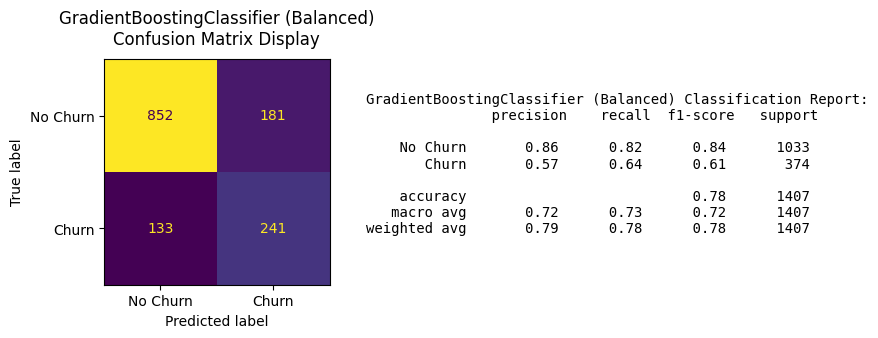

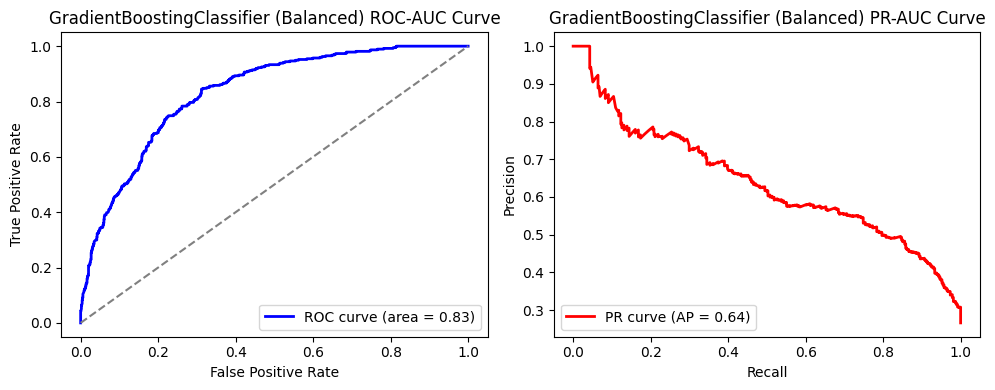

In [111]:
# Collect metrics
gb_bal_metrics = get_metrics(gb_bal, "Balanced", 
                             X_val, y_val)

# Display ROC PR curves, matrix and report
gb_bal_eval = display_evaluation(
    gb_bal, "Balanced", X_resampled, y_resampled, 
    X_val, y_val, learning_curve=False
)

Upon evaluation on the validation set, several key metrics stood out. Precision dropped from 0.63 to 0.57, reflecting a slight reduction in the accuracy of identifying churners, but this was not unexpected, as similar observations were made for the other models. Recall saw a substantial increase from 0.47 to 0.65, marking a relatively significant improvement in the model's ability to correctly identify churners. The F1 score rose from 0.51 to 0.54, a modest improvement. The PR-AUC score remained at 0.64, highlighting the model's strength at managing the precision-recall trade-off.

The confusion matrix further confirms these observations, with 244 true positives, 184 false positives, and 130 false negatives. This shows a clear improvement over the base model, which had 177 true positives, 102 false positives, and 197 false negatives.

Compared to Random Forests, Gradient Boosting performed markedly better overall, especially in recall. While it still falls short so far in some areas compared to Logistic Regression and SVM, Gradient Boosting scored higher precision than both, thus demonstrating fairly robust performance in this phase of testing.

#### Adaptive Boosting

Finally, the AdaBoost model was re-fitted using the resampled SMOTE training data, to compensate for its lack of a class balancing parameter.

In [112]:
# Set up balanced AdaBoost Model
ada_bal = AdaBoostClassifier(random_state=1066)
ada_bal.fit(X_resampled, y_resampled)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1066
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.26,0.36,0.34,...,0.47,0.46,0.48]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[1.07,0.59,0.66,...,0.11,0.15,0.09]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1533379431), DecisionTreeC...te=2100181945), DecisionTreeC...ate=286282891), DecisionTreeC...ate=422344531), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](21,)","[0.11,0.2 ,0.21,...,0.06,0.02,0.07]"


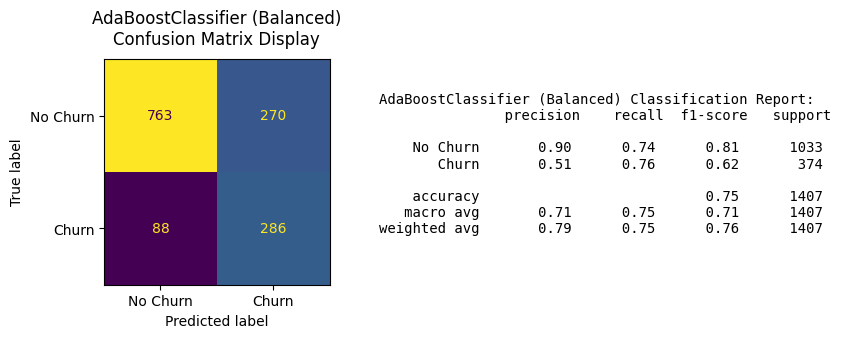

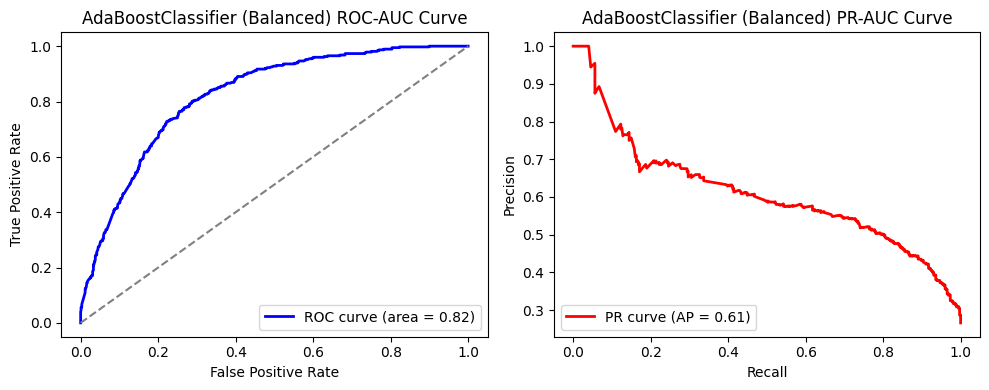

In [113]:
# Collect metrics
ada_bal_metrics = get_metrics(ada_bal, "Balanced", 
                             X_val, y_val)

# Display ROC PR curves, matrix and report
ada_bal_eval = display_evaluation(
    ada_bal, "Balanced", X_resampled, y_resampled, 
    X_val, y_val, learning_curve=False
)

Several key performance metrics were observed, showcasing significant improvements in this model's iteration. The recall jumped dramatically from 0.48 in the base model to 0.76, which is an impressive increase and highlights AdaBoost's ability to correctly predict more churners with the resampled data. Precision did fall from 0.64 to 0.51, which, as with other models, was expected, but still acceptable for the context of this project. The F1 score increased from 0.55 to 0.62, largely driven by the increase in recall. The PR-AUC score remained at 0.61, with strong recall and a respectable level of precision.

The confusion matrix supports these results, and shows us that AdaBoost identified 286 true positives and only 88 false negatives, a significant improvement from the base model's 180 true positives and 194 false negatives. However, the increase in recall came at the cost of a higher number of false positives, rising from 101 to 270. Despite this trade-off, the model's recall is now significantly stronger, and its overall performance has improved significantly.

The balanced AdaBoost model demonstrated very good performance compared to its base counterpart, making it one of the more promising models overall.

#### Results and Observations

The table below provides a summary of key performance metrics for both the *Churn* and *No Churn* classes across the balanced models. As done previously, a bar chart was also visualised to compare the models based on precision, recall and F1 score for the *Churn* class, but now also including Average Precision (PR-AUC).

In [114]:
# Define list of balanced model metrics
bal_metrics = [
    lr_bal_metrics,
    knn_bal_metrics,
    svm_bal_metrics,
    rf_bal_metrics,
    gb_bal_metrics,
    ada_bal_metrics
]

# Create DataFrame
df_bal_metrics = pd.DataFrame(bal_metrics)
df_bal_metrics

,Model,Model Configuration,Accuracy Score,Precision (Churn),Recall (Churn),F1 Score (Churn),Precision (No Churn),Recall (No Churn),F1 Score (No Churn),Churn ROC-AUC Score,Churn PR-AUC (AP) Score
0,LogisticRegression,Balanced,0.743426,0.510998,0.807487,0.625907,0.911765,0.720232,0.804759,0.835360,0.607066
1,KNeighborsClassifier,Balanced,0.739161,0.508600,0.553476,0.530090,0.833000,0.806389,0.819479,0.759728,0.492692
2,SVC,Balanced,0.754797,0.526032,0.783422,0.629431,0.904706,0.744434,0.816782,0.816449,0.584617
3,RandomForestClassifier,Balanced,0.760483,0.543124,0.622995,0.580324,0.855828,0.810261,0.832422,0.813300,0.588964
4,GradientBoostingClassifier,Balanced,0.776830,0.571090,0.644385,0.605528,0.864975,0.824782,0.844400,0.832538,0.638194
5,AdaBoostClassifier,Balanced,0.745558,0.514388,0.764706,0.615054,0.896592,0.738625,0.809979,0.821576,0.606667


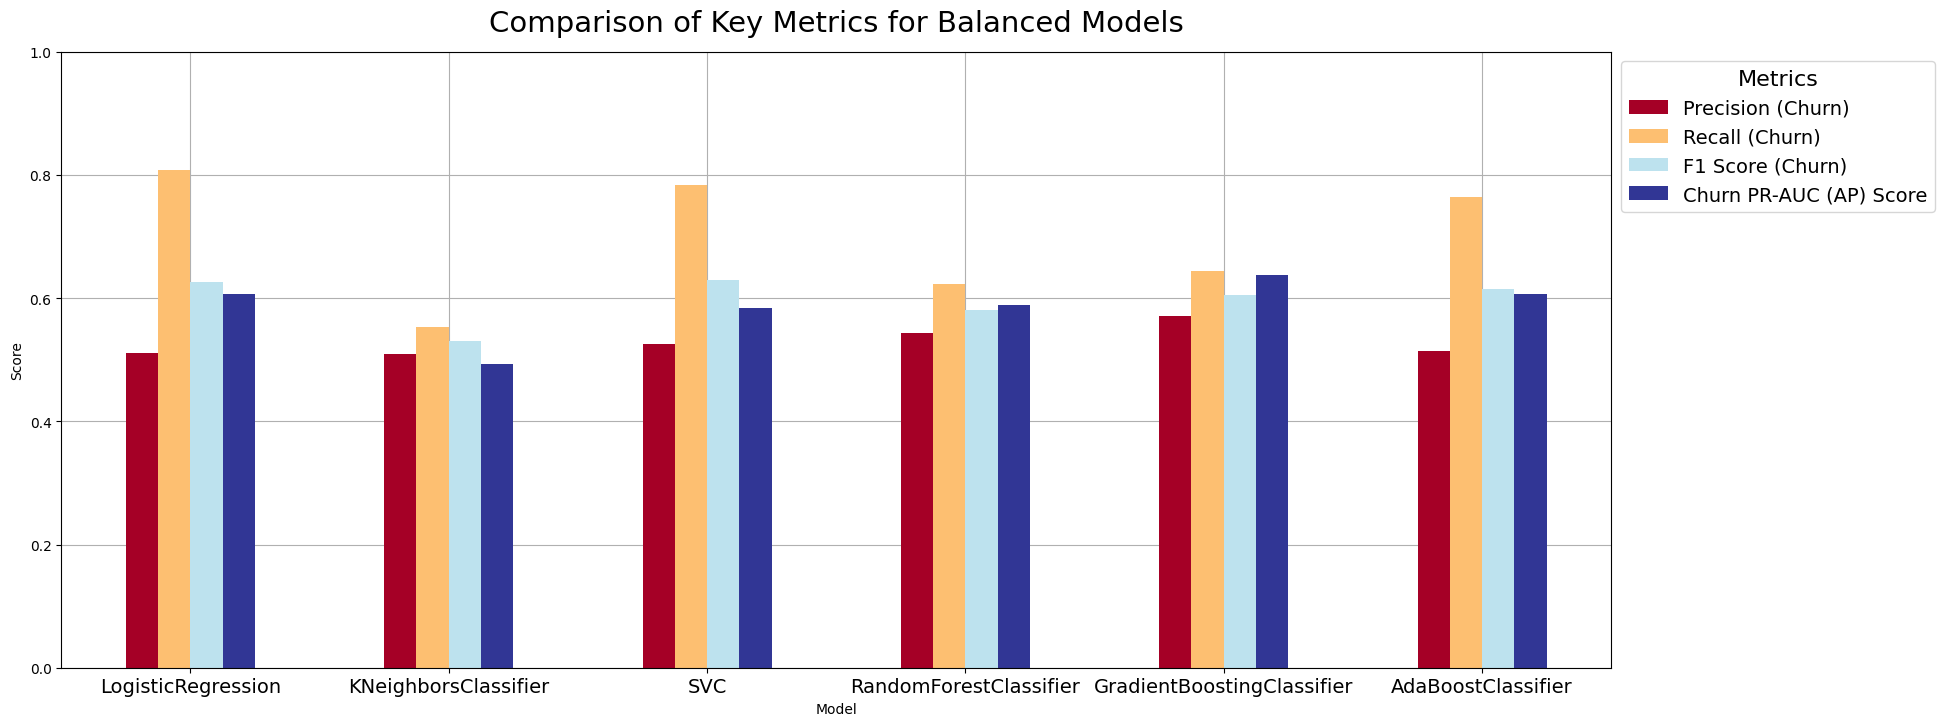

In [115]:
# Define metrics to visualise
metrics = (
    list(df_bal_metrics.columns[3:6])
    + list(df_bal_metrics.columns[10:])
)

# Plot metrics
df_bal_metrics.plot(
    x="Model", 
    y=metrics, 
    kind="bar", 
    grid=True, 
    zorder=2, 
    figsize=(20, 8), 
    cmap="RdYlBu"
)

# Set title and labels
plt.title(
    "Comparison of Key Metrics for Balanced Models",
    y=1.02, fontsize=21
)
plt.ylabel("Score")
plt.xlabel("Model")
# Set xticks
plt.xticks(fontsize=14, rotation=0)
# Set ylim
plt.ylim(0, 1)

# Set legend and layout
plt.legend(title="Metrics", bbox_to_anchor=(1,1),
           fontsize=14, title_fontsize=16)
plt.tight_layout;

After inspecting the performance metrics and visualisation, several notable observations were made.

While Random Forests was dissapointing in most metrics, it had the highest precision of all the balanced models at 0.61, though this was barely an improvement over its base model. Gradient Boosting followed closely at 0.57, which performed much better overall in comparison. AdaBoost, Logistic Regression and KNN all had similar precision scores at around 0.51. It's worth noting again that, within the context of this project, precision scores above 0.5 were considered to be acceptable, hence all of the models satisfy this requirement.

When it comes to recall, Logistic Regression was the standout performer here, achieving the highest score at 0.81. This model proved the most effective at identifying churners, which is crucial for customer retention strategies. SVM came second with a score of 0.78, followed closely by AdaBoost at 0.76. In stark contrast, Random Forests had the lowest recall of 0.45, followed by KNN at 0.55; both models missed a significant number of churners, significantly impacting their prediction potential.

SVM and Logistic Regression had nearly identical F1 scores, corresponding to 0.629 and 0.626, respectively. AdaBoost also performed well here with an F1 score of 0.615, closely followed by Gradient Boosting with 0.608. Meanwhile, Random Forests and KNN trailed with F1 scores of 0.51 and 0.53, respectively, emphasising their overall poorer performance.

The Average Precision (PR-AUC) score is particularly valuable in the case of an imbalanced dataset like this one, as it focuses on the trade-off between precision and recall for the minority class, that is, *Churn*. Gradient Boosting scored the highest PR-AUC score at 0.64, demonstrating its ability to manage this trade-off effectively compared to the other models. Logistic Regression and AdaBoost performed similarly, with each scoring 0.61. SVM had a respectable Average Precision score of 0.58, although not on par with the other models and should be interpreted with caution given the underlying probability limitations. Random Forests, while similarly scoring 0.58 in PR-AUC, was overshadowed by its poor recall and F1 score. KNN was the worst performer in this metric, with a score of 0.49.

To conclude this section, the best performers so far have been Logistic Regression, SVM, and AdaBoost. These models excelled across multiple metrics, with Logistic Regression performing admirably, especially in recall and overall balance. SVM impressed with its F1 score, while AdaBoost demonstrated consistently strong results all across the board. Conversely, Random Forests and KNN were the worst performers. Random Forests, despite being an ensemble method, underperformed significantly, especially in recall. KNN similarly struggled, with generaly poor performance all around, and failed to show significant improvement compared with its base counterpart. However, there is still potential for improvement, and grid search optimisation will be essential in trying to salvage both Random Forest and KNN. Both models still show promise, but significant parameter tuning will be necessary to see meaningful improvements.

### Grid Search Optimisation

Following the evaluation of base and class-balanced models, the performance characteristics of each model without any adjustment of hyperparameters have become clear. The results suggest that model performance generally improved with class balancing techniques applied, as opposed to 'out-of-the-box' configurations.

The rest of the section now focuseses on optimising hyperparameters to enhance model performance further. As previously established, the key metrics of interest are those relating specifically to the *Churn* class, which will be prioritised in this section unless stated otherwise.

As stated at the beginning of the *Model Optimisation and Hyperparameter Tuning* section, model tuning was geared towards increasing recall while maintaining a minimum precision threshold of 0.5. The Average Precision (AP) score has been used as a benchmark for acceptable performance, with a target of 0.6 as a minimum and values exceeding 0.7 considered highly desirable. Aditionally, the project aimed for F1 score of at least 0.6; however, a higher AP score is preferable in this context.

Hyperparameter tuning was conducted using Grid Search with Cross-Valudation, that is, `GridSearchCV()`, a method that evaluates each possible parameter combination within a specified range outlined in a parameter grid. 5-Fold Cross-Validation was employed to ensure reliable model assessment, providing multiple validation sets to assess performance during model training. This number of folds was chosen to balance computational efficiency and the benefits of robust cross-validation. Additionally, the `n_jobs` parameter was set to -1 to utilise all available CPU cores, thereby speeding up the search process. 

To align with the project's objective of maximising recall while maintaining a precision of at least 0.5, a custom scoring function `custom_score()` was defined and hence assigned to the variable `scorer` (see *Helper Functions* at the beginning of *Model Optimisation and Tuning*). This custom scorer enabled model selection with a stronger emphasis on recall, provided that the precision threshold was upheld. The `scoring` parameter in `GridSearchCV()` was set to this custom scorer to enforce these criteria consistently across all models. Furthermore, `verbose` was set to 2 to allow progress updates throughout the fitting process, which provided a clear view of the grid search stages and facilitated monitoring of its completion. As in the previous section, class balancing (or resampling, where appropriate) was also applied by default to each model.

To avoid potential preprocessing errors and data leakage, each grid search optimisation, along with subsequent optimised fitted models, were implemented within a `Pipeline()` object. This ensured that all necessary preprocessing steps, such as scaling and resampling, were applied consistently and in the correct sequence throughout the training process.

Due to the wide range of parameters available for some models, particularly Random Forests and Gradient Boosting, some grid searches required substantial computational time, in some cases taking several hours or longer. Where grid search results did not meet expectations, additional subsequent manual adjustments were explored to assess alternative configurations and their impact on model performance.

In addition to the ROC-PR curves, confusion matrices, and classification reports generated previously, learning curves were produced for each model in this section to assess model generalisation and investigate potential issues of underfitting or overfitting.

As in prior sections, the `random_state` parameter was set to 1066 where applicable. Finally, note again that the interpretation of probability-based metrics (ROC-AUC and PR-AUC) for Support Vector Machines (SVM) requires caution, as these metrics were generated using the `predict_proba` method which SVM does not inherently support.

#### Logistic Regression

***2026 note:** The `penalty` parameter included in the original Logistic Regression grid search has since been deprecated in scikit-learn and has therefore been commented out in the updated notebook. This change did not affect the reported model performance metrics.*

Starting with Logistic Regression, an instance of the model was created with default parameters, `class_weight` set to 'balanced'. The `max_iter` parameter was set to 2000; this was done to address convergence issues encountered in prior grid searches, ensuring the model has enough iterations to reach an optimal solution.

A `Pipeline()` object was then defined to streamline preprocessing, including scaling, and to ensure consistent application of these steps throughout the training process.

In [116]:
# Set up instance of model
lr_instance = LogisticRegression(
    max_iter=2000, 
    class_weight="balanced",
    random_state=1066,
)

# Set up LogReg Pipeline
lr_grid_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", lr_instance),
])

Next, several lists of key hyperparameters were defined for tuning, including the following:
- **solver**: The *saga*, *lbfgs*, and *liblinear* solvers were included to explore a range of optimisation algorithms.
- **penalty**: The *L1*, *L2*, and *ElasticNet* penalties were tested, with *ElasticNet* providing flexible regularisation by combining different ratios of L1 to L2.
- **l1_ratio**: Applicable only to *ElasticNet* models, this parameter determines the combination of L1 and L2. A range of values from 0.01 to 0.99 were chosen.
- **C**: The inverse of regularisation strength, where lower values correspond to stronger regularisation. A range of C values from 0.001 to 5 were tested to refine regularisation.

These parameters were organised into a parameter grid, defining the search space for grid search.

In [117]:
# Define parameter lists
solver = ["saga", "lbfgs", "liblinear"]
# penalty = ["l1", "l2", "elasticnet"]
l1_ratio = [0.01, 0.05, 0.1, 0.3, 
            0.5, 0.7, 0.9, 0.95, 0.99]
C = [0.001, 0.01, 0.1, 0.5, 
     0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5]

# Define parameter grid
lr_params = {
    "lr__solver": solver,
#    "lr__penalty": penalty,
    "lr__l1_ratio": l1_ratio,
    "lr__C": C,
}

A `GridSearchCV()` object was then defined, using the parameter grid specified above to exhaustively test all combinations of parameters, as well as all the GridSearchCV-specific parameters discussed at the beginning of this subsection.

In [118]:
# Define grid search
lr_grid = GridSearchCV(
    estimator=lr_grid_pipe, 
    param_grid=lr_params,  
    cv=5,
    scoring=scorer,
    verbose=2,
    n_jobs=-1
)

In [119]:
# Fit grid
#lr_grid.fit(X_train, y_train)

In [120]:
# Look at best parameters found
#lr_grid.best_params_

The final grid search identified solver liblinear, penalty L1, and C-value 0.7 as the optimal parameter configuration based on the specified performance criteria *(the L1 ratio parameter is redundant in this case since elastic net was not selected)*. 

However, although this configuration was chosen by the grid search, further experimentation with various parameter combinations consistently resulted in identical performance metrics across alternative configurations, and would only change if the C value was adjusted to a value other than 0.7.

Upon further exploration of alternative configurations, the saga solver and elastic net regularisation (with L1 ratio = 0.3) were applied to the model, while keeping the C value at 0.7; this unsurprisingly resulted in identical performance to the grid-search selected parameters. This consistent performance across configurations, each maintaining a C value of 0.7, highlights the importance of the regularisation parameter's impact on optimising recall and precision balance. These findings suggest that Logistic Regression's capacity on this dataset is likely maxed out, with additional parameter adjustments unlikely to yield further gains.

For consistency, the final optimised model configuration was chosen as saga with elastic net (L1 ratio = 0.3) and C=0.7; this setup was chosen to ensure flexibility for future adaptation while preserving the identical performance metrics. The saga solver is well-suited for larger datasets, allowing the model to scale as needed, and elastic net regularisation, particularly with an L1 ratio of 3, balances the sparsity benefits of L1 with the stability of L2. The model was subsequently re-trained with the adjusted parameters, and then evaluated on the validation set.

In [121]:
# Create instance of optimised model
lr_opt_instance = LogisticRegression(
    C=0.7,
    l1_ratio=0.3,
#    penalty="elasticnet", 
    solver="saga", 
    random_state=1066, 
    class_weight="balanced", 
    max_iter=2000
)

# Set up pipeline with optimised model
lr_opt = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lr", lr_opt_instance)
])

In [122]:
# Fit model
lr_opt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['tenure','ContractLength','MonthlyCharges',..., 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Electronic check','PaymentMethod_Mailed check']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [123]:
# Collect metrics
lr_opt_metrics = get_metrics(lr_opt, "Optimised", 
                             X_val, y_val)

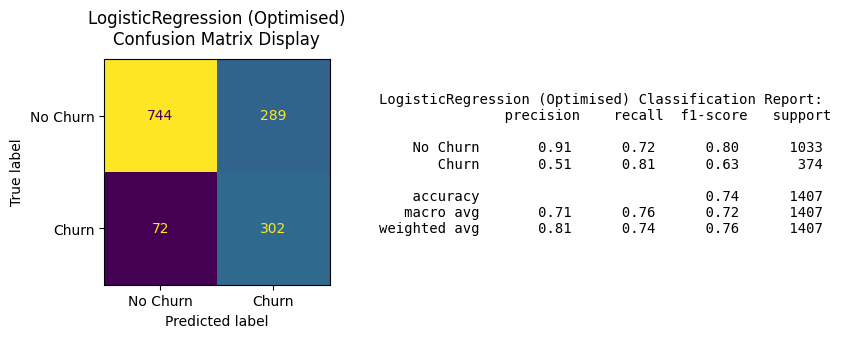

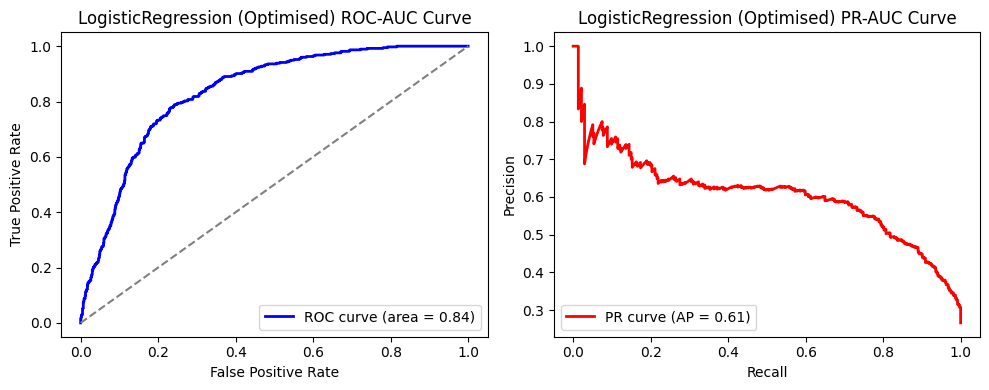

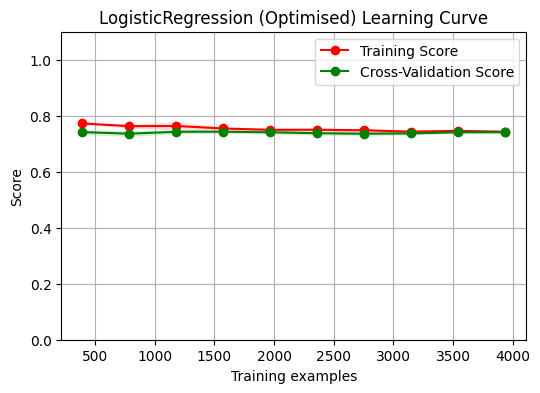

In [124]:
# Display curves, matrix and report
lr_opt_eval = display_evaluation(
    lr_opt, "Optimised", X_train, y_train, X_val, y_val
)

The optimised Logistic Regression model, despite exploring a range of configurations, ultimately produced results that were not only identical to each other, but identical even to the balanced model trained earlier, which used only default settings in addition to `class_weights` set to 'balanced'.

All performance metrics remained consistent, reinforcing the notion that Logistic Regression likely reached its performance ceiling on this dataset. The classification report, confusion matrix, and ROC-PR curves, whether optimised or default balanced, achieved virtually the same balance between precision and recall. Furthermore, the learning curve illustrates a close alignment between training and cross-validation scores, both stabilising around 0.75. This suggests a well-fitting model with minimal variance, which implies that additional tuning is unlikely to yield further performance gains, as the model consistently maximises recall with the set precision threshold.

#### K-Nearest Neighbours

Moving on to KNN, a `Pipeline()` object was created, with SMOTE, scaling, and a base KNN model included within the steps.

In [125]:
# Set up KNN Pipeline
knn_grid_pipe = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=1066)),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

The following key hyperparameters were defined for tuning and stored within a parameter grid:
- **n_neighbors**: This represents the $k$ number of neighbours in K-Nearest Neighbours; a range of values from 10 to 70 were chosen to establish the optimum quantity.
- **weights**: *Uniform* and *distance* were compared to investigate whether equally-weighted points or distance-weighted points perform better.
- **algorithm**: The method used to find the nearest neighbours; *ball tree*, *KDE tree*, or *brute force* approaches are explored.
- **p**: The *power* parameter $p$; this is applicable when `metric` is set to default 'minkowski', which is used for computing the distance. The *Manhattan distance* (L1) and *Euclidian distance* (L2) are compared, representing values $p=1$ and $p=2$, respectively.
- **leaf_size**: Mainly controls the search speed for nearest neighbours; a range of leaf sizes were explored.

In [126]:
# Define variables for parameter grid
n_neighbors = [10, 20, 30, 40, 45, 50, 55, 60, 65, 70]
weights = ["uniform", "distance"]
algorithm = ["ball_tree", "kd_tree", "brute"]
p = [1, 2]
leaf_size = [5, 10, 12, 13, 14, 15, 17, 20, 25, 30]

# Define parameter grid
knn_params = {
    "knn__n_neighbors": n_neighbors,
    "knn__weights": weights,
    "knn__algorithm": algorithm,
    "knn__p": p,
    "knn__leaf_size": leaf_size
}

The `GridSearchCV()` model was then defined and thus fitted with all relevant parameters.

In [127]:
# Define grid search
knn_grid = GridSearchCV(
    knn_grid_pipe, 
    knn_params,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [128]:
# Fit grid
#knn_grid.fit(X_train, y_train)

In [129]:
# Inspect best parameters
#knn_grid.best_params_

The best parameters identified by the grid search were the ball tree algorithm, leaf size 5, $k=40$ neighbours, $p=1$, and uniform weights.

An instance of this optimised model was created and fitted within `pipeline()`, including scaling and resampling of the data. The resulting fit was then evaluated on the validation set.

In [130]:
# Create instance of optimised model 
knn_opt_instance = KNeighborsClassifier(
    n_neighbors=40,
    algorithm="ball_tree",
    leaf_size=5,
    p=1
)

# Set up pipeline with optimised model
knn_opt = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=1066)),
    ("scaler", StandardScaler()),
    ("knn", knn_opt_instance)
])

In [131]:
# Fit optimised KNN
knn_opt.fit(X_train, y_train)

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](21,)","['tenure','ContractLength','MonthlyCharges',..., 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Electronic check','PaymentMethod_Mailed check']"
n_features_in_,int,21
,random_state,1066
,sampling_strategy,'auto'
,k_neighbors,5


In [132]:
# Collect metrics
knn_opt_metrics = get_metrics(knn_opt, "Optimised", 
                              X_val, y_val)

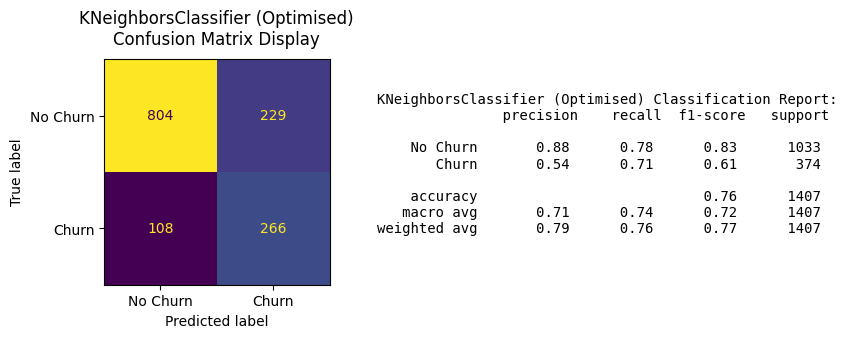

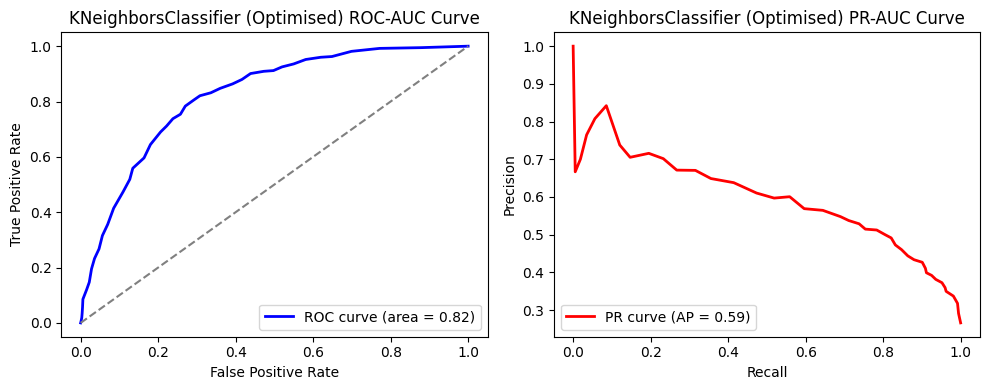

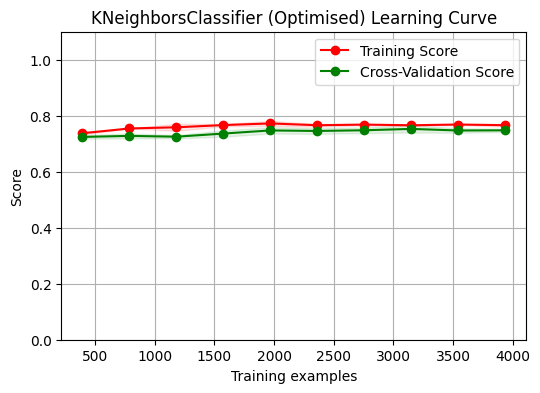

In [133]:
# Display curves, matrix and report
knn_opt_eval = display_evaluation(
    knn_opt, "Optimised", X_train, y_train, X_val, y_val
)

The optimised KNN model demonstrated significant improvements in  performance compared to its previous iterations. The based and balanced models both performed poorly, particularly in terms of recall and average precision, with the balanced model seeing only a marginal performance boost compared to its standard baseline metrics. However, after having its parameters tuned through grid search, KNN has shown a marked improvement in performance.

The model achieved a precision of 0.54, matching the precision seen in the base KNN and slightly above the balanced KNN, while recall has grown 16 points to a score of 0.71. As expected, the F1 score has also increased to a score of 0.61. Additionally, the AP score has risen from 0.49 to 0.59, almost on par with Logistic Regression, which shows an improvement in the model's ability to correctly identify and balance between true and false positives.

The confusion matrix shows 266 positives, 229 false positives, and 108 false negatives. The number of false negatives has dropped markedly, while the number of both true and false positives has gone up, though true positives have seen a bigger increase overall. These results are consistent with the increase in recall, and an overall indicator of the model's improved capability to capture more positive classes compared to its previous iterations.

On the contrary, a slight decrease in the recall of the negative class was observed, together with a corresponding increase in precision. These minor changes are an expected trade-off, as the model has attempted to compensate for the overall class imbalance, and is thus not a significant concern in this case.

The learning curve shows training and cross-validation scores that are closely aligned, hovering somewhere around 0.77 and 0.75, respectively. Only a minimal degree of underfitting was observed, as indicated by the slightly higher training score compared to cross-validation, though this difference is small and unlikely to significantly impact performance. Hence the model appears to be generalising well to the data.

Comparing KNN to Logistic Regression, the latter still outperforms KNN across all metrics, with the exception of precision by a few points. However, while Logistic Regression displayed limited sensitivity to grid search tuning, KNN's response was significant, underscoring KNN's higher potential for improvement through hyperparameter tuning.

Overall, KNN's performance has benefitted significantly from the grid search optimisation process, though it still lags behind Logistic Regression in its overall performance.

#### Support Vector Machines

Now, a SVM model instance was created with default parameters and `class_weight` set to 'balanced', with `probability` was set to 'True'. 

A `Pipeline()` object, with scaling and the model included, has been defined below.

In [134]:
# Define SVM instance
svm_instance = SVC(
    probability=True, 
    class_weight="balanced", 
    random_state=1066
)

# Set up SVM Pipeline
svm_grid_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()), 
    ("svm", svm_instance)
])

The following hyperparameters were explored and stored in a corresponding parameter grid:
- **kernel**: Defines how the model transforms data to find the optimal boundary. *Linear* and *RBF* kernels were tested (*polynomial* was tested in a previous search, but was computationally expensive and yielded no significant difference in results).
- **C**: The regularisation parameter (similar to the C parameter in Logistic Regression); controls the trade-off between minimising error on the training data and maximising the decision boundary (margin) for better generalisation to the data. A range of values from 0.001 to 20 were explored; lower values allows for a wider margin and error, potentially helping to reduce overfitting, whereas higher values prioritise minimising error by fitting closer to the training data, though this may lead to overfitting in some cases. 
- **gamma**: Controls the influence of individual training points; lower values decrease the influence of individual points (can help to reduce overfitting), whereas higher values increase their influence (may increase risk of overfitting). It works in tandem with C to balance model complexity. A range of values from 0.001 to 20 were explored, along with the default *scale* setting, and the *auto* setting.

In [135]:
# Set up variables for param grid
kernel = ["linear", "rbf"] 
C = [0.001, 0.01, 0.1, 1, 10, 20] 
gamma = ["scale", "auto", 
         0.001, 0.01, 0.1, 1, 10, 20] 

# Set up param grid
svm_params = {
    "svm__kernel": kernel,
    "svm__C": C,
    "svm__gamma": gamma,
}

In [136]:
# Define grid search
svm_grid = GridSearchCV(
    svm_grid_pipe,
    svm_params,
    cv=5,
    scoring=scorer,
    verbose=2,
    n_jobs=-1
)

A `GridSearchCV()` was thus defined and fitted with the pipeline and parameter grid, along with any other relevant parameters.

In [137]:
# Fit grid
# svm_grid.fit(X_train, y_train)

In [138]:
# Get best params
# svm_grid.best_params_

The grid search identified the RBF kernel as the best performer, along with a C value of 10 and a gamma value of 0.01, suggesting higher regularisation to closely fit to the training data, while keeping the model's sensitivity to individual points in check. However, further experimentation with the C and gamma parameters identified another configuration with slightly higher recall while still satisfying the precision floor. As such, the values 1 and 0.001 for C and gamma were chosen, respectively, to be used in the optimised model.

A SVM model was subsequently defined and fitted, scaled within `Pipeline()`, and evaluated on the validation set.

In [139]:
# Define model instance
svm_opt_instance = SVC(
    C=1,
    kernel="rbf",
    gamma=0.001,
    probability=True, 
    class_weight="balanced", 
    random_state=1066
)

# Set up pipeline
svm_opt = Pipeline(steps=[
    ("scaler", StandardScaler()), 
    ("svm", svm_opt_instance)
])

In [140]:
# Fit optimised model
svm_opt.fit(X_train, y_train)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['tenure','ContractLength','MonthlyCharges',..., 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Electronic check','PaymentMethod_Mailed check']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [141]:
# Collect metrics
svm_opt_metrics = get_metrics(
    svm_opt, "Optimised", X_val, y_val
)

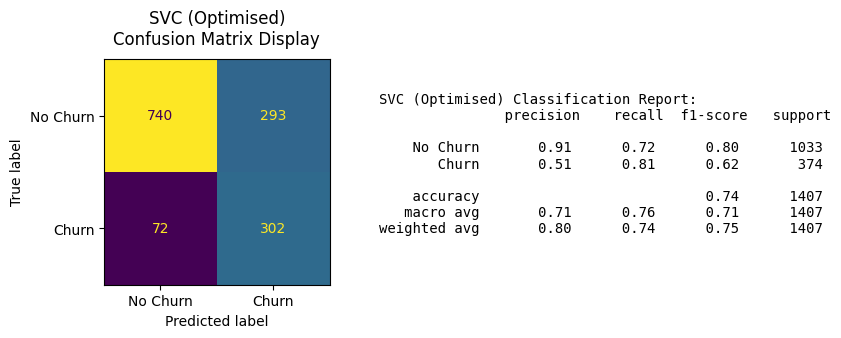

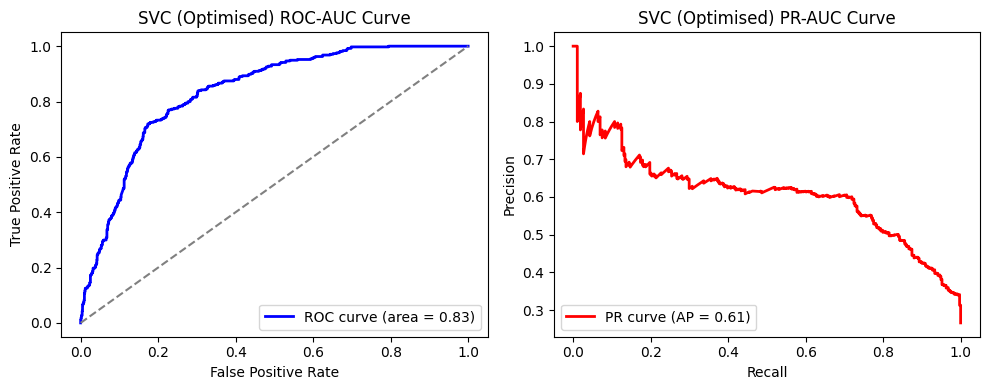

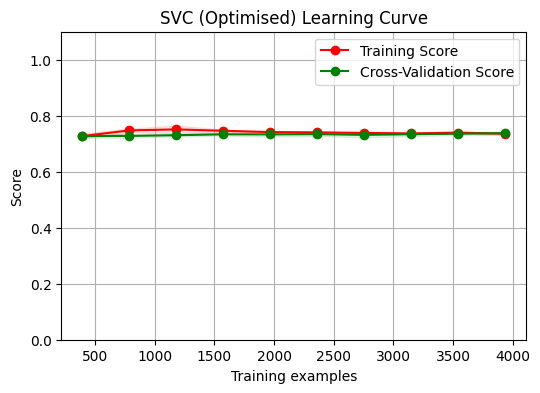

In [142]:
# Suppress future/deprecation warnings
import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    # Display curves, matrix and report
    svm_opt_eval = display_evaluation(
        svm_opt, "Optimised", X_train, y_train, X_val, y_val
    )

The optimised SVM model demonstrates a clear improvement in performance compared to both its baseline and balanced iterations. While the improvements after grid search optimisation are not drastic relative to the balanced model, they are nonetheless meaningful and contribute positively to the model's overall effectiveness. On the other hand, SVM has shown substantial improvement from its initial base model, which had a recall of only 0.44, through class balancing and optimisation. 

Precision dropped slightly to 0.51 compared to the balanced iteration, whereas recall increased slightly to 0.81. The F1 score decreased by a single point to 0.62, while the AP score rose by 3 points to 0.61. Despite the small decrease in precision, it sits just above 0.5, the minimum acceptable precision as defined at the beginning of *Model Optimisation and Hyperparameter Tuning*. The slight drop in F1 score is negligible, and the overall shift in metrics suggest that the optimised model has achieved a better balance, with fewer missed churn cases, while maintaining acceptable precision. 

The confusion matrix shows 302 true positives, 293 false positives, and 72 false negatives; though the number of false positives has somewhat increased, the corresponding reduction in false negatives compensates for this, which is a positive difference given the focus on recall for the positive class. The learning curve indicates that the data is fitting well, with training and cross-validation scores converging around 0.75, suggesting minimal variance and no indication of over- or under-fitting, and thus a well-generalised model. 

Overall, SVM has progressed from a relatively weak performer at its baseline to a model with performance comparable to that of Logistic Regression, with both models showing comparable metrics across precision, recall, and F1 score for both classes.

#### Random Forests

The next model to be optimised was Random Forest, the first of the *ensemble* methods. An initial instance of the model instance was created with default parameters and `class_weight` set to 'balanced'. To save computation time, some settings were retained as defaults based on findings from previous grid searches, where specific configurations consistently performed well. Specifically, `bootstrap=True` and `max_features="sqrt"` were retained, since these settings were frequently effective.

For consistency with the other models, Random Forest was also placed within a `Pipeline()` object, despite not requiring any additional preprocessing steps, to ensure a uniform workflow across all models and consistency in the project structure.

In [143]:
# Define RF instance for Pipeline
rf_instance = RandomForestClassifier(
    random_state=1066,
    class_weight="balanced"
)

# Set up Pipeline for RF
rf_grid_pipe = Pipeline(steps=[
    ("rf", rf_instance)
])

The following key hyperparameters were chosen to be investigated, which were then stored within a parameter grid:

- **n_estimators**: Defines the number of decision trees in the forest. More trees typically improves model performance, but at an increased computational cost, and often with diminishing returns after a certain point. A range from 50 to 300 trees were chosen for the grid search.
- **max_depth**: The maximum depth of each tree, which controls how many splits each tree can make. Deeper trees capture more information about the data, but may result in overfitting, whereas limiting depth can help to prevent overfitting by simplifying the model. A range of maximum depths, ranging from 5 to 20, were investigated.
- **min_samples_split**: The minimum number of samples required to split a node. Lower values mean the tree splits a node with fewer samples, which can lead to more complex trees that fit closer to the training data, whereas higher values result in simpler trees which can help the model generalise better to the training data. Values from 2 to 20 were chosen to be explored.
- **min_samples_leaf**: The minimum number of samples required to form a leaf node (the final node at the end of a tree), ensuring that every terminal node has at least this number of samples. Like `min_samples_split`, lower values increase the trees' complexity (more leaves, smaller in size), whereas larger values contribute to a simpler tree structure (fewer leaves, larger in size). Values *from 2 to 20* were explored.
- **criterion**: The function used to measure and select the quality of each split in the trees. Both *Gini impurity* and *entropy* were explored, as they use different metrics to evaluate splits.

In [144]:
# Set up variables for param grid
n_estimators = [50, 100, 150, 175, 
                200, 225, 250, 275, 300]
max_depth = [5, 7, 10, 13, 15, 17, 20]
min_samples_split = [2, 5, 7, 10, 15, 17, 20]
min_samples_leaf = [2, 3, 5, 7, 10, 13, 15, 17, 20]
criterion = ["gini", "entropy"]

# Set up param grid
rf_params = {
    "rf__n_estimators": n_estimators,
    "rf__max_depth": max_depth,
    "rf__min_samples_split": min_samples_split,
    "rf__min_samples_leaf": min_samples_leaf,
    "rf__criterion": criterion
}

An instance of `GridSearchCV()` was subsequently created and fitted with the given data, along with all the relevant parameters.

In [145]:
# Define grid search
rf_grid = GridSearchCV(
    rf_grid_pipe,
    rf_params,
    cv=5,
    scoring=scorer,
    verbose=2,
    n_jobs=-1
)

In [146]:
# Fit grid
#rf_grid.fit(X_train, y_train)

In [147]:
# Inspect best parameters
#rf_grid.best_params_

The grid search for the Random Forest model selected Gini as the best criterion, with a maximum depth of 5, at least 17 samples to form a leaf node, at least 2 samples to split a node, and 175 estimators as the optimum number of decision trees.

A new model instance was then created and fitted in a pipeline object (for consistency), and subsequently evaluated on the validation set. The `criterion="gini"` and `min_samples_split=2` parameters were left unchanged, since these settings are already set by default in the base model.

In addition, an *Out-of-Bag (OOB)* score, unique to Random Forest, was generated as an extra validation metric, which provides additional insight into the model's generalisation performance.

In [148]:
# Create optimised model instance
rf_opt_instance = RandomForestClassifier(
    n_estimators=175,
    max_depth=5,
    min_samples_leaf=17,
    random_state=1066,
    class_weight="balanced",
    oob_score=True
)

# Set up pipeline for rf instance (for consistency)
rf_opt = Pipeline(steps=[
    ("rf", rf_opt_instance)
])

In [149]:
# Fit optimised model
rf_opt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['tenure','ContractLength','MonthlyCharges',..., 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Electronic check','PaymentMethod_Mailed check']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",175
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",17


In [150]:
# Collect metrics
rf_opt_metrics = get_metrics(
    rf_opt, "Optimised", X_val, y_val
)

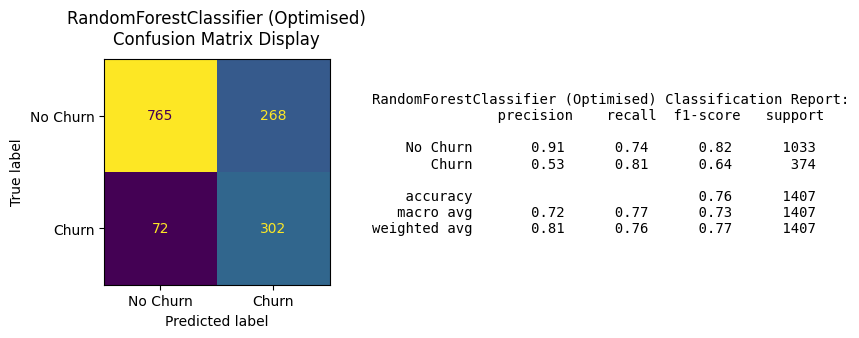

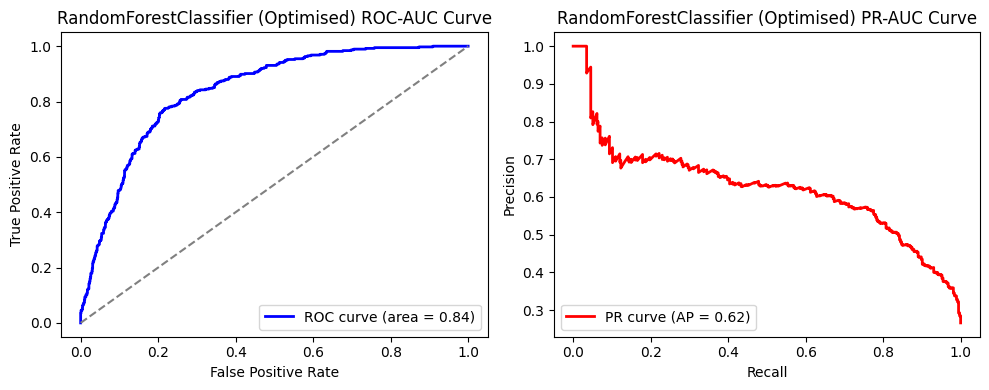

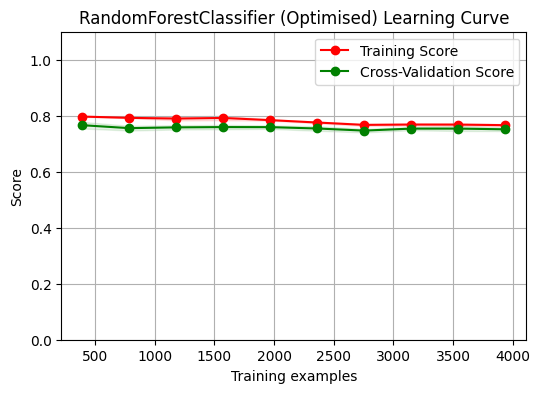

In [151]:
# Display curves, matrix and report
display_evaluation(
    rf_opt, "Optimised", X_train, y_train, X_val, y_val
)

In [152]:
# Display OOB score
rf_opt[-1].oob_score_

0.7576188541243397

Initially, Random Forest was among the weakest performers in both its baseline and balanced iterations with particularly poor recall, which remained low even after class balancing, and it struggled to keep up with the other machine learning algorithms in terms of overall predictive power. However, following grid search optimisation, the performance of Random Forest has shown a dramatic transformation.

While precision decreased by nearly 10 points, from 0.61 to 0.52, recall increased from 0.45 to 0.80, and hence the corresponding F1 score increased from 0.51 to 0.63. The AP score also increased to 0.62, now the highest among all optimised models, surpassing both Logistic Regression and SVM by one point.

The confusion matrix further highlights this improvement, with 301 true positives, 277 false positives, and 73 false negatives, comparable to Logistic Regression, with only a difference of 1 point in both false negatives and true positives, along with fewer false positives. In contrast, the previous balanced iteration of Random Forest had 167 true positives, 109 false positives, and 207 false negatives. This substantial reduction in false negatives, combined with nearly double the number of true positives, illustrates the model's newfound ability to identify cases of customer churn. 

The learning curve shows closely aligned training and cross-validation scores at around 0.77-0.78, indicating a well-generalised model. Additionally, the OOB score was found to be approximately 0.755, which is close to the learning curve scores, further supporting the reliability of the model across different validation approaches.

After optimisation, Random Forest now performs comparably to *Logistic Regression* as well as *SVM*, which have also delivered strong results. Random Forest's precision is one point higher than that of Logistic Regression, while recall is only one point lower, and the F1 scores are identical in both models. For the negative class in particular, recall actually scored higher by one point. 

Overall, Random Forest has undergone a substantial transformation relative to the prior base and balanced models. Its recall has nearly doubled, and its metrics now rival both Logistic Regression and SVM. This dramatic change in performance highlights Random Forest's sensitivity to hyperparameter tuning, which proves essential for this model.

##### Supplementary Insight: Feature Importances 

As an added analysis, the *feature importances* from the optimised Random Forest model were investigated. Since Random Forest naturally ranks features by their importance, the features that contribute most to predicting *Churn* can thus be easily identified. 

A bar plot has been produced below.

In [153]:
# Create feature importances Series
feat_importances = pd.Series(
    rf_opt[-1].feature_importances_, 
    index=rf_opt[-1].feature_names_in_
).sort_values(ascending=False)

# Print Series
print(feat_importances)

ContractLength                             0.245506
tenure                                     0.146369
InternetService_Fiber optic                0.098383
TotalCharges                               0.089929
OnlineSecurity_No                          0.082865
TechSupport_No                             0.071728
PaymentMethod_Electronic check             0.067073
MonthlyCharges                             0.064296
OnlineBackup_No                            0.032107
InternetService_DSL                        0.024438
DeviceProtection_No                        0.020518
PaperlessBilling_Yes                       0.012846
TechSupport_Yes                            0.012248
OnlineSecurity_Yes                         0.011568
Dependents_Yes                             0.004615
OnlineBackup_Yes                           0.003954
SeniorCitizen_1                            0.002717
PaymentMethod_Mailed check                 0.002636
Partner_Yes                                0.002540
DeviceProtec

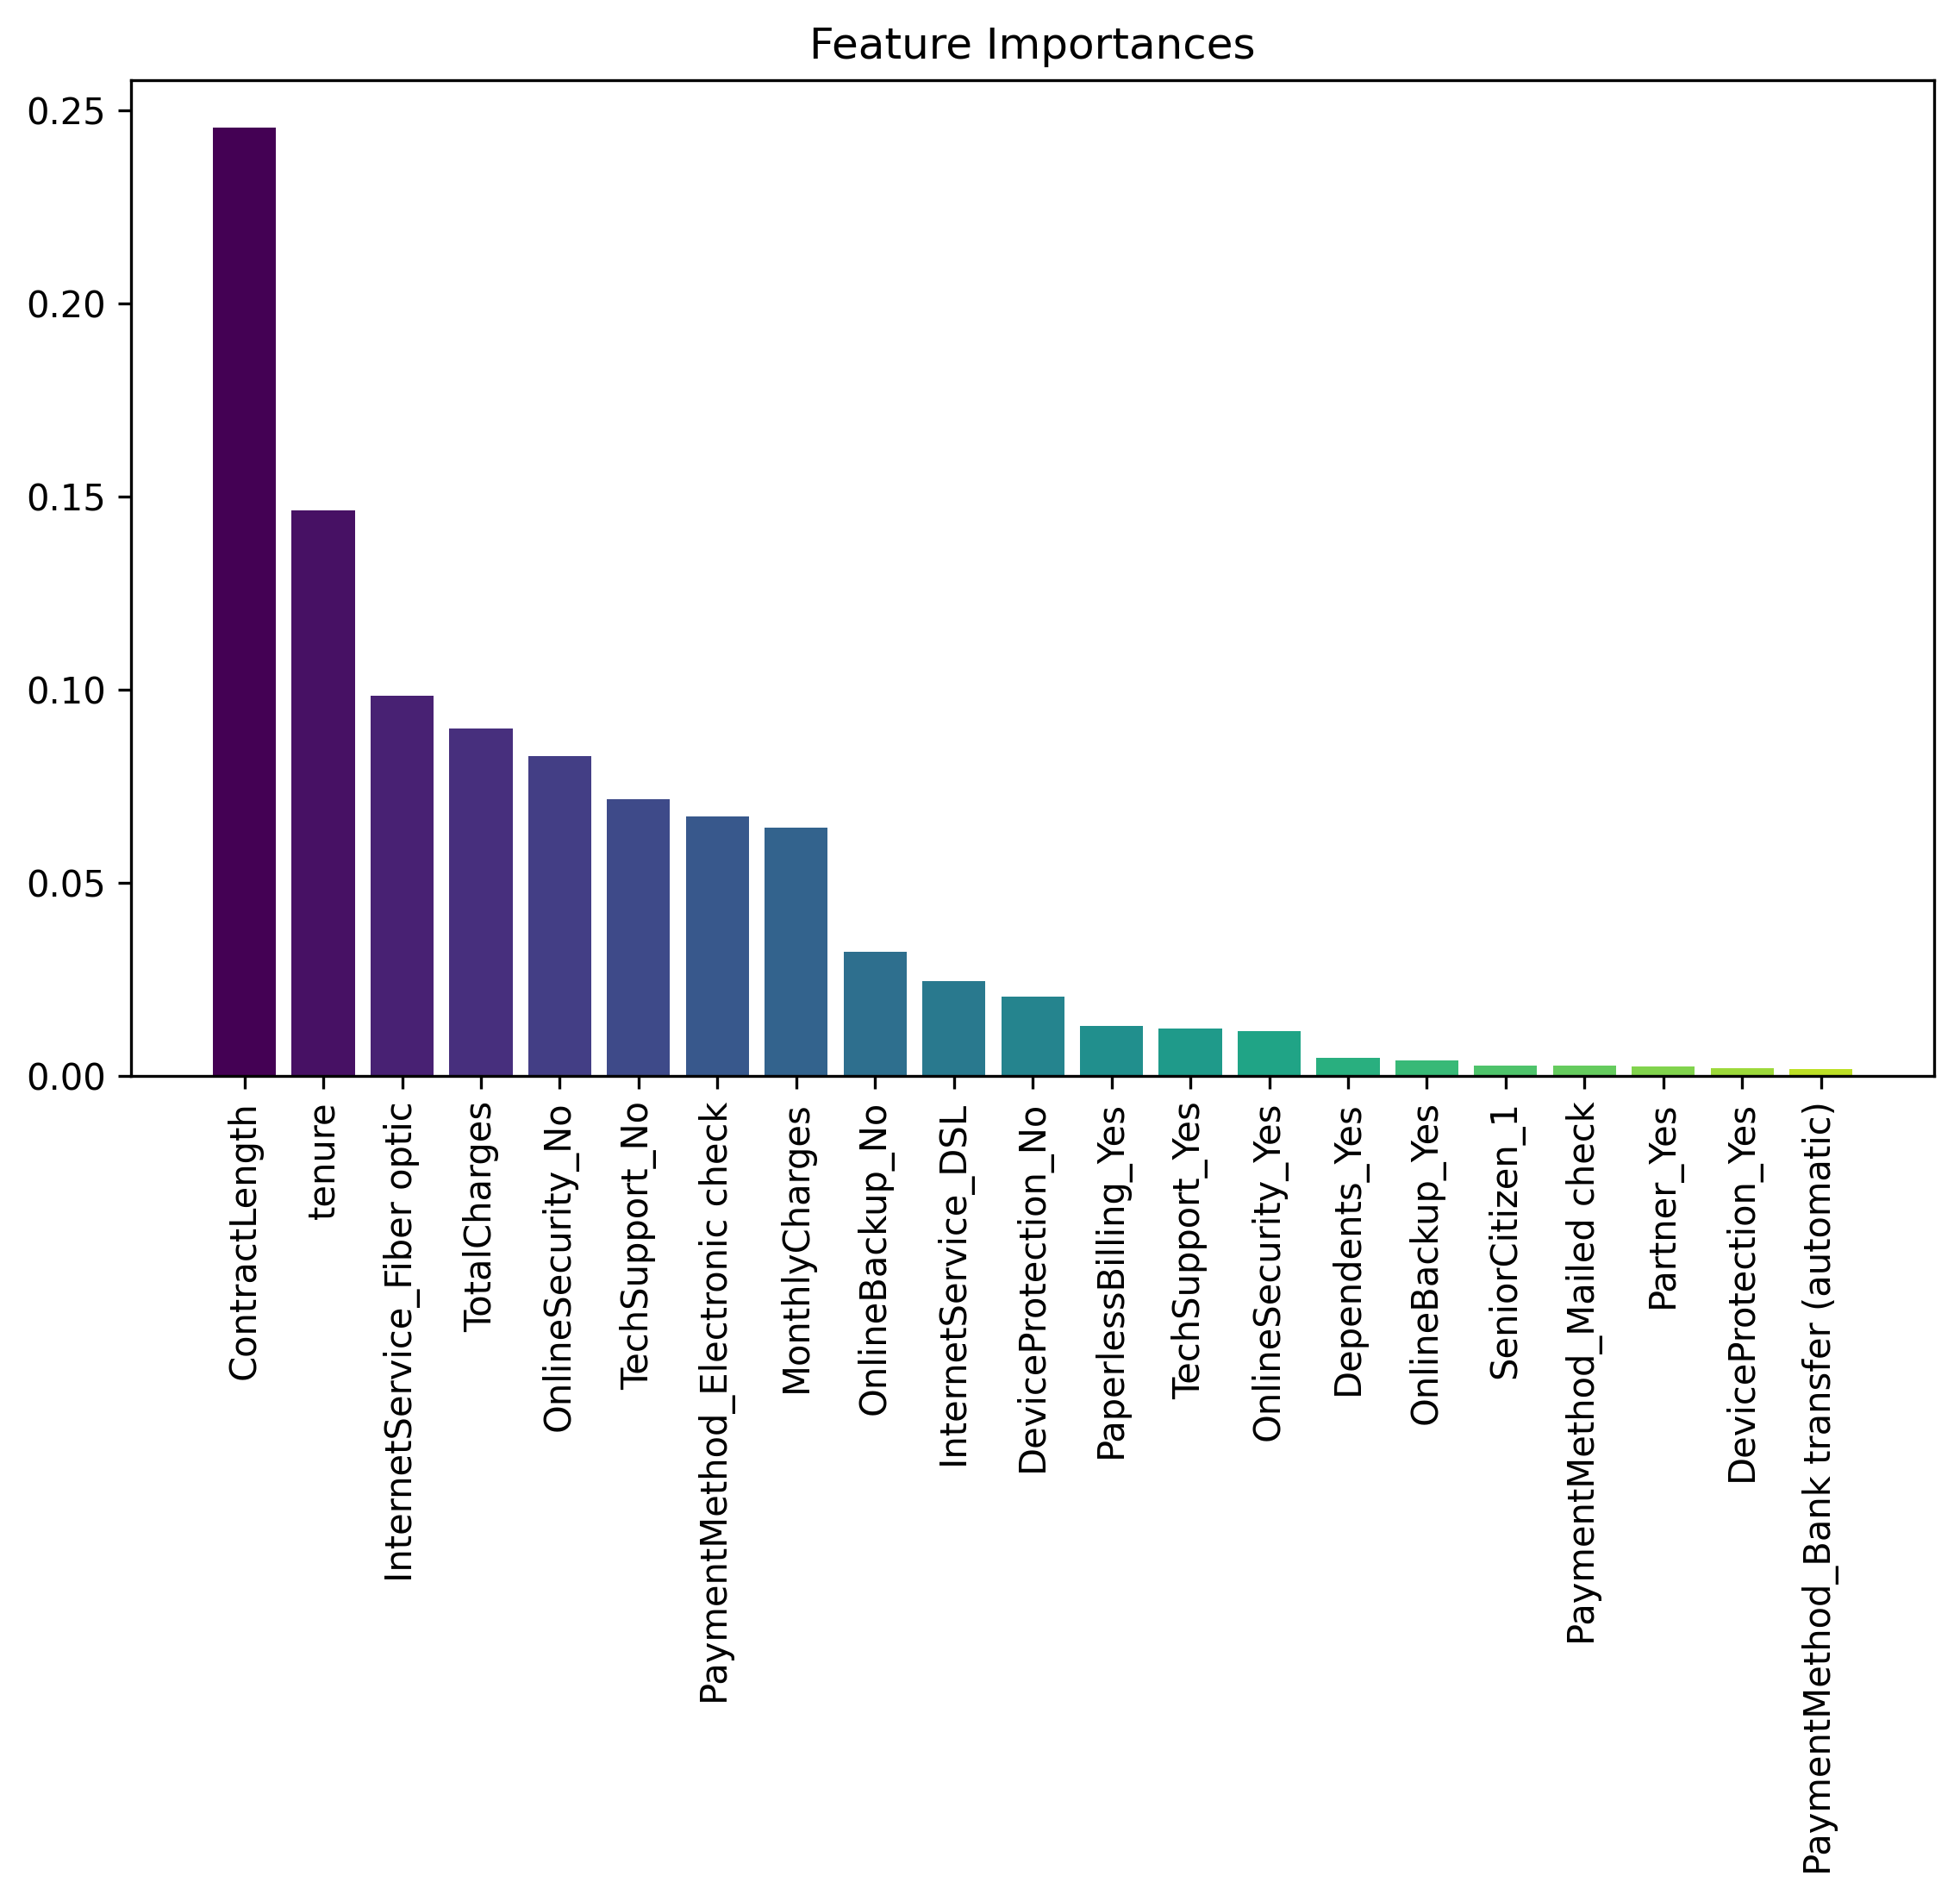

In [154]:
# Define colour map
colour_map = plt.cm.viridis(
    np.linspace(0, 0.9, len(feat_importances))
)
# Set figure parameters
plt.figure(figsize=(9, 5), dpi=300)

# Plot feature importances
plt.bar(
    feat_importances.index, 
    feat_importances.values, color=colour_map
)

# Set title
plt.title("Feature Importances")
# Set x-ticks
plt.xticks(rotation=90);

A quick look at the feature importances revealed patterns which strongly aligned with findings observed during the exploratory data analysis. Notably, `Contract` was shown to be the most significant predictor, followed closely by `tenure`. Other important predictors shown were `InternetService` *(Fiber optic)*, `OnlineSecurity` *(No)*, `TotalCharges`, `TechSupport` 
*(No)*, `MonthlyCharges`, and `PaymentMethod *(Electronic check)*. These features were all highlighted earlier as key predictors of *Churn*.

Interestingly, some features, including **PaperlessBilling** and **SeniorCitizen**, despite being shown to have an impact on churn in the EDA, ranked lower in the feature importance list. This could suggest that these features might only be *indirectly associated* with churn, rather than directly influencing it, especially in relation to more dominant features such as `Contract` and `tenure`.

These insights could potentially guide further model refinement by, for instance, removing less influential features from the dataset, which could simplify the model without sacrificing much predictive power. However, given that some features were already removed during the data preprocessing, whether or not further pruning would result in a meaningful performance increase is uncertain.

#### Gradient Boosting

Moving onto the second ensemble method, the Gradient Boosting model will now be explored in this subsection. Based on a previous grid search, `subsample=0.8` was set, since this was identified as preferable to the default setting of 1.0; *subsample* controls the fraction of the training data used to build each tree, and setting it to 0.8 can help to reduce overfitting by adding an element of randomness. This was set here to simplify the parameter range and reduce computational cost.

A `Pipeline()` object was created, with resampling factored along with the model itself.

In [155]:
# Define GB instance for Pipeline
gb_instance = GradientBoostingClassifier(
    subsample=0.8, 
    random_state=1066
)

# Set up Pipeline for Gradient Boosting
gb_grid_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=1066)),
    ("gb", gb_instance)
])

The following hyperparameters were chosen, which were then stored in a parameter grids. Note that many of the hyperparameters are similar to those found in Random Forest, so additional details about them are omitted here for brevity:
- **n_estimators**: Defines the number of trees (or boosting rounds). A range from 50 to 500 trees were chosen for the grid search.
- **learning_rate**: The step size for updating the model in each round of boosting. A lower learning rate means that the model learns more slowly, but can improve accuracy by reducing overfitting when combined with a higher number of trees. Values from 0.01 to 0.3 were chosen here.
- **max_depth**: The maximum depth of each tree, controlling the model's complexity. A range from 3 to 7 was chosen here.
- **min_samples_split**: The minimum number of samples required to split a node. Values from 5 to 10 were chosen here.
- **min_samples_leaf**: The minimum number of samples required to form a leaf node. Values from 1 to 7 were chosen here.
- **max_features**: Also used in Random Forest (but left at its default setting); the maximum number of features considered for splitting at each node. The values *sqrt* and *7* were chosen for testing, allowing for a balance between using more features and keeping the model generalised.

In [156]:
# Set up variables for param grid
n_estimators = [50, 100, 150, 200, 250, 300, 500]
learning_rate = [0.01, 0.05, 
                 0.07, 0.1, 0.2, 0.3]
max_depth = [3, 5, 7]
min_samples_split = [5, 7, 10] 
min_samples_leaf = [1, 2, 4, 7]
max_features = ["sqrt", 7]

# Set up param grid
gb_params = {
    "gb__n_estimators": n_estimators,
    "gb__learning_rate": learning_rate,
    "gb__max_depth": max_depth,
    "gb__min_samples_split": min_samples_split,
    "gb__min_samples_leaf": min_samples_leaf,
    "gb__max_features": max_features
}

An instance of `GridSearchCV()` was then defined and fitted with all relevant parameters.

In [157]:
# Define grid search
gb_grid = GridSearchCV(
    gb_grid_pipe,
    gb_params,
    cv=5,
    scoring=scorer,
    verbose=2,
    n_jobs=-1
)

In [158]:
# Fit grid
#gb_grid.fit(X_train, y_train)

In [159]:
# Inspect best parameters
#gb_grid.best_params_

The grid search for Gradient Boosting identified the best hyperparameters to be 150 estimators, a learning rate of 0.01, a maximum depth of 3, a maximum number of features at 7, and a minimum number of samples for splitting a node and forming a leaf at 5 and 7, respectively.

Hence a model instance was fitted through `ImbPipeline()`, a specialised version of `Pipeline()` capable of implementing `SMOTE()`.

In [160]:
# Define GB model instance
gb_opt_instance = GradientBoostingClassifier(
    learning_rate=0.01,
    n_estimators=150,
    subsample=0.8,
    min_samples_split=5,
    min_samples_leaf=7,
    max_features=7,
    max_depth=3,
    random_state=1066
)

# Set up pipeline
gb_opt = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=1066)),
    ("gb", gb_opt_instance)
])

In [161]:
# Fit model
gb_opt.fit(X_train, y_train)

,steps,"[('smote', ...), ('gb', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](21,)","['tenure','ContractLength','MonthlyCharges',..., 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Electronic check','PaymentMethod_Mailed check']"
n_features_in_,int,21
,random_state,1066
,sampling_strategy,'auto'
,k_neighbors,5


In [162]:
# Collect metrics
gb_opt_metrics = get_metrics(
    gb_opt, "Optimised", X_val, y_val
)

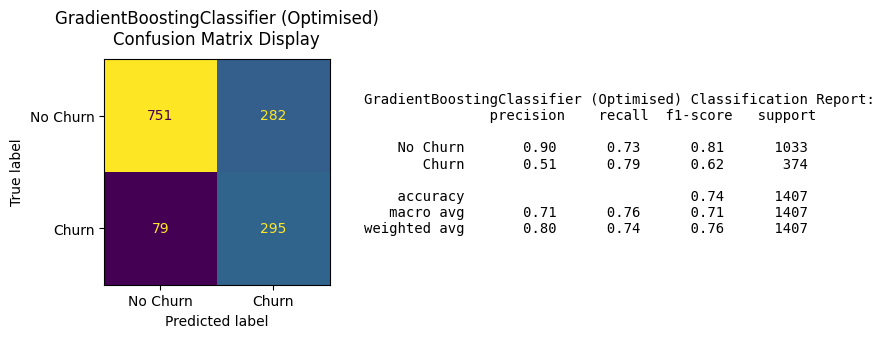

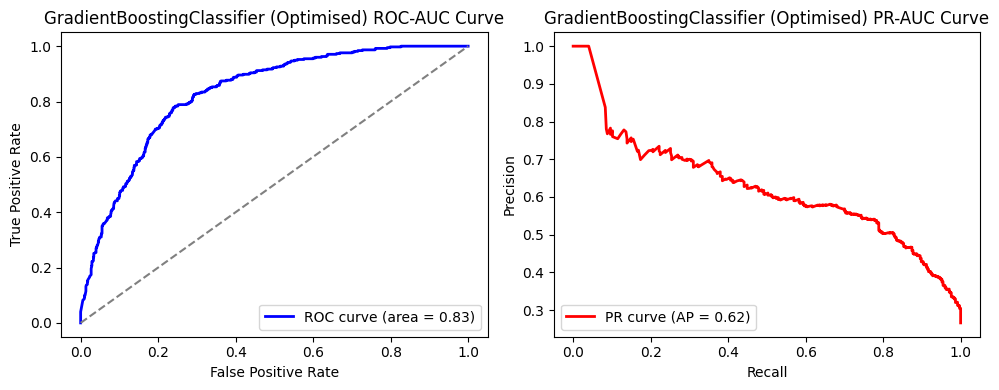

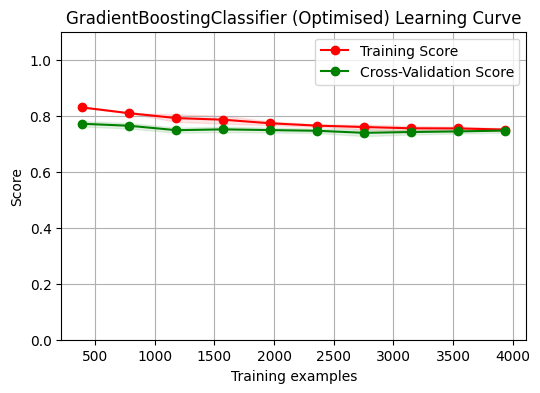

In [163]:
# Display curves, matrix and report
gb_opt_eval = display_evaluation(
    gb_opt, "Optimised", X_train, y_train, X_val, y_val
)

The optimised Gradient Boosting model delivered strong results, showing improvement over its previous balanced iteration. It achieved a precision of 0.51, recall of 0.79, and F1 score of 0.62, compared to the previous iteration's scores of 0.57, 0.65, and 0.61, respectively. Similarly to the other models, a small drop in precision was noted along with a corresponding increase in recall. Notably, the AP score is 0.62, matching that of Random Forest, although it represents a slight drop in two points from its balanced iteration.

The confusion matrix reflects this improvement, with 295 true positives, 282 false positives, and 79 false negatives. The learning curve also shows stable performance, with training and cross-validation scores closely aligned at around 0.75, which suggests the model is generalising well to the unseen data.

Compared to its balanced iteration, Gradient Boosting has seen significant gains in recall, increasing by 14 points, while precision dropped slightly, although the F1 score increased overall. Interestingly, Random Forest now slightly outperforms Gradient Boosting in recall, marking a  shift in performance, although Gradient Boosting still remains highly competitive with only minor differences compared to the other top-performing models.

Overall, Gradient Boosting has proven to be a robust performer. All the optimised models, with the exception of KNN, have shown comparable results, highlighting the overall success of parameter tuning so far.

#### Adaptive Boosting

The third and final ensemble method, and the last model to be optimised, was AdaBoost. An instance of the AdaBoost model was created and included in `Pipeline()`, together with `SMOTE()`, for consistency.

In [164]:
# Create ada instance and set up pipeline
ada_instance = AdaBoostClassifier(random_state=1066)

# Set up Pipeline for AdaBoost
ada_grid_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=1066)),
    ("ada", ada_instance)
])

The hyperparameters **n_estimators** and **learning_rate** were selected and stored in the parameter grid.

AdaBoost has fewer parameters to optimise in comparison to the other two ensemble methods tuned earlier, hence making it simpler to tune. These two parameters function similarly here as they do in Gradient Boosting and Random Forest, so their details will not be discussed here.

In [165]:
# Set up variables for param grid
n_estimators = [100, 150, 200, 250, 275, 300, 325, 
                350, 375, 400, 450, 500]
learning_rate = [0.01, 0.03, 0.04, 0.05, 0.06, 
                 0.07, 0.1, 0.15, 0.2]

# Set up param grid
ada_params = {
    "ada__n_estimators": n_estimators,
    "ada__learning_rate": learning_rate
}

Hence `GridSearchCV()` was defined, with all relevant parameters, and fitted to the training data.

In [166]:
# Define grid search
ada_grid = GridSearchCV(
    ada_grid_pipe, 
    ada_params, 
    cv=5, 
    scoring=scorer,
    verbose=2, 
    n_jobs=-1
)

In [167]:
# Fit grid
#ada_grid.fit(X_train, y_train)

In [168]:
# Inspect best parameters
#ada_grid.best_params_

The grid search for AdaBoost identified 400 estimators, along with a learning rate of 0.07, as the optimal parameters. However, additional experimentation with the two parameter combinations revealed that reducing *n_estimators* to 350 provided a slight improvement in recall by one point, without significantly affecting overall performance metrics. As a result, 350 estimators were used for the optimised AdaBoost model.

Hence, an instance of the optimised model was defined and included within `ImbPipeline()`, along with `SMOTE()`, which was then fitted and evaluated on the validation set.

In [169]:
# Create optimised Ada instance
ada_opt_instance = AdaBoostClassifier(
    learning_rate=0.07,
    n_estimators=350
)

# Set up pipeline
ada_opt = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=1066)),
    ("ada", ada_opt_instance)
])

In [170]:
# Fit optimised model
ada_opt.fit(X_train, y_train)

,steps,"[('smote', ...), ('ada', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](21,)","['tenure','ContractLength','MonthlyCharges',..., 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Electronic check','PaymentMethod_Mailed check']"
n_features_in_,int,21
,random_state,1066
,sampling_strategy,'auto'
,k_neighbors,5


In [171]:
# Collect metrics
ada_opt_metrics = get_metrics(ada_opt, "Optimised", X_val, y_val)

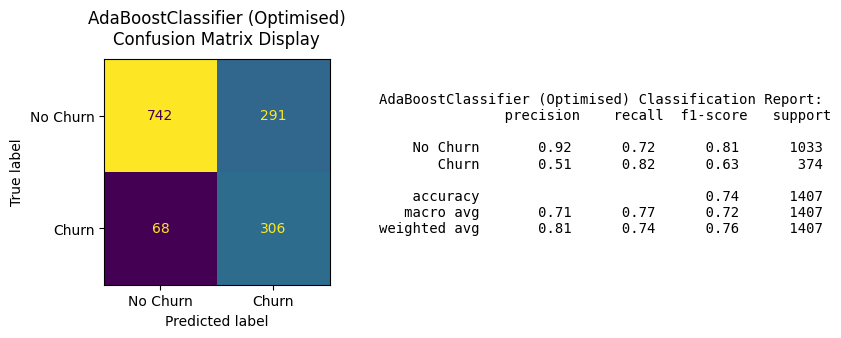

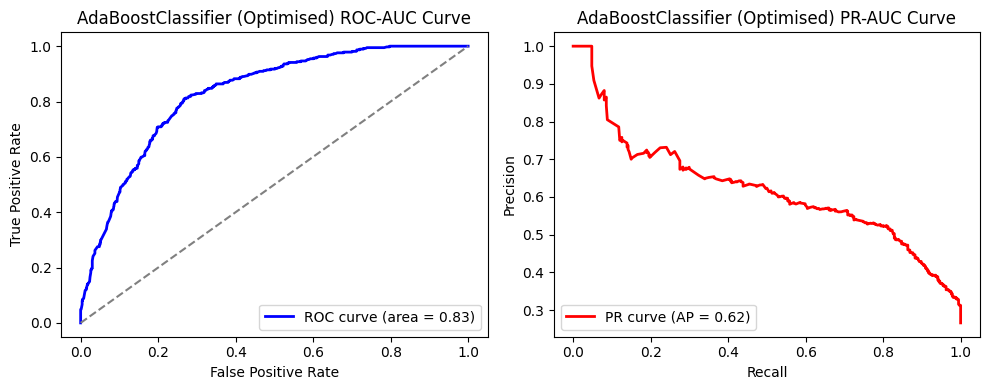

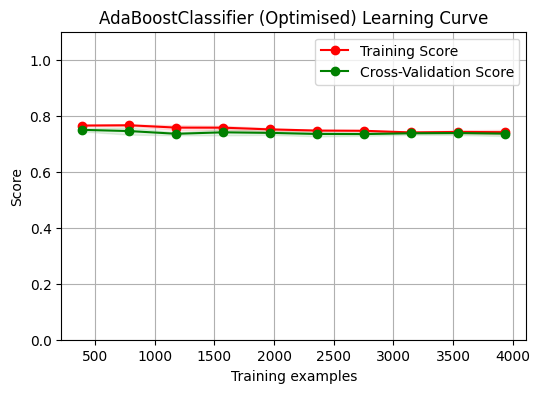

In [172]:
# Display curves, matrix and report
ada_opt_eval = display_evaluation(
    ada_opt, "Optimised", X_train, y_train, X_val, y_val
)

The optimised AdaBoost model demonstrated impressive performance. For the *Churn* class, it achieved a precision of 0.51, recall of 0.81, and F1 score of 0.63. The average precision score also improved slightly from 0.61 in the balanced model to 0.62 in the optimised model. Most notably, recall increased by five points, demonstrating an improvement in the model’s ability to identify more churn cases. The confusion matrix shows 304 true positives, 291 false positives, and 70 false negatives, reflecting a marked improvement over the balanced version of AdaBoost, which had 286 true positives and 88 false negatives.

The learning curve for AdaBoost shows stable training and cross-validation scores around 0.75, indicating consistent generalisation to unseen data. Among the ensemble methods, AdaBoost has emerged as the strongest, though the differences in performance across the ensemble models are minor. 

AdaBoost’s metrics are broadly comparable to several other models, including Logistic Regression and SVM, with only minimal differences. For instance, while Logistic Regression and AdaBoost both achieved an F1 score of 0.63, AdaBoost captured two more true positives than Logistic Regression.

In summary, the optimised AdaBoost model scored similarly to the other top performing models.

## Model Evaluation

In this section, the key performance metrics of all the models are presented in a table. The optimised model metrics are visualised in the form of a bar chart and compared against each other, after which the best overall model is evaluated one last time on the *holdout* test set, to see how the model performs on truly *unseen* data. While cross-validation does help to reduce bias, the validation set cannot be considered truly unseen since some data leakage may occur as a result of repeatedly evaluating a model on the same validation data during hyperparameter tuning.

### Results

In [173]:
# Define list of optimised model metrics
opt_metrics = [
    lr_opt_metrics,
    knn_opt_metrics,
    svm_opt_metrics,
    rf_opt_metrics,
    gb_opt_metrics,
    ada_opt_metrics
]

# Create DataFrame
df_opt_metrics = pd.DataFrame(opt_metrics)
df_opt_metrics

,Model,Model Configuration,Accuracy Score,Precision (Churn),Recall (Churn),F1 Score (Churn),Precision (No Churn),Recall (No Churn),F1 Score (No Churn),Churn ROC-AUC Score,Churn PR-AUC (AP) Score
0,LogisticRegression,Optimised,0.743426,0.510998,0.807487,0.625907,0.911765,0.720232,0.804759,0.835308,0.606929
1,KNeighborsClassifier,Optimised,0.760483,0.537374,0.711230,0.612198,0.881579,0.778316,0.826735,0.821698,0.590591
2,SVC,Optimised,0.740583,0.507563,0.807487,0.623323,0.911330,0.716360,0.802168,0.834426,0.608928
3,RandomForestClassifier,Optimised,0.758351,0.529825,0.807487,0.639831,0.913978,0.740561,0.818182,0.838673,0.623276
4,GradientBoostingClassifier,Optimised,0.743426,0.511265,0.788770,0.620400,0.904819,0.727009,0.806227,0.831060,0.621784
5,AdaBoostClassifier,Optimised,0.744847,0.512563,0.818182,0.630278,0.916049,0.718296,0.805209,0.829393,0.619706


In [174]:
# Create DataFrame
all_metrics = pd.concat(
    [df_base_metrics, df_bal_metrics, df_opt_metrics]
)

# Group metrics by model and configuration
all_metrics_grouped = all_metrics.groupby(
    ["Model", "Model Configuration"]).sum()

all_metrics_grouped

Accuracy Score  \
Model                      Model Configuration                   
AdaBoostClassifier         Balanced                   0.745558   
                           Base                       0.790334   
                           Optimised                  0.744847   
GradientBoostingClassifier Balanced                   0.776830   
                           Base                       0.787491   
                           Optimised                  0.743426   
KNeighborsClassifier       Balanced                   0.739161   
                           Base                       0.754797   
                           Optimised                  0.760483   
LogisticRegression         Balanced                   0.743426   
                           Base                       0.790334   
                           Optimised                  0.743426   
RandomForestClassifier     Balanced                   0.760483   
                           Base                       0.773987   
                           Optimised                  0.758351   
SVC                        Balanced                   0.754797   
                           Base                       0.781805   
                           Optimised                  0.740583   

                                                Precision (Churn)  \
Model                      Model Configuration                      
AdaBoostClassifier         Balanced                      0.514388   
                           Base                          0.640569   
                           Optimised                     0.512563   
GradientBoostingClassifier Balanced                      0.571090   
                           Base                          0.634409   
                           Optimised                     0.511265   
KNeighborsClassifier       Balanced                      0.508600   
                           Base                          0.542274   
                           Optimised                     0.537374   
LogisticRegression         Balanced                      0.510998   
                           Base                          0.631229   
                           Optimised                     0.510998   
RandomForestClassifier     Balanced                      0.543124   
                           Base                          0.600000   
                           Optimised                     0.529825   
SVC                        Balanced                      0.526032   
                           Base                          0.629344   
                           Optimised                     0.507563   

                                                Recall (Churn)  \
Model                      Model Configuration                   
AdaBoostClassifier         Balanced                   0.764706   
                           Base                       0.481283   
                           Optimised                  0.818182   
GradientBoostingClassifier Balanced                   0.644385   
                           Base                       0.473262   
                           Optimised                  0.788770   
KNeighborsClassifier       Balanced                   0.553476   
                           Base                       0.497326   
                           Optimised                  0.711230   
LogisticRegression         Balanced                   0.807487   
                           Base                       0.508021   
                           Optimised                  0.807487   
RandomForestClassifier     Balanced                   0.622995   
                           Base                       0.449198   
                           Optimised                  0.807487   
SVC                        Balanced                   0.783422   
                           Base                       0.435829   
                           Optimised                  0.807487   

                         

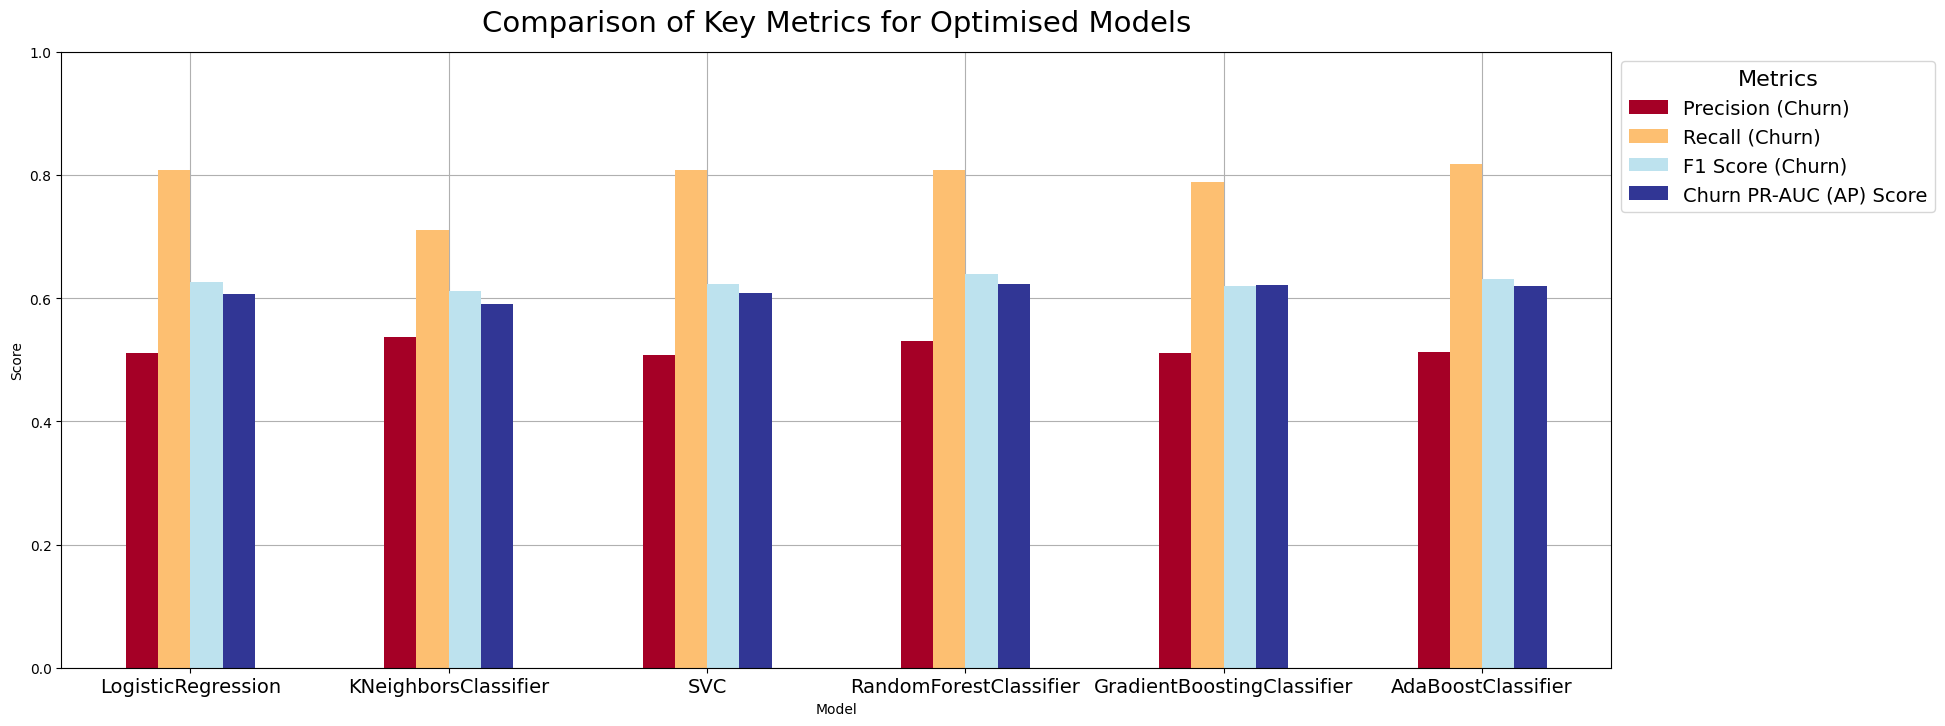

In [175]:
# Define metrics to visualise
metrics = (
    list(df_opt_metrics.columns[3:6])
    + list(df_opt_metrics.columns[10:])
)

# Plot metrics
df_opt_metrics.plot(
    x="Model", 
    y=metrics, 
    kind="bar", 
    grid=True, 
    zorder=2, 
    figsize=(20, 8), 
    cmap="RdYlBu"
)

# Set title and labels
plt.title(
    "Comparison of Key Metrics for Optimised Models",
    y=1.02, fontsize=21
)
plt.ylabel("Score")
plt.xlabel("Model")
# Set xticks
plt.xticks(fontsize=14, rotation=0)
# Set ylim
plt.ylim(0, 1)

# Set legend and layout
plt.legend(title="Metrics", bbox_to_anchor=(1,1),
           fontsize=14, title_fontsize=16)
plt.tight_layout;

### Observations

Looking over the optimised model data, it is clear that some of the models have performed better than others, though many share broadly similar metrics. The metrics discussed here refer specifically to those of the *Churn* class, unless otherwise stated.

#### Key Observations

From the bar plot and corresponding table, AdaBoost narrowly achieved the highest recall at approximately 0.813, with Logistic Regression, Support Vector Machines, and Random Forest following closely behind at 0.807, 0.807, and 0.805, respectively (Logistic Regression and SVM also coincidentally share identical unrounded values). Gradient Boosting also performed well here, scoring approximately 0.789. The lowest recall was given by K-Nearest Neighbours at around 0.711, significantly lower than the other models despite being a substantial improvement from its previous untuned *balanced* iteration.

Interestingly, KNN scored the highest precision of all the models observed at around 0.537, although this is only marginally higher than the lowest score, which is given by SVM at approximately *0.508*. In fact, precision is broadly similar across each model, each of which satisfying the required precision constraint, namely a minimum of 0.5. 

The F1 Score was also broadly similar across each of the models, ranging from around a low of 0.612 (KNN) to a high of 0.632 (Random Forest).

Much like the F1 score, the PR-AUC/Average Precision of the models were all close to 0.6, with the lowest and highest values also given by KNN and Random Forest, respectively, corresponding to approximately 0.590 to a 0.624.

#### Performance Metrics of the Majority Class

In contrast, looking at the performance metrics of the *No Churn* class, the scores were all notably higher, despite decreasing after class balancing and hyperparameter tuning were implemented. This behaviour is expected, since *No Churn* is the majority class in the dataset. The highest precision score was given by AdaBoost at approximately 0.914, whereas the highest recall and F1 scores were both given by KNN, at 0.778 and 0.824 respectively. Conversely, KNN's precision here was the lowest at 0.882, whereas SVM gave both the lowest recall at 0.716, and F1 score at 0.802. These results are interesting, since they suggest that KNN may have more room for maneuver when it comes to optimising its hyperparameters; it's recall in particular stands out, and is meaningfully higher in value than the second highest score of 0.732 given by Random Forest.

#### Optimal Model Selection

Overall, all optimised models performed reasonably well. Logistic Regression, Support Vector Machines, Random Forest, and AdaBoost show similar results overall, while K-Nearest Neighbours lags behind most notably in recall. Even though the F1 and Average Precision scores across all the models are broadly comparable, *AdaBoost* edges out just enough for it to be distinguished as the best performing model. It achieved the highest recall while maintaining an acceptable level of precision, meeting the criteria for selecting the final model as defined at the start of the *Model Optimisation and Tuning* section. Additionally, AdaBoost scored the highest precision for the majority class. 

While AdaBoost scored the highest overall with respect to the key performance criteria, Logistic Regression and Support Vector Machines showed consistent and reliable performance, with the latter improving substantially after its first iteration. Most notably, Random Forest stood out for its exceptional transformation, going from initially being one of the worst performing models to achieving both the highest Average Precision and F1 scores. 

Having finalised the model selection, its performance was subsequently assessed on the final *holdout* set before preparation for deployment.

In [176]:
# Manually apply holdout set to Optimised AdaBoost
holdout_preds = ada_opt.predict(X_hold)

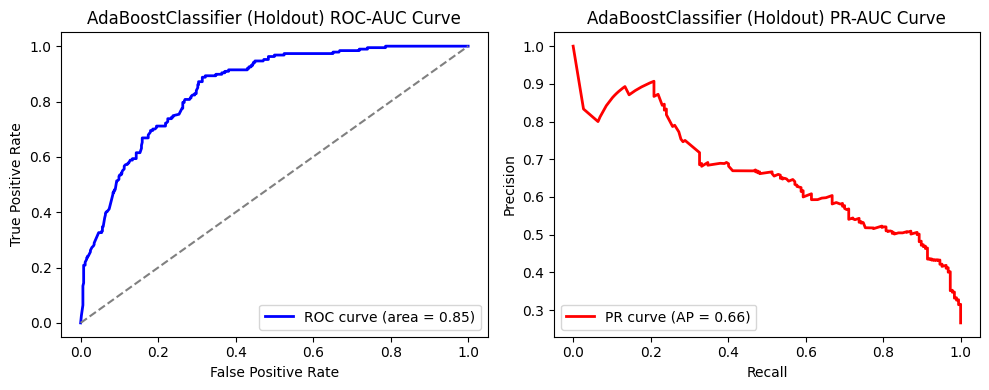

In [177]:
# Plot roc-pr curves
holdout_curves = plot_roc_pr_curves(
    ada_opt, "Holdout", X_hold, y_hold
);

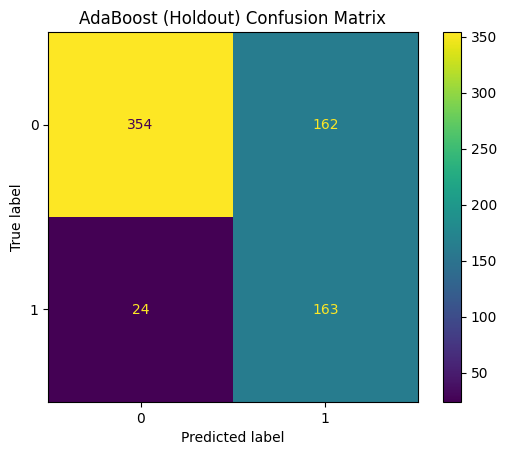

In [178]:
# Show confusion matrix
holdout_matrix = ConfusionMatrixDisplay.from_predictions(
    y_hold, holdout_preds
)
# Set title
plt.title("AdaBoost (Holdout) Confusion Matrix");

In [179]:
# Print classification report
holdout_report = classification_report(y_hold, holdout_preds)
print(holdout_report)

              precision    recall  f1-score   support

           0       0.94      0.69      0.79       516
           1       0.50      0.87      0.64       187

    accuracy                           0.74       703
   macro avg       0.72      0.78      0.71       703
weighted avg       0.82      0.74      0.75       703



The final evaluation metrics on the holdout set demonstrate that the optimised AdaBoost model generalises well, with a notably higher recall (0.87) for the minority class compared to its previous evaluation on the validation set (0.81). The precision (0.50), while slightly lower than the previous iteration (0.51), still remains within acceptable bounds for the project's performance criteria. Additionally, the average precision score (0.66) has increased by four points (0.62). 

The results confirm the model's suitability for deployment. However, a precision of 0.5 suggests a high rate of false positives, as evidenced by the confusion matrix where the number of false positives is almost equal to the number of true positives. This limitation will be revisited further in the *Discussion* section of the notebook.

## Model Deployment

The *final* AdaBoost model was fitted using the optimised hyperparameters identified with `GridSearchCV()`, and subsequently trained on the *entire* dataset, utilising all the available data.

In [180]:
# Create optimised Ada instance
final_ada_instance = AdaBoostClassifier(
    learning_rate=0.07,
    n_estimators=350
)

# Set up final model in Pipeline
final_model = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=1066)),
    ("ada", ada_opt_instance)
])

In [181]:
# Fit final model
final_model.fit(X, y)

,steps,"[('smote', ...), ('ada', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](21,)","['tenure','ContractLength','MonthlyCharges',..., 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Electronic check','PaymentMethod_Mailed check']"
n_features_in_,int,21
,random_state,1066
,sampling_strategy,'auto'
,k_neighbors,5


The trained final model was saved using the *Joblib* library, and exported to a file named `customer_churn_predictor.pkl` so that it can be easily reloaded for later use or deployment.

In [182]:
# Import joblib library
#import joblib

In [183]:
# Save final model
#joblib.dump(final_model, "customer_churn_predictor.pkl")

The column names were also saved as a separate file, ensuring that input data for future predictions can be correctly attributed to the model's expected feature order.

In [184]:
# Save column names
#joblib.dump(list(X.columns), "customer_churn_column_names.pkl")

## Discussion

The project aimed to predict customer churn using machine learning, in order to help businesses to preemptively identify high-risk customers and prevent potential revenue loss. The analysis included exploratory data analysis (EDA), feature engineering, model selection, hyperparameter optimisation, and evaluation. A final Adaptive Boosting model (AdaBoost) was chosen based on its strong recall performance.

During exploratory data analysis, the dataset revealed significant class imbalance, with churners accounting for only 26 to 27 percent of the given data. This impacted the trajectory of the project, such as choosing to prioritise recall over accuracy in evaluation metrics. Class-specific outliers were flagged in boxplots when the data were filtered by the target variable, although a qualitative assessment revealed that most flagged outliers were likely incorrectly identified. While a few of these outliers may have been notable within the *Churn* class, they were not true outliers across the entire dataset, and were retained to conserve important data in the already imbalanced minority class. One potentially significant outlier was retained because it was associated with other features linked to customer churn, which suggested multiple contributing factors.

Exploratory data analysis also highlighted key features associated with churn. Among categorical features, *month-to-month contract holders* emerged as the strongest predictor, with *fibre-optic internet service* and *electronic cheque payment method* also strongly associated with customer churn. *Streaming TV and Movies*, despite scoring high on a chi-square test of independence, were ultimately removed due to weak correlations with the target variable. This decision was supported by feature encoding and subsequent model training, where *Random Forest feature importance* ranked these features low in relevance, further justifying their exclusion.

Features such as `TotalCharges` were retained despite high correlation, and potential collinearity, with `tenure`, as it captured additional variance not shown by the other numerical features. This decision was further supported by the *feature importance* rankings given by Random Forest during model hyperparameter tuning, where `TotalCharges` was ranked as the fifth most important feature, scoring just under 0.1. Its importance ranked higher than even the *absence of tech support*, another important feature which was identified during EDA. The most important features identified by Random Forest were `ContractLength`, `tenure`, `InternetService` *(Fiber Optic)*, and `OnlineSecurity` *(No)*, followed by `TotalCharges`. 

Multiple models were tested, including but not limited to Logistic Regression, Random Forest, and AdaBoost. AdaBoost narrowly emerged as the best performing model after hyperparameter tuning, achieving a recall of 87% and precision of 50% for the minority class upon final evaluation with the holdout test set. The high recall ensures that the model can effectively identify churners, while the precision ensures that these predictions are true in at least 50 percent of instances.

In conclusion, the AdaBoost model achieved the project's goals by prioritising recall while maintaining an acceptable level of precision. These results demonstrate the model's potential to support businesses in identifying and retaining at-risk customers, though further improvements could enhance its overall utility and reliability.

### Limitations

The project faced several limitations, particularly regarding class imbalance, parameter constraints, feature selection, model selection, and the potential impact of retained outliers and asymmetric data distribution. 

#### Class Imbalance and Evaluation Metrics

Most notably, the class imbalance posed challenges for the reliability of accuracy as a metric, necessitating a trade-off between precision and recall. The 0.5 precision threshold, while meeting the project criteria, is not ideal and may not suit all business contexts. While the model's high recall ensures that a high number of potential churners are flagged, the effect of the precision constraint means that half of the customers predicted may not actually be at risk of churn. This could result in businesses investing unnecessarily in expensive customer retention strategies targeting these false positives, resulting in wasted resources.

Furthermore, with the precision constraint set to a threshold of 0.5, the possibility of precision dropping below this threshold in future datasets or post-deployment presents a risk to the reliability of the model. For example, consider the discrepancy between the reported values given by the optimised AdaBoost model on the validation set (0.51) and the final holdout set (0.50), a difference of only one point. If the model were given a new set of new unseen data and the precision subsequently dropped by an additional point to 0.49, it would fall below the minimum threshold and thus further reduce the model's reliability for business use.

A higher precision threshold, say 0.6, may prove more reliable than the threshold currently in use, ensuring that the model's *Churn* predictions are more likely to be correct most of the time without necessarily sacrificing a huge percentage of recall. However, the decision to adjust this threshold will depend on the particular operational costraints of the business utilising this model.

#### Outliers and Data Asymmetry

While outliers were retained to conserve data for the minority class, as pruning them would have reduced the number of data available for prediction, this decision could have impacted the model's performance. Some of these outliers may have introduced noise, particularly if any were genuinely irrelevant. One particular outlier, specific to the *Churn* class in the `TotalCharges` feature, was retained because it had multiple features associated with churn. While this was deemed a reasonable decision, there's still the possiblility that removing this outlier could have been better for the model's performance than retaining it.

Some features also exhibited asymmetrical distributions. For `tenure` and `MonthlyCharges`, standard transformations were not suitable due to their irregular shapes, whereas `TotalCharges` was right-skew and may have benefited from, say, a *log transformation*. While tree-based ensemble models are capable of handling feature skewness natively, it remains a problem for distance-based models such as KNN and SVM, as well as for gradient-based models like Logistic Regression, as skewness can distort the magnitude of differences between data points within an affected feature. While scaling partially addresses differences in unit magnitude between different features, it does not change the underlying shapes of their distributions. 

As such, without any suitable transformations applied to the asymmetrical features in the dataset, the performance results of these specific distance- and gradient-based models may have been compromised.

#### Feature Selection

Feature importance analysis with Random Forest revealed inconsistencies with earlier chi-square results and exploratory analysis. For example, `PaperlessBilling` scored less than 0.025 in feature importance despite promising results during initial data analysis. Since Random Forest evaluates feature importances with respect to all variables, it's likely that other features in the dataset captured similar or overlapping information, thus reducing the model's reliance on `PaperlessBilling` as a predictor of churn and rendering it redundant.

A similar argument can be made for the `SeniorCitizen` feature, though its low feature importance could be better atributed to its sparsity in the dataset, that is, the small proportion of senior citizens (approx. 16%) relative to the total dataset. Around 25% of customers within the *Churn* class subset of the dataset were senior citizens, while nearly 90% of *Churn* customers held *month-to-month contracts*, and 70% used *fibre-optic internet service*. So, even in the absence of multicollinearity and despite a fairly large proportion of senior citizens among the *Churn* class, a strong association with *Churn* is of little value when a majority of the subset are non-senior citizens.

As a consequence, the model may have over-focused on less important features at the expense of prioritising more important features, and removing features with low-ranked importance could potentially save on computational resources without sacrificing (and possibly even improving) on model performance. 

#### Model Selection and Optimisation

While multiple models were tested, some potentially useful algorithms were not explored due to time constraints. For example, *eXtreme Gradient Boosting (XGBoost)*, a modified form of the traditional *Gradient Boosting* algorithm, was not included in this analysis. The inclusion of additional algorithms such as XGBoost might have yielded a model with better performance.

Similarly, hyperparameter tuning for *ensemble* models was limited in order to reduce the computational cost of extensive grid searches. Expanding the grid search to include additional parameters, particularly for *Random Forest* and *Gradient Boosting*, could have improved their performance.

Additionally, as mentioned throughout the analysis, Support Vector Machines are inherently non-probabilistic models. Consequently, the probability estimates used to compute the ROC-AUC and PR-AUC scores for the SVM models in this project cannot be guaranteed as reliable or properly calibrated. An alternative method, such as using `decision_function()` instead of `predict_proba()`, may produce a more reliable interpretation of these scores.

### Future Work

Future work could focus on addressing these limitations. Experimenting with additional models, such as *XGBoost*, and conducting an expanded hyperparameter tuning could yield better results. Further pruning of features based on feature importance rankings may also improve model performance and precision.

Exploring unsupervised learning models could also be useful. Dimensionality reduction techniques, such as *Principal Component Analysis (PCA)*, could be employed to remove redundant or highly correlated features, such as `TotalCharges` and `tenure`, and to reduce noise in the dataset. This could improve model performance, though potentially at the cost of feature interpretability. Additionally, clustering methods such as *K-Means* or *DBSCAN* could identify hidden risk-profiles associated with churn, providing valuable insights which can be utilised by the supervised learning models within this project.

Finally, deploying the model through an API would improve its practical usability for business applications.